In [3]:
"""
fitSRE: A Sigmoidal Rate Expression (SRE) Fitting Script

Author:
Nooruddin Abdel Rahman

Description:
This script fits cell degradation data using a hybrid Genetic and Trust Region Reflective (TRF) Algorithm approach.

The script performs the following tasks:
1. Extracts and preprocesses data from CSV files.
2. Down-samples the data for efficient fitting.
3. Defines and evaluates the SRE model.
4. Uses a genetic algorithm to find initial parameter estimates.
5. Fine-tunes the parameters using TRF.
6. Performs multiple runs with bootstrapping for robust parameter estimation.
7. Selects the optimal number of mechanisms based on AIC, BIC, and DIC scores.
8. Plots the results and saves them along with the parameters and logs.

Dependencies:
- numpy
- pandas
- matplotlib
- sklearn
- scipy
- deap
- joblib
- tqdm
- multiprocessing
- openpyxl

Usage:
1. Define the directory containing the CSV files and extract the data.
2. Set the genetic algorithm settings, parameter bounds, and other configurations.
3. Loop through the cells, process each one, and save the results.

How Optimal Parameters are Found:
The process of finding the optimal parameters involves several steps:

1. **Data Extraction and Preprocessing:**
   - The script extracts degradation data from CSV files, including time values and corresponding life metric values.
   - The data is down-sampled to ensure efficient fitting.

2. **Genetic Algorithm for Initial Parameter Estimation:**
   - A genetic algorithm (GA) is used to find initial parameter estimates for the SRE model.
   - The GA is configured with settings such as population size, number of generations, and mutation and crossover probabilities.
   - Key functions include `genetic_fit`, `evaluate_params`, `feasible`, `distance`, and `objective_function`.

3. **Fine-Tuning Using TRF:**
   - After obtaining initial parameter estimates from the GA, the parameters are fine-tuned using TRF.
   - The `curve_fit` function from the `scipy` library is used for this purpose.
   - Key functions include `curve_fit` and `objective_function`.

4. **Validation Using Bootstrapping:**
   - To ensure robustness, multiple runs with bootstrapping are performed.
   - This involves resampling the data and fitting the model multiple times to obtain a distribution of parameter estimates.
   - The median of these estimates is considered the final parameter set.
   - Key functions include `multiple_runs`, `run_hybrid_fit`, and `average_mechanisms`.

5. **Model Selection Using AIC, BIC, and DIC:**
   - The script evaluates the fit of the model using various metrics such as AIC, BIC, and DIC to select the optimal number of mechanisms.
   - These metrics balance model complexity and fit quality to prevent overfitting. To penalize variance, a 
   - Key functions include `choose_optimal_mechanisms` and `evaluate_metrics`.
   

Functions:
- SRE: Defines the Sigmoidal Rate Expression (SRE) function.
- evaluate_params: Evaluates the mean absolute error (MAE) between the fitted data and the actual life metric data.
- feasible: Checks if the sum of M values (including M0) is between 0 and 1.
- distance: Calculates the distance to the feasibility constraint for penalty in the genetic algorithm.
- objective_function: Wrapper for the SRE function to be used in curve fitting.
- evaluate_metrics: Evaluates various metrics for the fit between the SRE model and the actual data.
- extract_data: Extracts and preprocesses data from CSV files.
- downsample_data: Down-samples the data by the given factor or sample rate.
- clear_deap_creator: Clears DEAP creator to avoid conflicts.
- sort_by: Sorts the mechanisms by parameter values.
- genetic_fit: Performs genetic algorithm optimization to fit the SRE model.
- run_hybrid_fit: Runs genetic fit and fine-tunes using curve fitting.
- extract_mechanism_params: Extracts mechanism parameters from the given parameter list.
- average_mechanisms: Averages the aligned mechanism parameters.
- multiple_runs: Performs multiple runs with clustering for robust parameter estimation using bootstrapping.
- choose_optimal_mechanisms: Selects the optimal number of mechanisms based on AIC, BIC, and DIC.
- normalize: Normalizes a list of values to the range [0, 1].
- plot_scores: Plots normalized AIC, BIC, and DIC scores for different numbers of mechanisms.
- plot_results: Plots the results for different numbers of mechanisms and AIC/BIC scores.
- plot_bootstrap_samples: Plots different bootstrap samples of the downsampled data.
- save_results: Saves the genetic algorithm settings, results, and plots to an Excel file.
- process_cell: Processes a single cell's data, fits the SRE model, and saves the results.


"""

"\nfitSRE: A Sigmoidal Rate Expression (SRE) Fitting Script\n\nAuthor:\nNooruddin Abdel Rahman\n\nDescription:\nThis script fits cell degradation data using a hybrid Genetic and Trust Region Reflective (TRF) Algorithm approach.\n\nThe script performs the following tasks:\n1. Extracts and preprocesses data from CSV files.\n2. Down-samples the data for efficient fitting.\n3. Defines and evaluates the SRE model.\n4. Uses a genetic algorithm to find initial parameter estimates.\n5. Fine-tunes the parameters using TRF.\n6. Performs multiple runs with bootstrapping for robust parameter estimation.\n7. Selects the optimal number of mechanisms based on AIC, BIC, and DIC scores.\n8. Plots the results and saves them along with the parameters and logs.\n\nDependencies:\n- numpy\n- pandas\n- matplotlib\n- sklearn\n- scipy\n- deap\n- joblib\n- tqdm\n- multiprocessing\n- openpyxl\n\nUsage:\n1. Define the directory containing the CSV files and extract the data.\n2. Set the genetic algorithm settings,

In [1]:
# %% Import modules and libraries

import os
import time
import logging
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import multiprocessing
import matplotlib.pyplot as plt
from sklearn.utils import resample
from scipy.optimize import curve_fit
from deap import base, creator, tools, algorithms
from joblib import Parallel, delayed, parallel_backend



ModuleNotFoundError: No module named 'pandas'

In [17]:
# %% Create a folder to store the results
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Manually specify the path to your script
script_path = r"C:\Users\ABDEND\OneDrive - Idaho National Laboratory\SRE Modeling\fitSRE10.2.py"

# Define the top-level results folder
top_level_folder = f"results/fitSRE_{current_time}"
os.makedirs(top_level_folder, exist_ok=True)

# Specify the path where you want to save the code, including the current date and time
backup_path = os.path.join(top_level_folder, f"code_{current_time}.txt")

# Configure logging with the current date and time in the filename
log_filename = os.path.join(top_level_folder, f"timing_log_{current_time}.txt")
logging.basicConfig(
    filename=log_filename,
    filemode='w',  
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
)

print(f"Logging configured to '{log_filename}'.")

# Read the content of the script
with open(script_path, "r") as script_file:
    script_content = script_file.read()

# Write the content to the backup file
with open(backup_path, "w") as backup_file:
    backup_file.write(script_content)

print(f"Code saved to '{backup_path}'.")



Logging configured to 'results/fitSRE_20241209_173449\timing_log_20241209_173449.txt'.
Code saved to 'results/fitSRE_20241209_173449\code_20241209_173449.txt'.


In [19]:
# %% Define the functions

def SRE(t, M0, *params):
    """
    Sigmoidal Rate Expression (SRE) function that models the degradation process.

    Args:
        t (array-like): Array of time values.
        M0 (float): Initial improvement parameter.
        *params (float): Parameters for the SRE model, grouped in sets of three (a, b, M) for each mechanism.
                         Each mechanism's parameters are:
                         - a: rate constant
                         - b: order-of-reaction term
                         - M: maximum extent of aging progression possible under the test conditions

    Returns:
        tuple:
            - result (array-like): Sum of all mechanisms' contributions plus M0.
            - mechanisms (list of array-like): Individual mechanisms' contributions.
    """
    # Ensure params length is valid
    if len(params) % 3 != 0:
        raise ValueError(
            "The number of parameters must be a multiple of 3 (a, b, M for each mechanism)."
        )

    n_mechanisms = len(params) // 3

    total = np.zeros_like(t)

    mechanisms = []

    for i in range(n_mechanisms):
        a, b, M = params[3 * i : 3 * i + 3]

        exp_term = np.exp(np.clip((a * t) ** b, -700, 700))
        mechanism = M0 + 2 * (M - M0) * (0.5 - 1 / (1 + exp_term))

        mechanisms.append(mechanism)
        total += mechanism

    return total, mechanisms


def evaluate_params(params, t_data, life_metric_data):
    """
    Evaluate the mean squared error (MSE) between the fitted data and the actual life metric data.

    Args:
        params (list of float): Parameters for the SRE model, with M0 as the first parameter.
        t_data (array-like): Array of time values.
        life_metric_data (array-like): Array of actual life metric values.

    Returns:
        tuple:
            - mse (float): Mean squared error of the fitted data.
    """

    M0 = params[0]
    mechanism_params = params[1:]
    fitted_data, _ = SRE(t_data, M0, *mechanism_params)

    if np.any(np.isnan(fitted_data)) or np.any(np.isinf(fitted_data)):
        return (float("inf"),)

    # mse = np.mean((fitted_data - life_metric_data) ** 2)
    mae = np.mean(abs(fitted_data - life_metric_data))
    return (mae,)


def feasible(individual):
    """
    Check if the sum of M values (including M0) in the individual is between 0 and 1 (inclusive).

    Args:
        individual (list of float): An individual solution from the genetic algorithm.

    Returns:
        bool: True if the sum of M values (including M0) is feasible, otherwise False.
    """
    M0 = individual[0]
    M_values = individual[3::3]
    total_sum = M0 + np.sum(M_values)
    return 0 <= total_sum <= 1.0



def distance(individual):
    """
    Calculate the distance to the feasibility constraint for penalty in the genetic algorithm.

    Args:
        individual (list of float): An individual solution from the genetic algorithm.

    Returns:
        float: Distance to the feasibility constraint.
    """
    M0 = individual[0]
    M_values = individual[3::3]
    return max(0, (M0 + np.sum(M_values)) - 1.0)


def objective_function(t, M0, *params):
    """
    Wrapper for the SRE function to be used in curve fitting.

    Args:
        t (array-like): Array of time values.
        M0 (float): Initial improvement parameter.
        *params (float): Parameters for the SRE model.

    Returns:
        array-like: Fitted life metric data.
    """

    return SRE(t, M0, *params)[0]


def evaluate_metrics(params, t_data, life_metric_data):
    """
    Evaluate various metrics for the fit between the SRE model and the actual data.

    Args:
        params (list of float): Parameters for the SRE model.
        t_data (array-like): Array of time values.
        life_metric_data (array-like): Array of actual life metric values.

    Returns:
        tuple:
            - sse (float): Sum of squared errors.
        - mse (float): Mean squared error.
        - rmse (float): Root mean squared error.
        - r_squared (float): R-squared value.
    """

    fitted_data, _ = SRE(t_data, *params)
    if np.any(np.isnan(fitted_data)) or np.any(np.isinf(fitted_data)):
        return float("inf"), float("inf"), float("inf"), float("inf")
    residuals = fitted_data - life_metric_data
    sse = np.sum(residuals**2)
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    r_squared = 1 - (
        sse / np.sum((life_metric_data - np.mean(life_metric_data)) ** 2)
    )
    return sse, mse, rmse, r_squared


def extract_data(directory):
    """
    Extract and preprocess data from CSV files in the specified directory.

    Args:
        directory (str): Path to the directory containing the CSV files.

    Returns:
        dict: A dictionary with keys as dates and values as another dictionary with cell numbers as keys and tuples of (t_data, life_metric_data) as values.
    """

    data_dict = {}
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path, skiprows=[1])
            parts = os.path.splitext(filename)[0].split("-")
            date = "-".join(parts[:3])
            cell_number = parts[-1]
            if date not in data_dict:
                data_dict[date] = {}
            t_data = df["Time"].values
            current_density = df["Current Density"].values
            fraction = current_density / current_density[0]
            life_metric_data = 1 - fraction
            
            
            data_dict[date][cell_number] = (t_data, life_metric_data)
    return data_dict


def downsample_data(t_data, life_metric_data, factor=None, sample_rate=None):
    """
    Down-sample the data by the given factor or sample rate, ensuring an even representation across the time range.

    Args:
        t_data (array-like): Array of time values in hours.
        life_metric_data (array-like): Array of life metric values.
        factor (int, optional): Down-sampling factor.
        sample_rate (float, optional): Desired sample rate in points per hour (e.g., 10 points per hour).

    Returns:
        tuple:
            - t_data_downsampled (array-like): Down-sampled time values.
            - life_metric_data_downsampled (array-like): Down-sampled life metric values.
    """
    if factor is not None and sample_rate is not None:
        raise ValueError("Specify only one of 'factor' or 'sample_rate', not both.")

    n = len(t_data)
    total_time = t_data[-1] - t_data[0]
    original_sample_rate = n / total_time
    
    if factor is not None:
        indices = np.linspace(0, n - 1, num=n // factor, dtype=int)
    elif sample_rate is not None:
        if sample_rate <= 0:
            raise ValueError("Sample rate must be a positive value.")
        # Calculate the step size based on the desired sample rate in points per hour
        step = int(original_sample_rate / sample_rate)
        if step >= n:
            raise ValueError(f"Desired sample rate is larger than the original data length of {n}.")
        indices = np.arange(0, n, step)
    else:
        raise ValueError("Either 'factor' or 'sample_rate' must be specified.")

    return t_data[indices], life_metric_data[indices]


def clear_deap_creator():
    """
    Clear DEAP creator to avoid conflicts.

    Deletes FitnessMin and Individual attributes from creator if they exist.
    """

    if hasattr(creator, "FitnessMin"):
        del creator.FitnessMin
    if hasattr(creator, "Individual"):
        del creator.Individual

def sort_by(params, by):
    """
    Sort the mechanisms by parameter values.

    Args:
        params (list of float): Parameters for the SRE model.
        by (string): 'a', 'b', 'M'

    Returns:
        list of float: Sorted parameters.
    """
    if by == 'a':
        i = 1    
        
    elif by == 'b':
        i = 2 
        
    elif by == 'M':
        i = 3
        
    else:
        print("Invalid selection for sorting! Valid options: 'a' , 'b', or 'M'")
    p_values = params[i::3]
    sorted_indices = np.argsort(p_values)
    sorted_params = [params[0]]  # Include M0 at the beginning
    for idx in sorted_indices:
        sorted_params.extend(params[3 * idx + 1 : 3 * idx + 4])
    return sorted_params

def genetic_fit(
    t_data,
    life_metric_data,
    n_mechanisms,
    bounds_low,
    bounds_high,
    population_size=50000,
    n_generations=500,
    mu=500,
    lambda_=2000,
    cxpb=0.35,
    mutpb=0.65,
    fitness_threshold=5e-9,
    avg_fitness_threshold=1e-6,  
    random_state=0,
):
    """
    Perform genetic algorithm optimization to fit the SRE model.

    Args:
        t_data (array-like): Array of time values.
        life_metric_data (array-like): Array of actual life metric values.
        n_mechanisms (int): Number of mechanisms in the SRE model.
        bounds_low (dict): Lower bounds for the parameters.
        bounds_high (dict): Upper bounds for the parameters.
        population_size (int, optional): Size of the population. Defaults to 10000.
        n_generations (int, optional): Number of generations. Defaults to 5000.
        mu (int, optional): Number of individuals to select for the next generation. Defaults to 100.
        lambda_ (int, optional): Number of children to produce at each generation. Defaults to 250.
        cxpb (float, optional): Probability of crossover. Defaults to 0.35.
        mutpb (float, optional): Probability of mutation. Defaults to 0.65.
        fitness_threshold (float, optional): Difference between min & max fitness. Defaults to 1e-8.
        avg_fitness_threshold (float, optional): Average fitness threshold for termination. Defaults to 1e-6.
        random_state (int, optional): Seed for the random number generator. Defaults to 0.

    Returns:
        tuple:
            - best_individual (list of float): Best individual parameters found.
            - log (deap.tools.Logbook): Logbook of the genetic algorithm run.
    """

    clear_deap_creator()

    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()

    low = [bounds_low["M0"]]
    high = [bounds_high["M0"]]
    for i in range(n_mechanisms):
        low.extend([bounds_low["a"], bounds_low["b"], bounds_low["M"]])
        high.extend([bounds_high["a"], bounds_high["b"], bounds_high["M"]])

    toolbox.register(
        "attr_float", np.random.uniform, bounds_low["a"], bounds_high["M"]
    )
    toolbox.register(
        "individual",
        tools.initIterate,
        creator.Individual,
        lambda: [
            np.random.uniform(low[i], high[i])
            for i in range(n_mechanisms * 3 + 1)
        ],
    )
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    toolbox.register("mate", tools.cxBlend, alpha=0.7)
    toolbox.register(
        "mutate",
        tools.mutPolynomialBounded,
        low=low,
        up=high,
        eta=1.0,
        indpb=0.2,
    )
    toolbox.register("select", tools.selTournament, tournsize=100)
    toolbox.register(
        "evaluate",
        evaluate_params,
        t_data=t_data,
        life_metric_data=life_metric_data,
    )

    toolbox.decorate("evaluate", tools.DeltaPenalty(feasible, 1e9, distance))

    def check_bounds(low, high):
        def decorator(func):
            def wrapper(*args, **kargs):
                offspring = func(*args, **kargs)
                for child in offspring:
                    for i in range(len(child)):
                        if child[i] < low[i]:
                            child[i] = low[i]
                        elif child[i] > high[i]:
                            child[i] = high[i]
                return offspring

            return wrapper

        return decorator

    toolbox.decorate("mate", check_bounds(low, high))
    toolbox.decorate("mutate", check_bounds(low, high))

    if random_state is not None:
        np.random.seed(random_state)

    population = toolbox.population(n=population_size)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)


    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"] + stats.fields

    patience = 10
    converged_generations = 0

    best_individuals_per_gen = (
        []
    )  # List to store best individuals from each generation

    for gen in range(n_generations):
        result_pop, log = algorithms.eaMuPlusLambda(
            population,
            toolbox,
            mu,
            lambda_,
            cxpb,
            mutpb,
            1,
            stats=stats,
            verbose=False,
        )
        
        nevals = log.select('nevals')[-1]
        
        record = stats.compile(population)
        logbook.record(gen=gen, nevals=nevals, **record)
        
        # Store the best individual of this generation
        best_individuals_per_gen.append(tools.selBest(result_pop, k=1)[0])

        if record['std'] < fitness_threshold or record['avg'] < avg_fitness_threshold:
            converged_generations += 1
        else:
            converged_generations = 0

        if converged_generations >= patience:
            # print()
            # print(f"Algorithm converged after {gen+1} generations.")
            break

    best_individual = tools.selBest(result_pop, k=1)[0]

    return best_individual, logbook, best_individuals_per_gen


def run_hybrid_fit(
    t_data,
    life_metric_data,
    n_mechanisms,
    bounds_low,
    bounds_high,
    genetic_alg_settings,
):
    """
    Run genetic fit and fine-tune using curve fitting.

    Args:
        t_data (array-like): Array of time values.
        life_metric_data (array-like): Array of life metric values.
        n_mechanisms (int): Number of mechanisms in the SRE model.
        bounds_low (dict): Lower bounds for the parameters.
        bounds_high (dict): Upper bounds for the parameters.
        genetic_alg_settings (dict): Settings for the genetic algorithm.

    Returns:
        tuple:
            - sorted_best_params (list of float): Sorted best parameters found.
            - log (deap.tools.Logbook): Logbook of the genetic algorithm run.
            - best_individuals_per_gen (list of list of float): Best individual parameters from each generation.
    """

    optimal_params, log, best_individuals_per_gen = genetic_fit(
        t_data,
        life_metric_data,
        n_mechanisms=n_mechanisms,
        bounds_low=bounds_low,
        bounds_high=bounds_high,
        **genetic_alg_settings,
    )

    initial_guess = np.array(optimal_params)
    lower_bounds = [bounds_low["M0"]]
    upper_bounds = [bounds_high["M0"]]

    for i in range(n_mechanisms):
        a_low, b_low, M_low = bounds_low["a"], bounds_low["b"], bounds_low["M"]
        a_high, b_high, M_high = (
            bounds_high["a"],
            bounds_high["b"],
            bounds_high["M"],
        )

        lower_bounds.extend([a_low, b_low, M_low])
        upper_bounds.extend([a_high, b_high, M_high])

    initial_guess = np.clip(initial_guess, lower_bounds, upper_bounds)

    try:
        best_params, _ = curve_fit(
            objective_function,
            t_data,
            life_metric_data,
            p0=initial_guess,
            bounds=(lower_bounds, upper_bounds),
            method="trf",
            loss="soft_l1",
            jac="3-point",
            max_nfev=1e6,
        )

        sorted_best_params = sort_by(best_params,'M')
        return sorted_best_params, log, best_individuals_per_gen
    except RuntimeError as e:
        print(f"TRF fit failed: {e}")
        return None, None, None


def extract_mechanism_params(params, n_mechanisms):
    """
    Extract mechanism parameters from the given parameter list.

    Args:
        params (list of float): Parameters for the SRE model.
        n_mechanisms (int): Number of mechanisms.

    Returns:
        list of list of float: List of mechanism parameters (a, b, M) for each mechanism.
    """
    mechanisms = []
    for i in range(n_mechanisms):
        a, b, M = params[3 * i + 1 : 3 * i + 4]
        mechanisms.append([a, b, M])
    return mechanisms


def average_mechanisms(aligned_mechanisms):
    """
    Average the aligned mechanism parameters.

    Args:
        aligned_mechanisms (list of list of float): Aligned mechanism parameters for each run.

    Returns:
        list of float: Averaged mechanism parameters.
    """
    # Convert to a numpy array for easy averaging
    aligned_mechanisms_np = np.array(aligned_mechanisms)

    # Compute the average parameters for each mechanism
    averaged_params = np.median(aligned_mechanisms_np, axis=0)

    return averaged_params.flatten().tolist()

def multiple_runs(
    t_data,
    life_metric_data,
    n_mechanisms=3,
    n_runs=1,
    n_bootstrap_samples=50,
    bounds_low=None,
    bounds_high=None,
    genetic_alg_settings=None,
    use_parallel=True,
    random_state=0,
):
    """
    Perform multiple runs with clustering for robust parameter estimation using bootstrapping.

    Args:
        t_data (array-like): Array of time values.
        life_metric_data (array-like): Array of actual life metric values.
        n_mechanisms (int, optional): Number of mechanisms in the SRE model. Defaults to 3.
        n_runs (int, optional): Number of runs for the genetic algorithm. Defaults to 1.
        n_bootstrap_samples (int, optional): Number of bootstrap samples. Defaults to 1000.
        bounds_low (dict, optional): Lower bounds for the parameters. Defaults to None.
        bounds_high (dict, optional): Upper bounds for the parameters. Defaults to None.
        genetic_alg_settings (dict, optional): Settings for the genetic algorithm. Defaults to None.
        use_parallel (bool, optional): Flag to enable or disable parallel processing. Defaults to True.
        random_state (int, optional): Seed for the random number generator. Defaults to 0.

    Returns:
        tuple:
            - final_params (numpy.ndarray): Aggregated final parameter set.
            - all_params (list): List of all parameter sets found.
            - all_log (list): List of all logs from the genetic algorithm runs.
            - best_individuals_per_gen_all_runs (list): Best individual parameters from each generation across all runs.
    """

    all_params = []
    all_log = []
    best_individuals_per_gen_all_runs = []
   
    rng = np.random.default_rng(random_state)

    for run_idx in range(n_runs):
        clear_deap_creator()

        val_SSEs = []
        val_MSEs = []
        val_RMSEs = []
        val_R2s = []

        if use_parallel:
            num_cores = multiprocessing.cpu_count() - 1
            # print()
            # print(f"Using {num_cores} CPU cores for parallel processing.")
            with parallel_backend("loky", n_jobs=num_cores):
                results = Parallel()(
                    delayed(run_hybrid_fit)(
                        *resample(
                            t_data,
                            life_metric_data,
                            replace=False,
                            random_state=rng.integers(0, 2**32 - 1),
                        ),
                        n_mechanisms,
                        bounds_low,
                        bounds_high,
                        genetic_alg_settings,
                    )
                    for _ in range(n_bootstrap_samples)
                )
        else:
            # Initialize the inner progress bar outside the loop
            results = [
                run_hybrid_fit(
                    *resample(
                        t_data,
                        life_metric_data,
                        replace=False,
                        random_state=rng.integers(0, 2**32 - 1),
                    ),
                    n_mechanisms,
                    bounds_low,
                    bounds_high,
                    genetic_alg_settings,
                )
                for _ in range(n_bootstrap_samples)
            ]


        all_mechanism_params = []

        for bootstrap_idx, result in enumerate(results):
            best_params, log, best_individuals_per_gen = (
                result  # Unpacking three values now
            )
            if best_params is not None:
                all_params.append(
                    {
                        "run_idx": run_idx,
                        "bootstrap_idx": bootstrap_idx,
                        "params": best_params,
                    }
                )
                
                all_log.append(
                    {
                        "run_idx": run_idx,
                        "bootstrap_idx": bootstrap_idx,
                        "log": log,
                    }
                )
                
                best_individuals_per_gen_all_runs.append(
                    {
                        "run_idx": run_idx,
                        "bootstrap_idx": bootstrap_idx,
                        "best_individuals_per_gen": best_individuals_per_gen,
                    }
                )
                
                val_sse, val_mse, val_rmse, val_r_squared = evaluate_metrics(
                    best_params, t_data, life_metric_data
                )

                val_SSEs.append(val_sse)
                val_MSEs.append(val_mse)
                val_RMSEs.append(val_rmse)
                val_R2s.append(val_r_squared)

                # Extract mechanism parameters
                mechanism_params = extract_mechanism_params(
                    best_params, n_mechanisms
                )
                all_mechanism_params.append(mechanism_params)

        avg_val_SSE = np.mean(val_SSEs)
        avg_val_MSE = np.mean(val_MSEs)
        avg_val_RMSE = np.mean(val_RMSEs)
        avg_val_R2 = np.mean(val_R2s)
        
        print()
        # print(f"Average SSE: {avg_val_SSE}")
        # print(f"Average MSE: {avg_val_MSE}")
        # print(f"Average RMSE: {avg_val_RMSE}")
        
        # Average the aligned mechanisms for this run
        averaged_mechanisms = average_mechanisms(all_mechanism_params)

        # Aggregate the parameters for this run
        final_params = [
            np.median(
                [
                    params["params"][0]
                    for params in all_params
                    if params["run_idx"] == run_idx
                ]
            )
        ] + averaged_mechanisms

        # Store the final parameters for this run
        all_params.append({"run_idx": run_idx, "params": final_params})
        
    # Format the final parameters to 4 significant figures and print
    formatted_final_params = [float(f"{param:.4f}") for param in final_params]
    sse, mse, rmse, r2 = evaluate_metrics(
        final_params, t_data, life_metric_data
 )
    
    print("Final (Median) Parameters:", formatted_final_params)
    print(f"Final (Median) R2: {r2:.4f}")
    print(f"Average R2: {avg_val_R2:.4f}")
    print()

    return final_params, all_params, all_log, best_individuals_per_gen_all_runs

def choose_optimal_mechanisms(
    t_data,
    life_metric_data,
    max_mechanisms=3,
    bounds_low=None,
    bounds_high=None,
    genetic_alg_settings=None,
    n_runs=1,
    n_bootstrap_samples=10,
    use_parallel=True,
):
    """
    Select the optimal number of mechanisms based on AIC, BIC, and DIC.

    Args:
        t_data (array-like): Array of time values.
        life_metric_data (array-like): Array of actual life metric values.
        max_mechanisms (int, optional): Maximum number of mechanisms to consider. Defaults to 3.
        bounds_low (dict, optional): Lower bounds for the parameters. Defaults to None.
        bounds_high (dict, optional): Upper bounds for the parameters. Defaults to None.
        genetic_alg_settings (dict, optional): Settings for the genetic algorithm. Defaults to None.
        n_runs (int, optional): Number of runs for the fitting algorithm. Defaults to 1.

    Returns:
        tuple:
            - best_mechanisms (int): Optimal number of mechanisms.
            - best_params (list of float): Parameters for the optimal number of mechanisms.
            - results_per_mechanism (list of dict): Results for each number of mechanisms.
    """

    best_mechanisms = None
    best_params = None
    best_score = float("inf")
    results_per_mechanism = []

    for n_mechanisms in range(1, max_mechanisms + 1):

        print(f"Trying with {n_mechanisms} mechanisms...")

        final_params, params, logs, best_individuals_per_gen_all_runs = (
            multiple_runs(
                t_data,
                life_metric_data,
                n_mechanisms=n_mechanisms,
                n_runs=n_runs,
                bounds_low=bounds_low,
                bounds_high=bounds_high,
                genetic_alg_settings=genetic_alg_settings,
                n_bootstrap_samples=n_bootstrap_samples,
                use_parallel=use_parallel,
            )
        )

        # Evaluate the fit using the final aggregated parameters
        sse, _, _, _ = evaluate_metrics(final_params, t_data, life_metric_data)

        # Calculate AIC and BIC for model selection
        k = len(final_params)
        n = len(life_metric_data)
        aic = n * np.log(sse / n) + 2 * k
        aicc = aic + (2 * k**2 + 2 * k) / (n - k - 1)
        bic = n * np.log(sse / n) + np.log(n) * k

        # Calculate coefficient of variance of parameter estimates across bootstrap samples
        all_bootstrap_params = np.array([p["params"] for p in params])
        param_mean = np.mean(all_bootstrap_params, axis=0)
        param_std_dev = np.std(all_bootstrap_params, axis=0)
        param_cv = np.divide(param_std_dev, param_mean, where=param_mean != 0)
        mean_param_cv = param_cv.mean()

        aiccc = aicc + 0.1*abs(aicc)*(mean_param_cv) # Penalize variability

        # Calculate DIC
        deviance_mean = -2 * np.log(sse / n)
        deviance_at_mean = -2 * np.log(np.mean([evaluate_metrics(p["params"], t_data, life_metric_data)[0] for p in params]))
        p_d = deviance_mean - deviance_at_mean
        dic = deviance_mean + 2 * p_d

        # Store the results for this number of mechanisms
        results_per_mechanism.append(
            {
                "n_mechanisms": n_mechanisms,
                "final_params": final_params,
                "params": params,
                "logs": logs,
                "aicc": aicc,
                "bic": bic,
                "param_std_dev": param_std_dev,
                "best_individuals_per_gen": best_individuals_per_gen_all_runs,
                "aiccc": aiccc,
                "dic": dic
            }
        )

        # Use corrected AICc to determine the best number of mechanisms
        if aiccc < best_score:
            best_score = aiccc
            best_mechanisms = n_mechanisms
            best_params = final_params

        print(f'AICc: {aicc:.4g}, BIC: {bic:.4g}, cAIC: {aiccc:.4g}, DIC: {dic:.4g}')
        print(f'Standard Deviation:{param_std_dev.mean():.4g}')
        print(f'Coefficient of Variation:{mean_param_cv:.4g}')
        print()

    print('Analysis complete:')
    print(f"Optimal number of mechanisms: {best_mechanisms}")

    return best_mechanisms, best_params, results_per_mechanism


def normalize(values):
    """Normalize a list of values to the range [0, 1]."""
    min_val = np.min(values)
    max_val = np.max(values)
    return (values - min_val) / (max_val - min_val) if max_val > min_val else values

def plot_scores(results_per_mechanism, cell_name, n_runs, cell_folder):
    """
    Plot normalized AIC, BIC, and DIC scores for different numbers of mechanisms.

    Args:
        results_per_mechanism (list): List of results per mechanism.
        cell_name (str): Name of the cell.
        n_runs (int): Number of runs.
        cell_folder (str): Path to the cell folder where the plot will be saved.
    """
    num_mechanisms = [res["n_mechanisms"] for res in results_per_mechanism]
    aicc_scores = [res["aicc"] for res in results_per_mechanism]
    bic_scores = [res["bic"] for res in results_per_mechanism]
    aiccc_scores = [res["aiccc"] for res in results_per_mechanism]
    dic_scores = [res["dic"] for res in results_per_mechanism]

    normalized_aicc = 1 - normalize(aicc_scores)
    normalized_bic = 1 - normalize(bic_scores)
    normalized_aiccc = 1 - normalize(aiccc_scores)
    normalized_dic = normalize(dic_scores)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(
        num_mechanisms, normalized_aicc, marker="o", label="AICc", color="blue"
    )
    ax1.plot(
        num_mechanisms, normalized_bic, marker="x", label="BIC", color="green"
    )
    ax1.plot(
        num_mechanisms, normalized_aiccc, marker=".", label="cAIC", color="red"
    )
    ax1.plot(
        num_mechanisms, normalized_dic, marker="^", label="DIC", color="purple"
    )

    ax1.set_xlabel("Number of Mechanisms", fontsize=14)
    ax1.set_ylabel("Normalized Score", fontsize=14)
    ax1.set_title(f"Normalized Scores for {cell_name}", fontsize=16)
    ax1.grid(True)
    ax1.legend(loc="best", fontsize=12)

    # Ensure x-axis ticks are integers
    ax1.set_xticks(num_mechanisms)
    ax1.set_xticklabels(num_mechanisms)

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            cell_folder,
            f"{cell_name}_scores_{n_runs}_runs.png",
        ),
        dpi=300,
    )
    plt.show()

def plot_results(
    t_data,
    life_metric_data,
    t_data_fit,
    life_metric_data_fit,
    results_per_mechanism,
    cell_name,
    n_runs,
    cell_folder,
    cmap='cool'
):
    """
    Plot the results for different numbers of mechanisms and AIC/BIC scores.

    Args:
        t_data (array-like): Original time data.
        life_metric_data (array-like): Original life metric data.
        t_data_fit (array-like): Fitted time data.
        life_metric_data_fit (array-like): Fitted life metric data.
        results_per_mechanism (list): List of results per mechanism.
        cell_name (str): Name of the cell.
        n_runs (int): Number of runs.
        cell_folder (str): Path to the cell folder where the plots will be saved.
    """
    # Plot the results for different numbers of mechanisms
    num_subplots = len(results_per_mechanism)
    colormap = plt.get_cmap(cmap)
    fig, axes = plt.subplots(
        nrows=num_subplots, ncols=1, figsize=(15, 5 * num_subplots)
    )

    for i, result in enumerate(results_per_mechanism):
        params = result["final_params"]

        if len(params) % 3 != 1:
            raise ValueError(
                "The number of parameters must be M0 plus a multiple of 3 (a, b, M for each mechanism)."
            )

        fitted_data, mechanisms = SRE(t_data, *params)
        
        axes[i].plot(
            t_data,
            fitted_data,
            label='Total',
            linewidth=3,
            color="black",
        )
        axes[i].scatter(
            t_data_fit,
            life_metric_data_fit,
            label="Downsampled Data",
            color="blue",
            s=15,
            alpha=0.5,
        )
        # axes[i].scatter(t_data, life_metric_data, label='Original Data', color='grey', s=15, alpha=0.3)
        for j, mechanism in enumerate(mechanisms):
            axes[i].plot(
                t_data,
                mechanism,
                linewidth=4,
                linestyle="-",
                label=f"Mechanism {j + 1}",
                color=colormap((j + 1) / len(mechanisms)),
            )

        axes[i].axhline(0, color="black", linewidth=1, linestyle="-")
        axes[i].axvline(0, color="black", linewidth=1, linestyle="-")

        axes[i].set_xlabel("Time (h)", fontsize=14)
        axes[i].set_ylabel("Life Metric", fontsize=14)
        axes[i].set_title(
            f'Using {result["n_mechanisms"]} Mechanism(s)',
            fontsize=16,
        )

        axes[i].grid(True, which="both", linestyle="--", linewidth=0.5)
        axes[i].legend(loc="best", fontsize=10)

    plt.suptitle(f"{cell_name} - Fitting Results ", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  
    plt.savefig(
        os.path.join(
            cell_folder,
            f"{
                cell_name}_OptimalFit_{n_runs}_runs.png",
        ),
        dpi=300,
    )
    plt.show()

    # Plot AIC and BIC scores
    plot_scores(results_per_mechanism, cell_name, n_runs, cell_folder)
        
    for res in results_per_mechanism:
        n_mechanisms = res["n_mechanisms"]
        all_params = res["params"]

        # Plot bootstrap samples with corresponding mechanisms
        plot_bootstrap_samples(
            t_data,
            life_metric_data,
            t_data_fit,
            life_metric_data_fit,
            all_params,
            cell_name,
            n_subplots=6,
            n_mechanisms=n_mechanisms,
            cell_folder=cell_folder,
            cmap=cmap
        )
        
def plot_bootstrap_samples(
    t_data,
    life_metric_data,
    t_data_fit,
    life_metric_data_fit,
    all_params,
    cell_name,
    n_subplots=4,
    lw=4,
    marker_size=12,
    n_mechanisms=3,
    cell_folder=".",
    cmap='cool'
):
    """
    Create a grid of subplots showing different bootstrap samples of the downsampled data.

    Args:
        t_data_fit (array-like): Array of time values for the downsampled data.
        life_metric_data_fit (array-like): Array of life metric values for the downsampled data.
        all_params (list of dict): List of parameter sets for each bootstrap sample.
        cell_name (str): Name of the cell.
        n_subplots (int, optional): Number of subplots to create. Defaults to 4.
        lw (int, optional): Line width for the scatter plot. Defaults to 2.
        marker_size (int, optional): Size of the markers. Defaults to 12.
        n_mechanisms (int, optional): Number of mechanisms. Defaults to 3.
        cell_folder (str, optional): Folder to save the plot. Defaults to current directory.
    """
    n_samples = len(t_data_fit)
    n_bootstrap_samples = len(all_params) - 1  # Exclude the last bootstrap sample

    # Calculate optimal number of rows and columns
    n_cols = int(np.ceil(np.sqrt(n_subplots)))
    n_rows = int(np.ceil(n_subplots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    if n_subplots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Generate random sample indices
    rng = np.random.default_rng()
    sample_indices = rng.choice(n_bootstrap_samples, n_subplots, replace=False)

    colormap = plt.get_cmap(cmap)

    # Initialize lists to collect handles and labels for the combined legend
    handles_list = []
    labels_list = []

    for i, ax in enumerate(axes):
        if i >= len(sample_indices):
            ax.axis('off')  # Hide any unused subplots
            continue

        # Get parameters for the current bootstrap sample
        params = all_params[sample_indices[i]]['params']

        # Generate bootstrap sample
        indices = resample(np.arange(n_samples), replace=True, random_state=sample_indices[i])

        # Create a boolean array where sampled indices are marked
        is_sampled = np.zeros(n_samples, dtype=bool)
        is_sampled[indices] = True

        # Plot the non-sampled data points first
        scatter_not_sampled = ax.scatter(
            t_data_fit[~is_sampled],
            life_metric_data_fit[~is_sampled],
            color="red",
            label="Not Sampled",
            marker="x",
            s=marker_size,
            alpha=0.7,
        )

        # Plot the sampled data points on top
        scatter_sampled = ax.scatter(
            t_data_fit[is_sampled],
            life_metric_data_fit[is_sampled],
            color="blue",
            label="Sampled",
            marker="o",
            s=marker_size,
            alpha=0.3,
        )

        # Overlay the SRE fit and mechanisms
        fitted_data, mechanisms = SRE(t_data, *params)
        line_total, = ax.plot(
            t_data, 
            fitted_data, 
            label="Total", 
            color="black", 
            lw=lw-1,
            )
        
        mechanism_lines = []
        for j, mechanism in enumerate(mechanisms):
            line, = ax.plot(
                t_data,
                mechanism,
                linewidth=lw,
                linestyle="-",
                label=f"Mechanism {j + 1}",
                color=colormap((j + 1) / len(mechanisms)),
            )
            mechanism_lines.append(line)

        # Collect handles and labels for the combined legend
        handles, labels = ax.get_legend_handles_labels()
        handles_list.extend(handles)
        labels_list.extend(labels)

        # Formatting
        ax.set(
            xlabel="Time (h)",
            ylabel="Life Metric",
        )
        ax.set_title(f"Sample {sample_indices[i]+1}/{n_bootstrap_samples}", fontsize=15)
        ax.axhline(0, color="black", linewidth=1, linestyle="-")
        ax.axvline(0, color="black", linewidth=1, linestyle="-")
        ax.set_xlim(xmin=0)

    # Remove duplicate labels
    unique_labels = dict(zip(labels_list, handles_list))

    # Create a combined legend
    fig.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc='upper center',
        bbox_to_anchor=(0.5, 0.92),
        ncol=len(unique_labels),  # Adjust number of columns as needed
        fontsize=12,
    )

    plt.suptitle(f"Bootstrap Samples for {cell_name} with {n_mechanisms} Mechanism(s)", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Adjust layout to accommodate supertitle and legend
    plt.savefig(
        os.path.join(
            cell_folder,
            f"{cell_name}_Bootstrap_{n_mechanisms}_mechanisms.png",
        ),
        dpi=300,
    )
    plt.show()


def save_results(
        genetic_alg_settings,
        cell_folder, 
        cell_name, 
        current_time, 
        mr_fit_time, 
        best_mechanisms, 
        best_params, 
        results_per_mechanism,
        t_data_fit,
        life_metric_data_fit,
        t_data,
        life_metric_data,
        cmap='cool'
    ):
    # Create a DataFrame from the genetic algorithm settings
    genetic_setting_df = pd.DataFrame([genetic_alg_settings])
    
    # Define the Excel file path
    excel_file_name = os.path.join(
        cell_folder,
        f"result_{cell_name}.xlsx",
    )
    
    # Use a context manager to open an Excel writer object
    with pd.ExcelWriter(excel_file_name, engine="openpyxl") as writer:
        # Save genetic algorithm settings to the first sheet
        genetic_setting_df.to_excel(
            writer,
            sheet_name="Genetic Algorithm Settings",
            index=False,
        )
        
        # Create a summary sheet with relevant information
        summary_data = {
            "Cell Name": [cell_name],
            "Date and Time": [current_time],
            "Time Taken (s)": [mr_fit_time],
            "Best Mechanisms": [best_mechanisms],
            "Best Params": [best_params],
        }
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(
            writer, sheet_name="Summary", index=False
        )
        
        # Iterate through each set of results and save to separate sheets
        for res in results_per_mechanism:
            n_mechanisms = res["n_mechanisms"]
            all_params = res["params"]
            
            mech_name = f"Mech{n_mechanisms}"
            params_data = [rp["params"] for rp in all_params]
            calculated_mechanisms = (len(params_data[0]) - 1) // 3
            param_columns = ["M0"] + [
                f"{param}{i+1}"
                for i in range(calculated_mechanisms)
                for param in ["a", "b", "M"]
            ]
        
            if all(len(params) == len(param_columns) for params in params_data):
                mech_params_df = pd.DataFrame(params_data, columns=param_columns)
            else:
                max_length = max(len(params) for params in params_data)
                columns = [f"param_{i+1}" for i in range(max_length)]
                mech_params_df = pd.DataFrame(params_data, columns=columns)
        
            # Insert columns for run index and bootstrap index
            bootstrap_indices = [
                (rb["bootstrap_idx"] if "bootstrap_idx" in rb else "final")
                for rb in all_params
            ]
            run_indices = [
                rb["run_idx"] if "run_idx" in rb else "final"
                for rb in all_params
            ]
        
            mech_params_df.insert(0, "Bootstrap_Index", bootstrap_indices)
            mech_params_df.insert(0, "Run_Index", run_indices)
            mech_params_df.to_excel(
                writer, sheet_name=mech_name[:31], index=False
            )
            
            # Save logs if present
            if "logs" in res:
                log_entries = []
                for log in res["logs"]:
                    for entry in log["log"]:
                        entry_dict = {
                            "Run_Index": log["run_idx"],
                            "Bootstrap_Index": log["bootstrap_idx"],
                        }
                        entry_dict.update(entry)
                        log_entries.append(entry_dict)
                log_df = pd.DataFrame(log_entries)
                log_df.to_excel(
                    writer, sheet_name=f"{mech_name[:31]}_logs", index=False
                )
            
            # Save best individuals per generation if present
            if "best_individuals_per_gen" in res:
                best_individuals_entries = []
                for ind in res["best_individuals_per_gen"]:
                    for gen_idx, individual in enumerate(
                        ind["best_individuals_per_gen"]
                    ):
                        entry_dict = {
                            "Run_Index": ind["run_idx"],
                            "Bootstrap_Index": ind["bootstrap_idx"],
                            "Generation": gen_idx,
                        }
                        for param_idx, param in enumerate(individual):
                            entry_dict[f"param_{param_idx+1}"] = param
                        best_individuals_entries.append(entry_dict)
                best_individuals_df = pd.DataFrame(best_individuals_entries)
                best_individuals_df.to_excel(
                    writer, sheet_name=f"{mech_name[:31]}_best_individuals", index=False
                )    
                
            
def process_cell(cell_name, t_data, life_metric_data):
    # Downsample the data
    t_data_fit, life_metric_data_fit = downsample_data(
        t_data, life_metric_data,
        sample_rate=sample_rate
    )

    # Update bounds with the current data
    # bounds_low["M"] = life_metric_data.min()
    bounds_high["M"] = life_metric_data.max()
    
    bounds_low["M0"] = life_metric_data.min()
    # bounds_high["M0"] = life_metric_data.min() + 1e-6

    # Create a unique subfolder for each cell
    cell_folder = os.path.join(
        top_level_folder, cell_name
    )
    os.makedirs(cell_folder, exist_ok=True)

    start_time = time.time()
    # Fit the model and choose optimal mechanisms
    best_mechanisms, best_params, results_per_mechanism = (
        choose_optimal_mechanisms(
            t_data_fit,
            life_metric_data_fit,
            max_mechanisms=max_mechanisms,
            bounds_low=bounds_low,
            bounds_high=bounds_high,
            genetic_alg_settings=genetic_alg_settings,
            n_runs=n_runs,
            n_bootstrap_samples=n_bootstrap_samples,
            use_parallel=parallelism,
        )
    )
    fit_time = time.time() - start_time

    logging.info(
        f"Multiple runs analysis for {cell_name} took {fit_time:.2f} seconds"
    )

    result_dict = {
        "cell_name": cell_name,
        "best_mechanisms": best_mechanisms,
        "best_params": best_params,
        "results_per_mechanism": results_per_mechanism,
        "time_taken": fit_time,
        "date_time": current_time,
    }
    
    all_results.append(result_dict)

    save_results(
        genetic_alg_settings,
        cell_folder, 
        cell_name, 
        current_time, 
        fit_time, 
        best_mechanisms, 
        best_params, 
        results_per_mechanism,
        t_data_fit,
        life_metric_data_fit,
        t_data,
        life_metric_data,
        cmap=cmap,
    )
    
    # Plot the results and save plots to the respective cell folder
    plot_results(
        t_data,
        life_metric_data,
        t_data_fit,
        life_metric_data_fit,
        results_per_mechanism,
        cell_name,
        n_runs,
        cell_folder,
        cmap=cmap,
    )
        


In [21]:
# %% Extract cell data

# Define directory and extract data
directory = r"C:\Users\ABDEND\OneDrive - Idaho National Laboratory\Potentiostatic Data\Reduced\wo_some_cells"
data_dict = extract_data(directory)

# # Print the extracted data keys for reference
# print(data_dict.keys())
# for date_key in data_dict:
#     print(f"{date_key}: {data_dict[date_key].keys()}")



In [23]:
# %% Set the fitting settings

genetic_alg_settings = {
    "population_size": 1000,
    "n_generations": 5000,
    "mu": 500,
    "lambda_": 300,
    "cxpb": 0.35,
    "mutpb": 0.65,
    "fitness_threshold": 1e-7,
    "avg_fitness_threshold": 5e-5,  # (Average mean squared error)
}

bounds_low = {"a": 0.0, "b": 0.0, "M": 0.0, "M0": -0.5}
bounds_high = {"a": 0.1, "b": 10.0, "M": 1.0, "M0": 0.0}

max_mechanisms = 4

n_bootstrap_samples = 50

parallelism = True

sample_rate = 1/3 #point(s) per hour(s)

n_runs = 1

########## Visuals ############
# Set default font size
plt.rcParams['font.size'] = 14 

cmap = 'Dark2'



Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0, 0.0166, 0.7395, 0.3122]
Final (Median) R2: 0.9620
Average R2: 0.9620

AICc: -854.3, BIC: -844.1, cAIC: -988.3, DIC: 35.29
Standard Deviation:1.317e-07
Coefficient of Variation:-1.569

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.0055, 0.0702, 6.2426, 0.0963, 0.0074, 1.0651, 0.2595]
Final (Median) R2: 0.9958
Average R2: 0.9958

AICc: -1073, BIC: -1056, cAIC: -1073, DIC: 39.68
Standard Deviation:5.362e-05
Coefficient of Variation:1.086e-05

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.0037, 0.0177, 3.3209, 0.0312, 0.0702, 5.3309, 0.114, 0.0068, 1.2581, 0.257]
Final (Median) R2: 0.7513
Average R2: 0.9961

AICc: -646.8, BIC: -622.8, cAIC: -623.9, DIC: 18.13
Standard Deviation:0.4777
Coefficient of Variation:0.3536

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.0021, 0.0177, 3.3165, 0.0322, 0.0699, 5.3272, 0.0988, 0.0066, 1.9248, 0.1317, 0.0065, 1.7007, 0.178]
Final (Median) R2: 0.3176

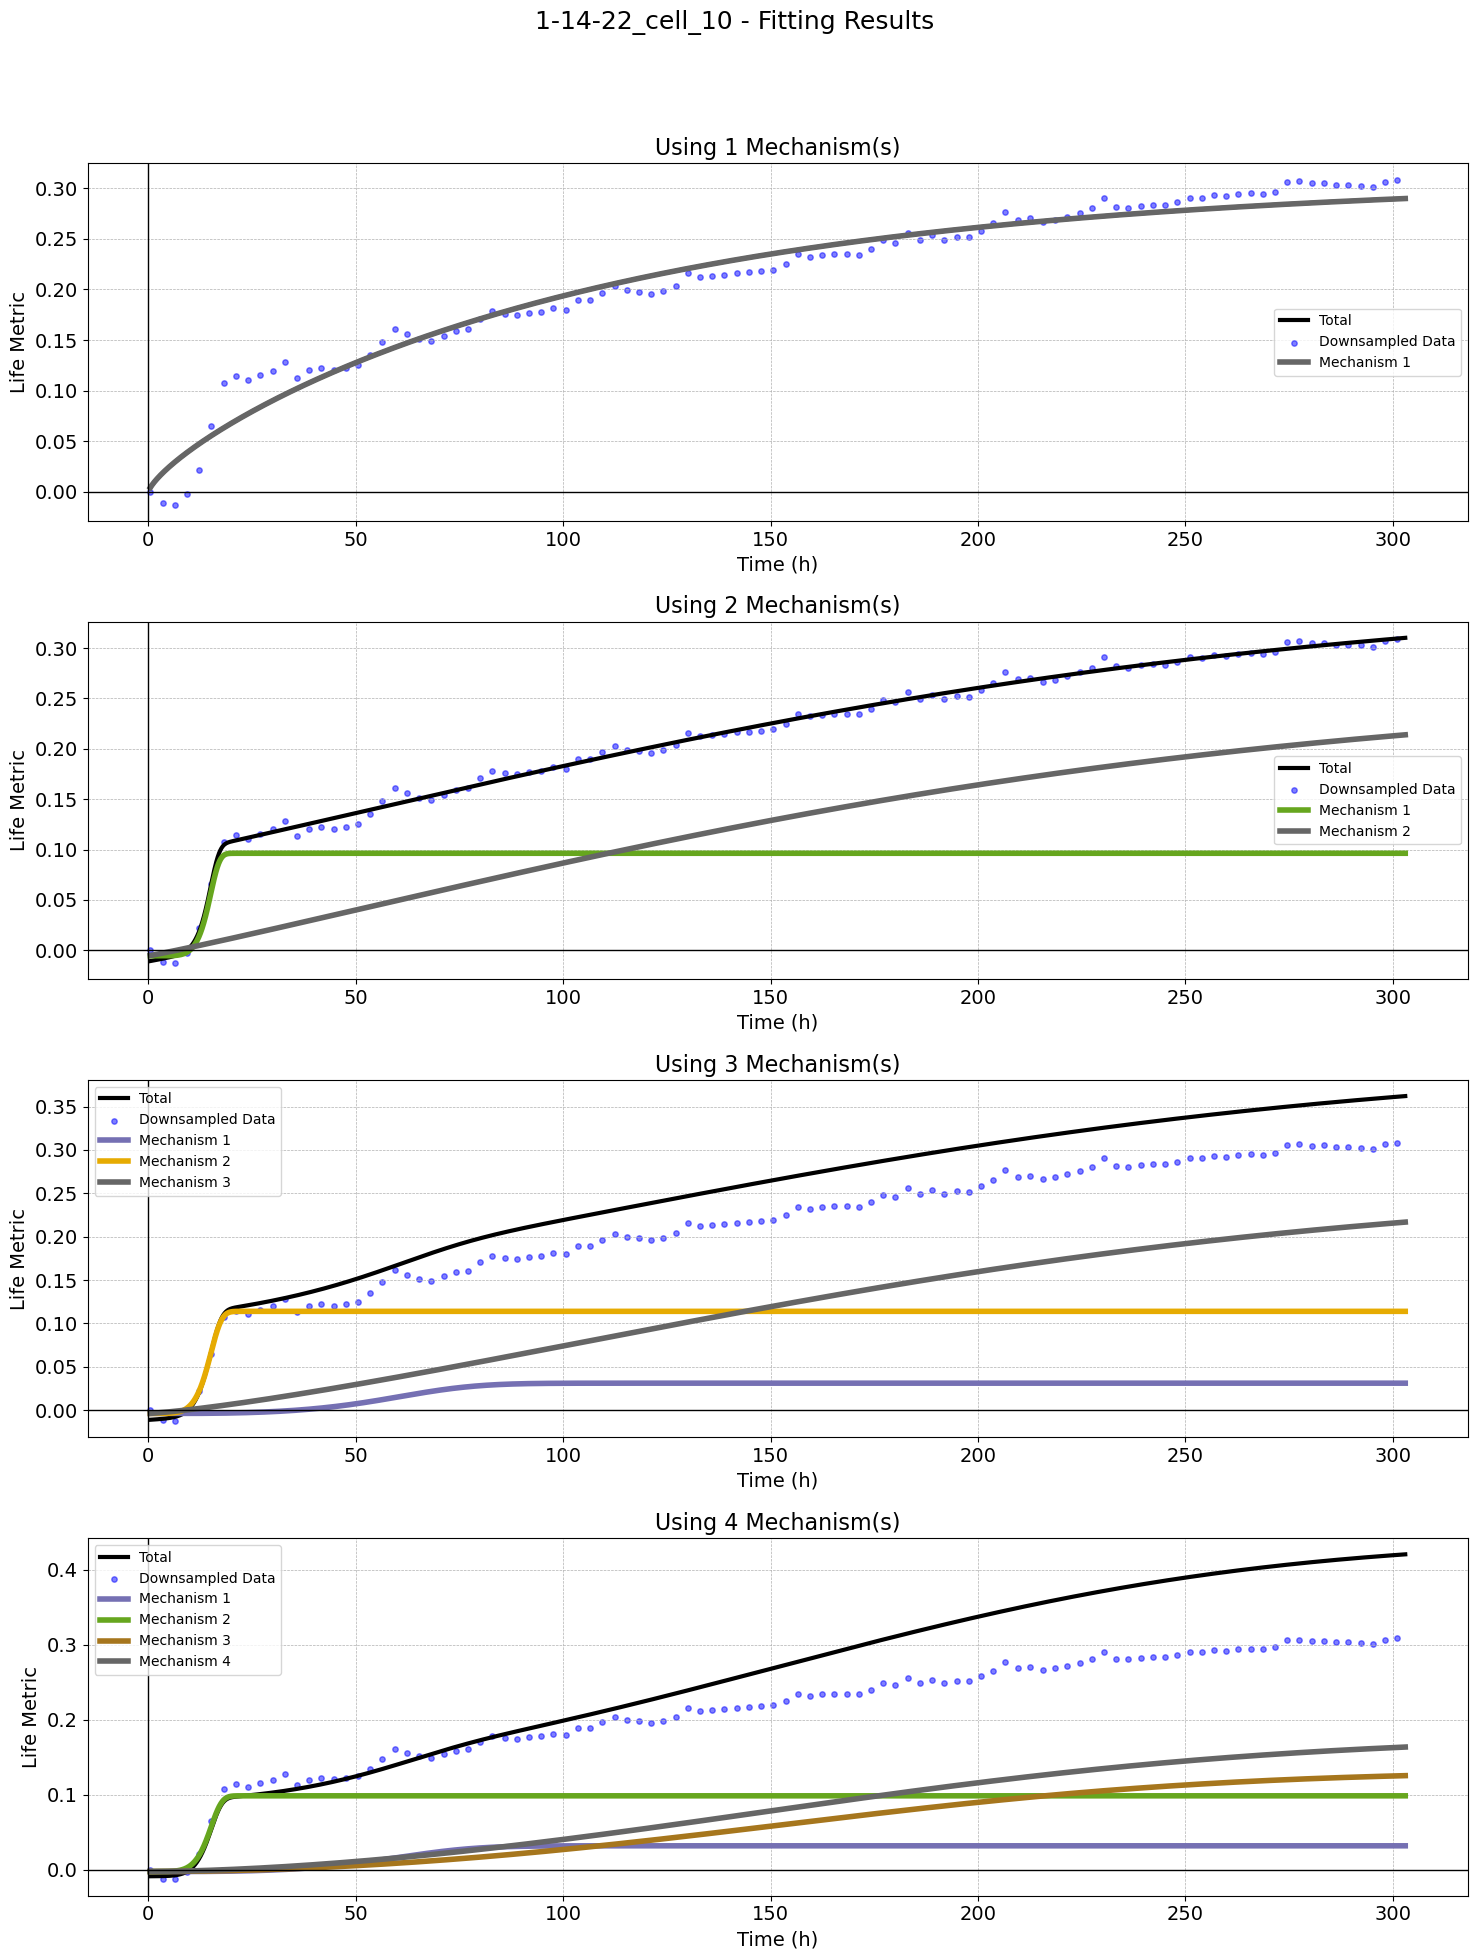

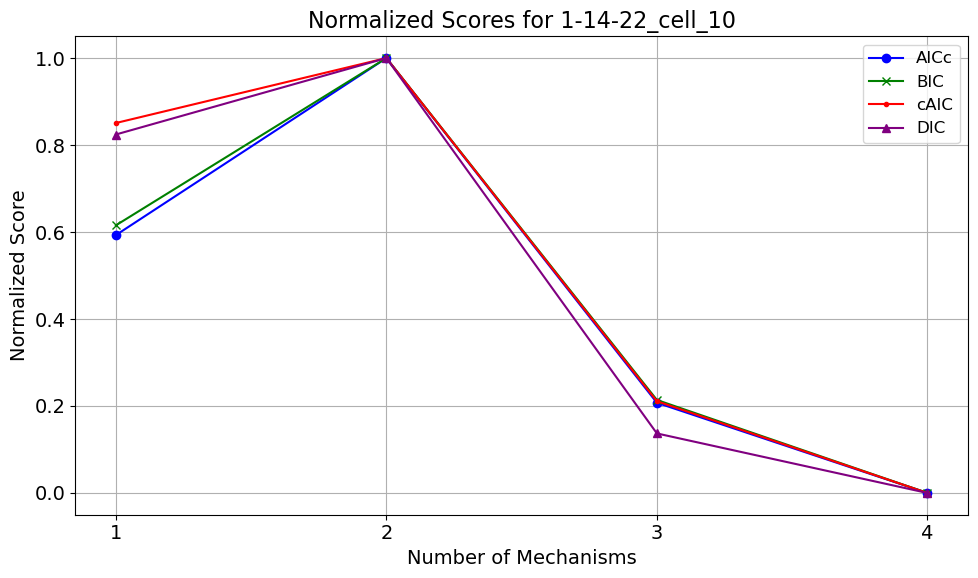

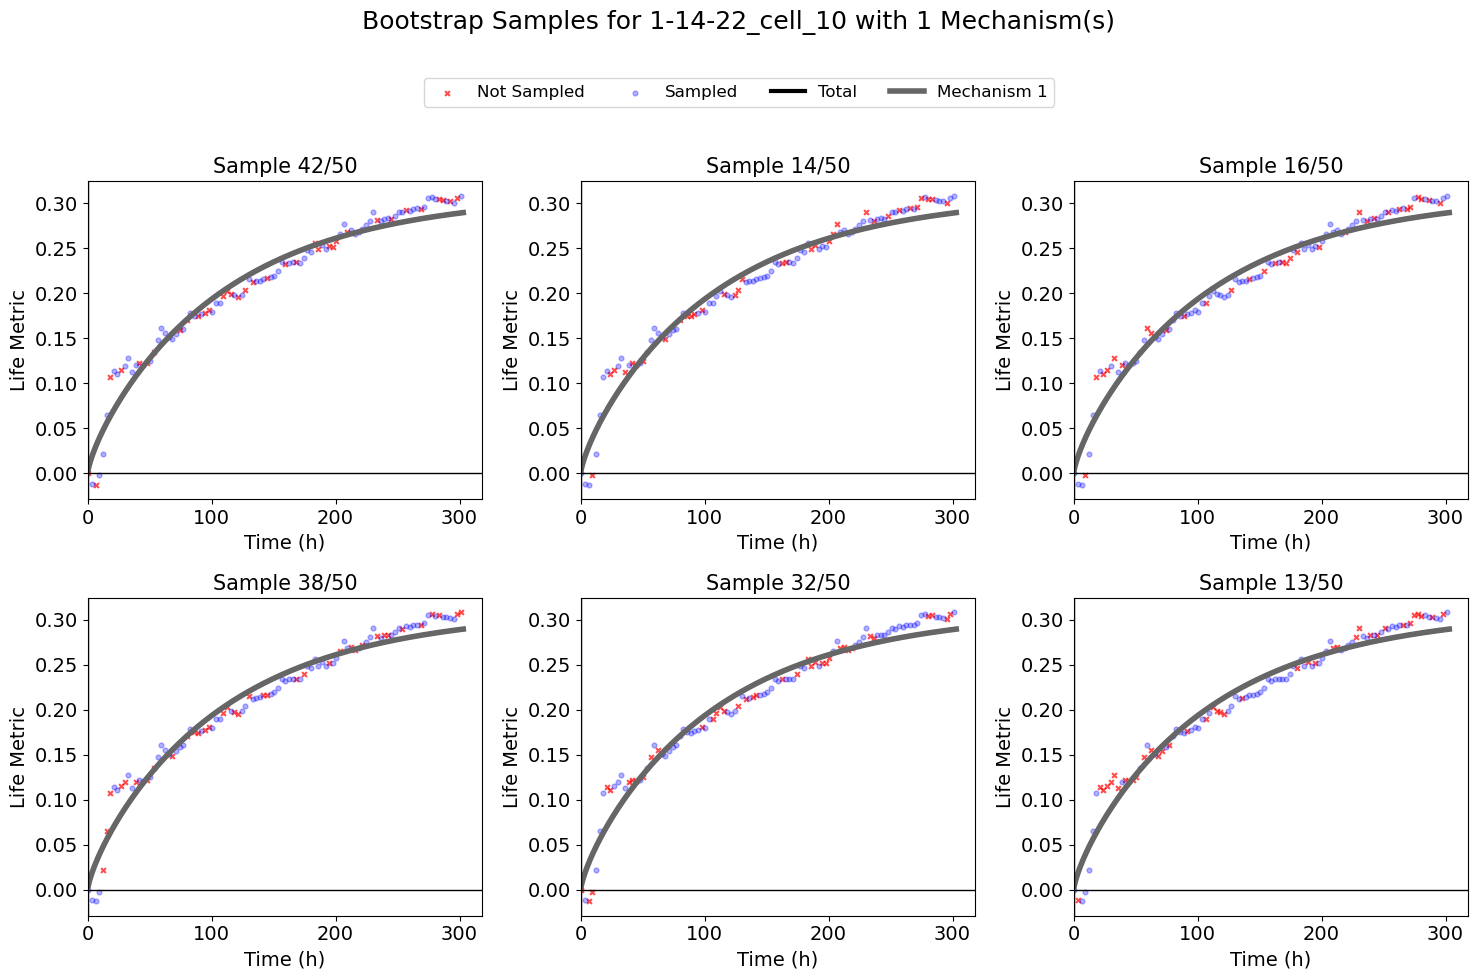

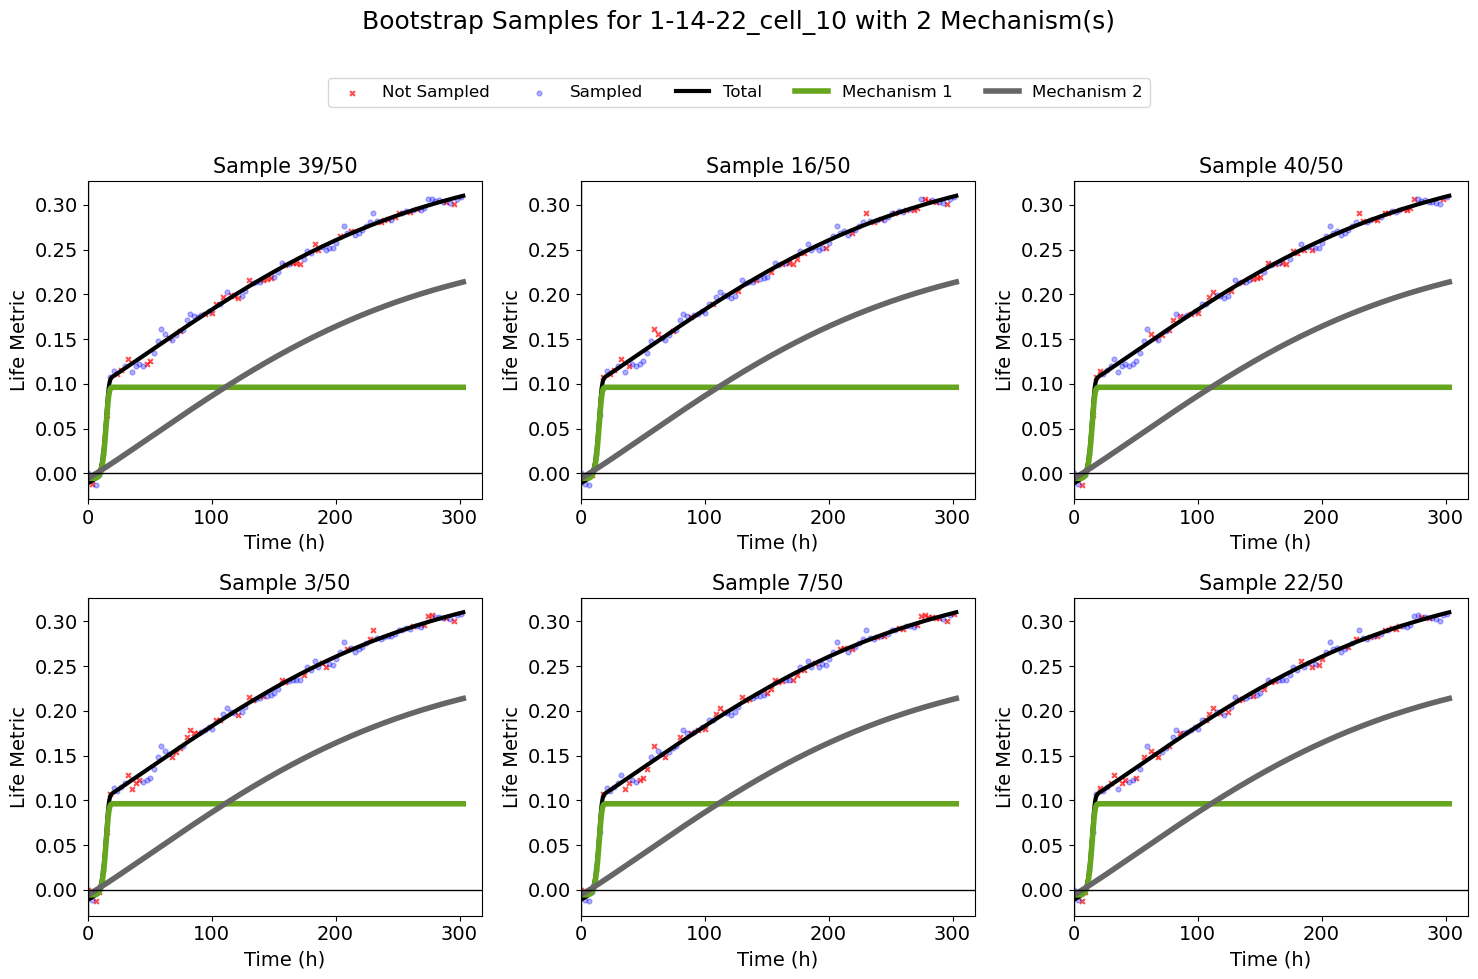

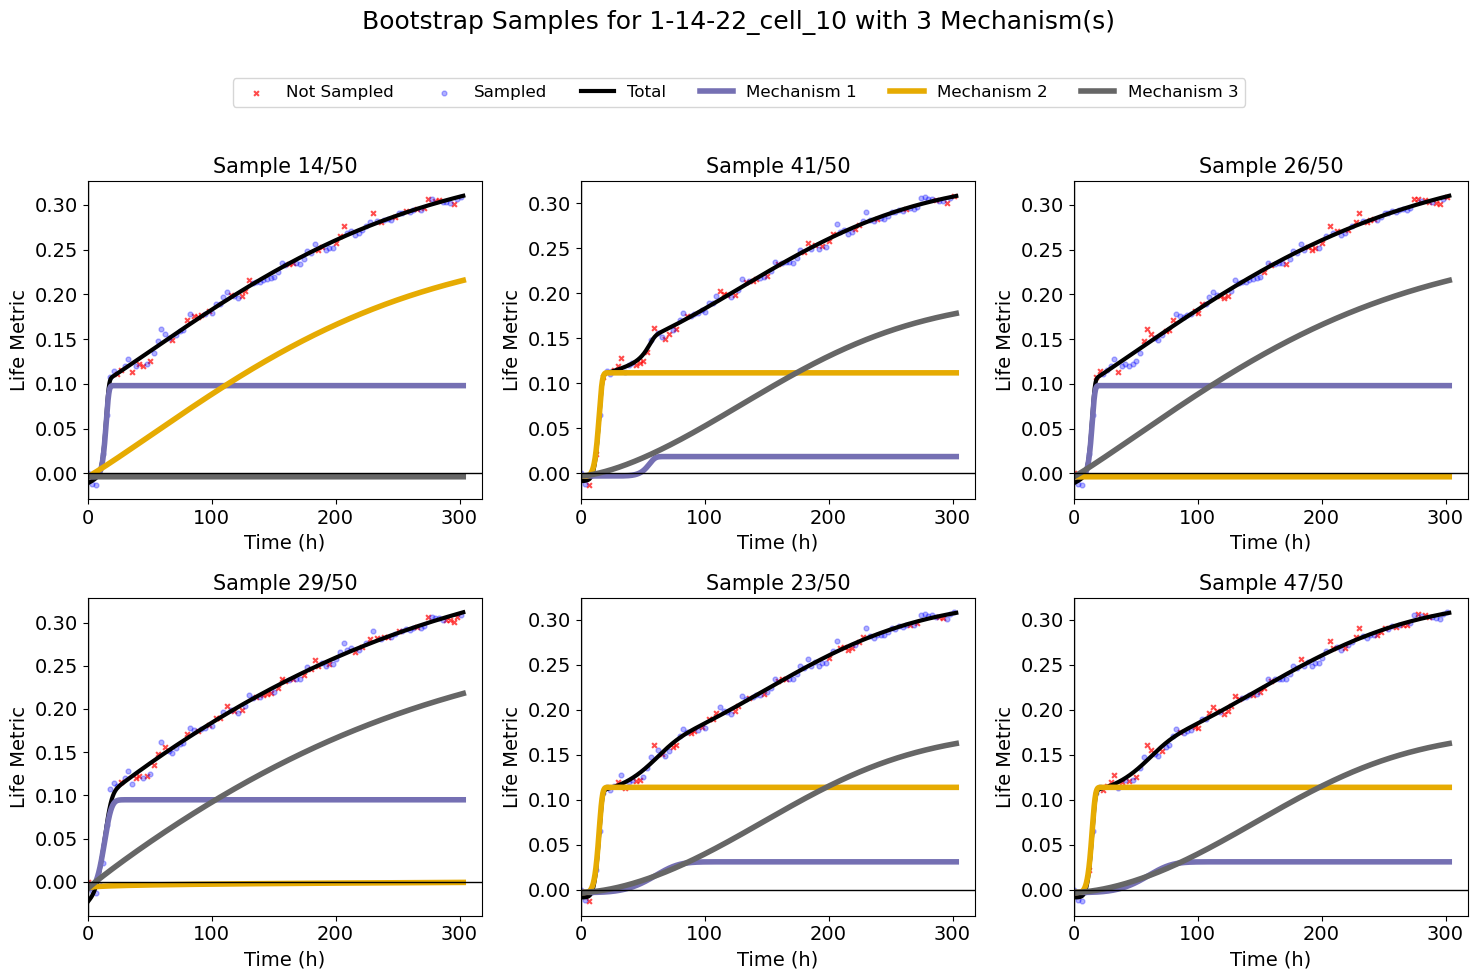

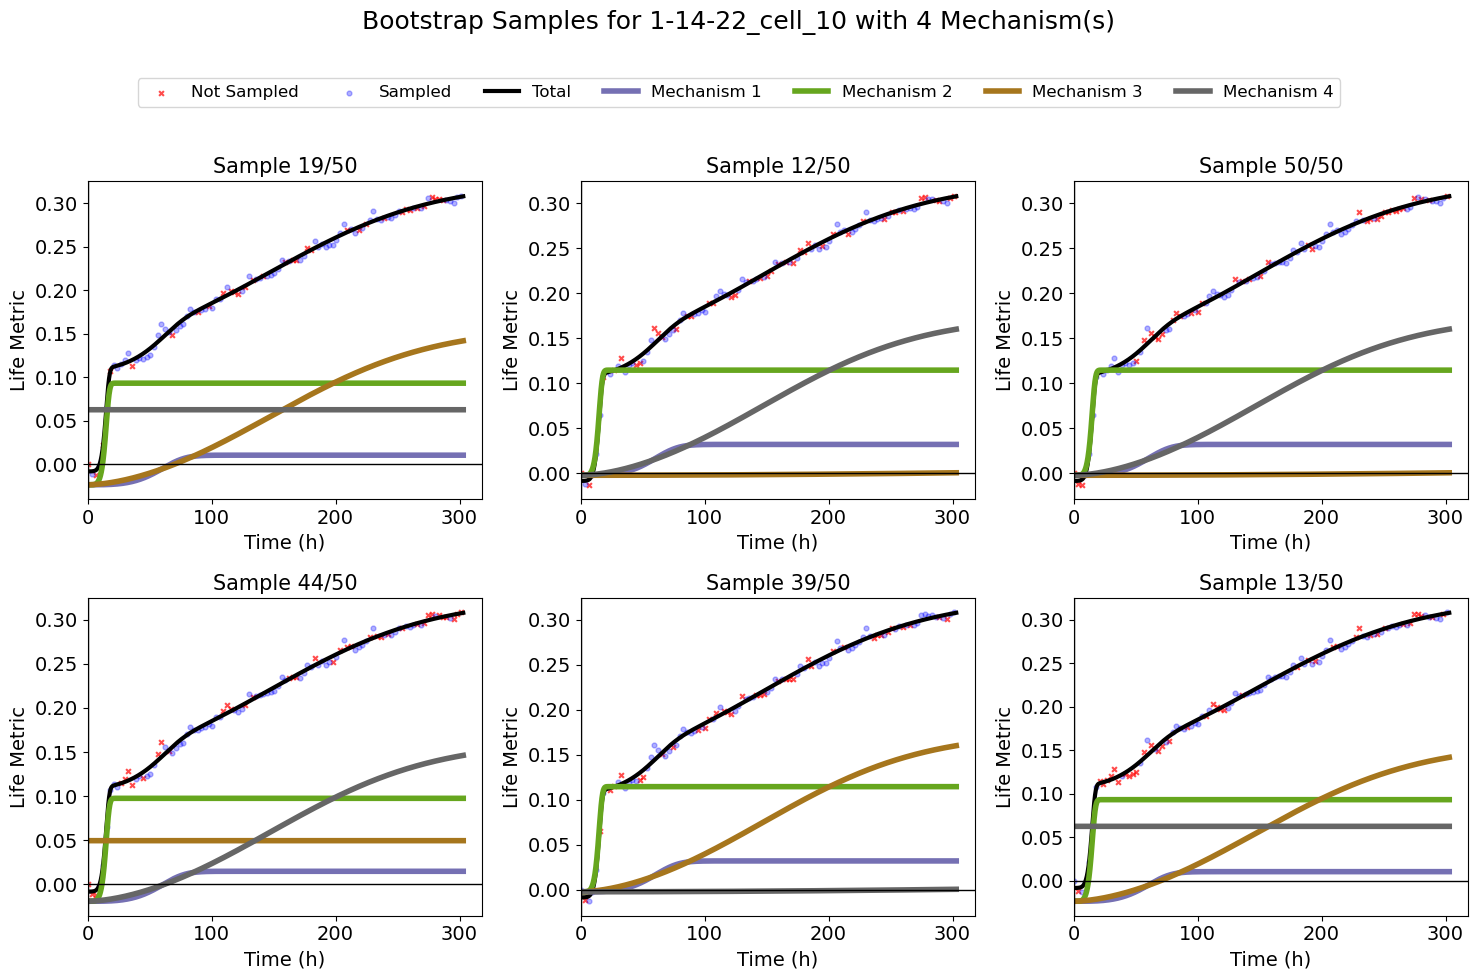

Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0299, 0.0058, 1.1825, 0.2767]
Final (Median) R2: 0.9894
Average R2: 0.9894

AICc: -1577, BIC: -1565, cAIC: -1577, DIC: 39.2
Standard Deviation:6.106e-08
Coefficient of Variation:-4.489e-08

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.0122, 0.0024, 10.0, 0.0347, 0.0069, 1.402, 0.2375]
Final (Median) R2: 0.9930
Average R2: 0.9927

AICc: -1640, BIC: -1619, cAIC: -1578, DIC: 40.17
Standard Deviation:0.3585
Coefficient of Variation:0.3808

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.024, 0.0069, 6.1884, 0.0039, 0.0025, 1.402, 0.1173, 0.0059, 1.402, 0.2044]
Final (Median) R2: 0.8706
Average R2: 0.9932

AICc: -1138, BIC: -1108, cAIC: -1040, DIC: 23.61
Standard Deviation:0.9866
Coefficient of Variation:0.8658

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.0131, 0.0262, 1.4507, 0.0144, 0.0161, 10.0, 0.0369, 0.0025, 6.4009, 0.0533, 0.0061, 1.913, 0.1854]
Final (Median) R2: 0.9613
Average R2:

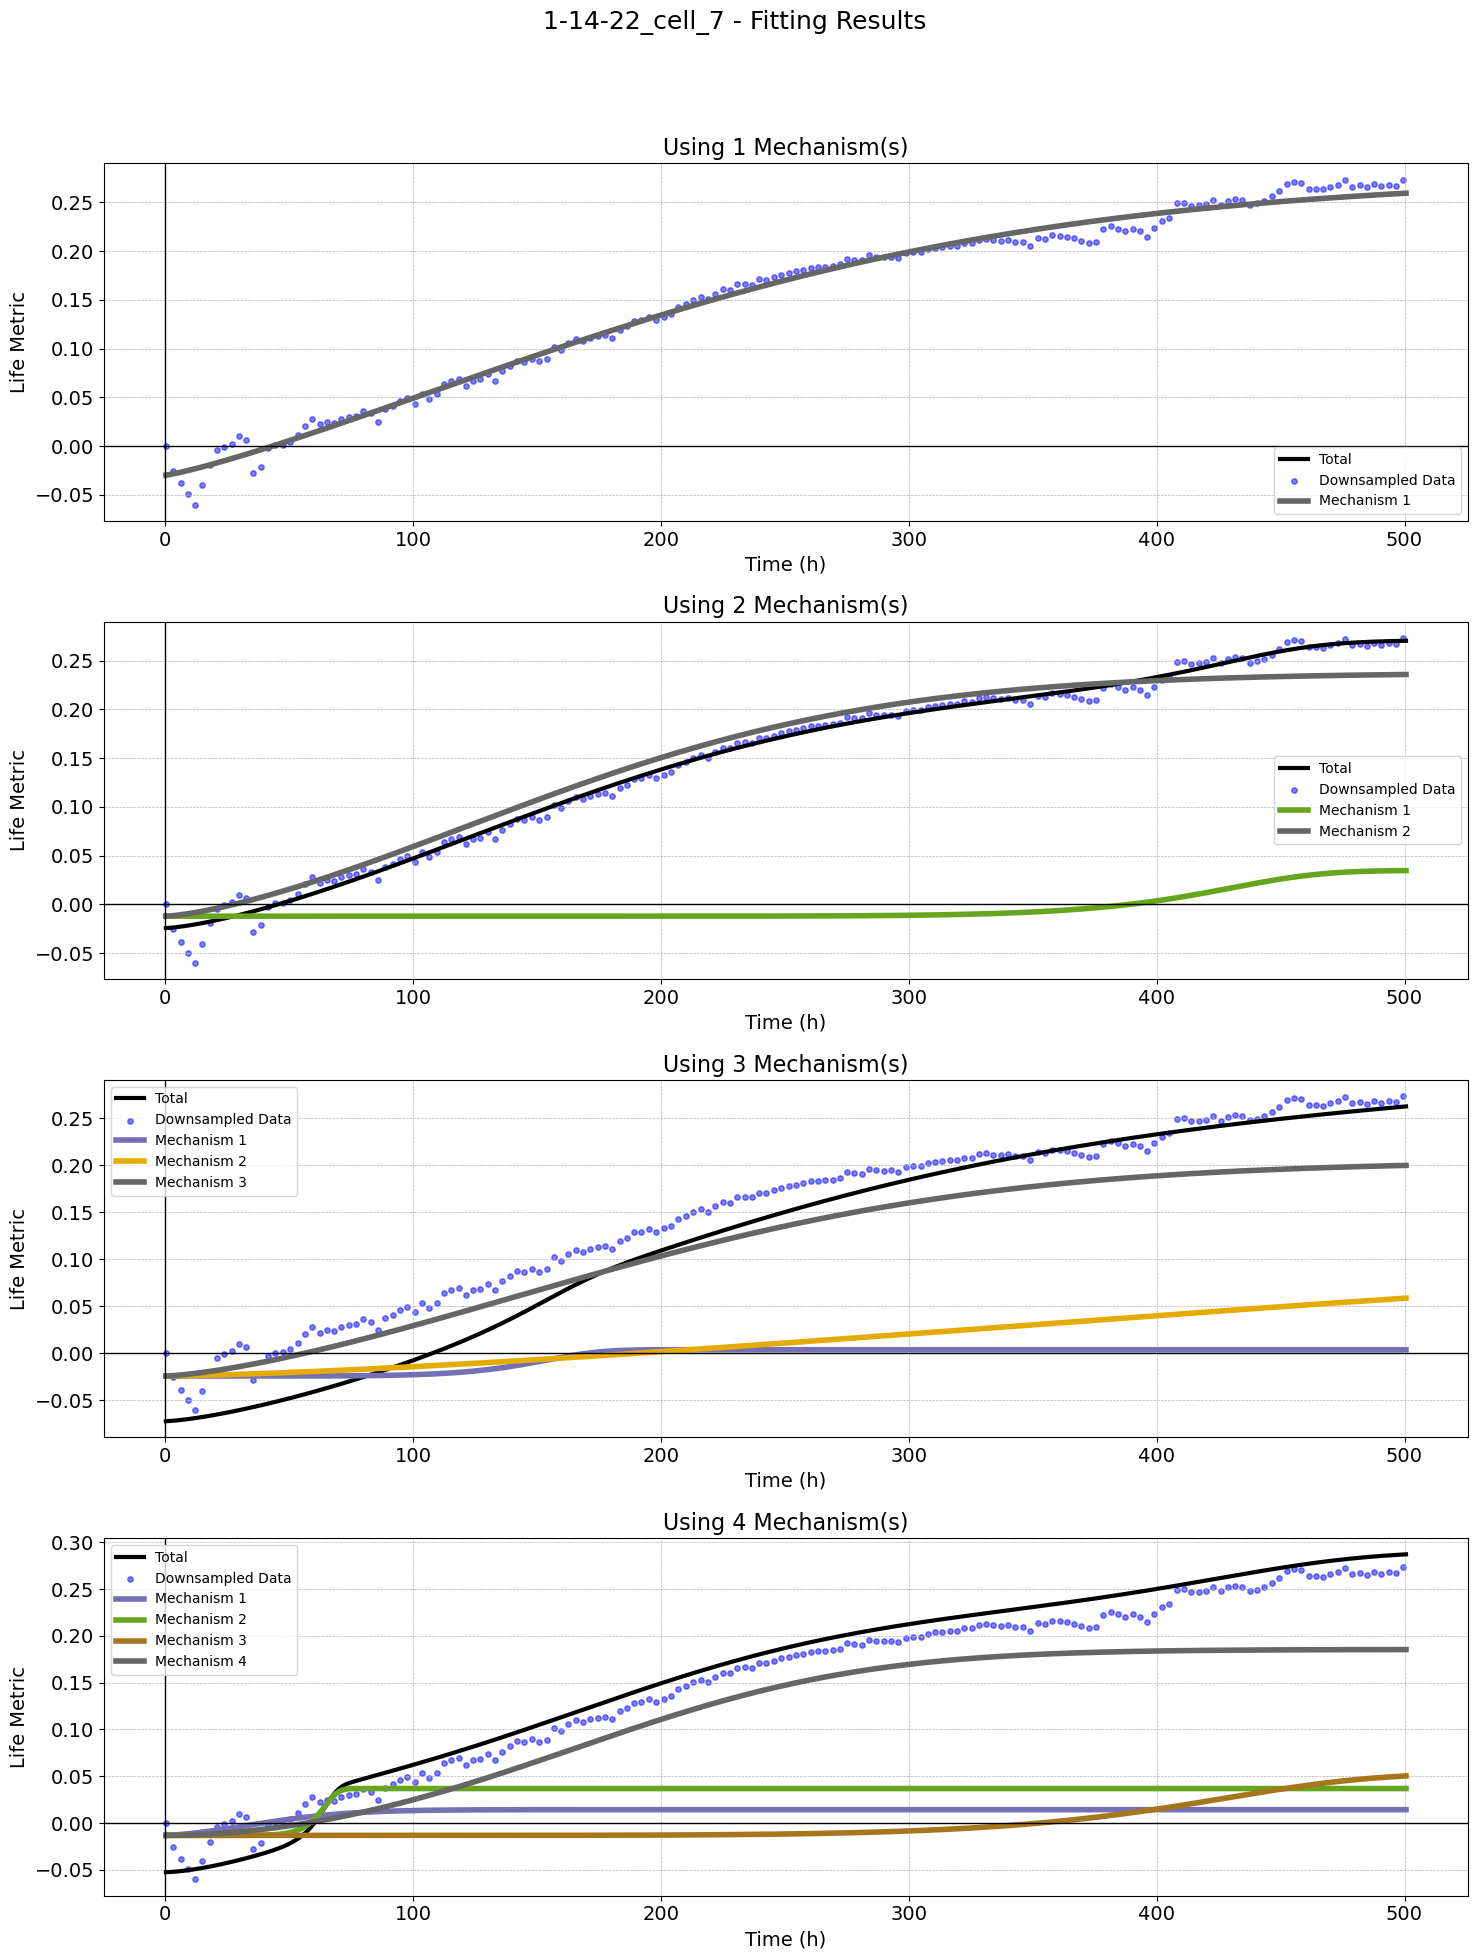

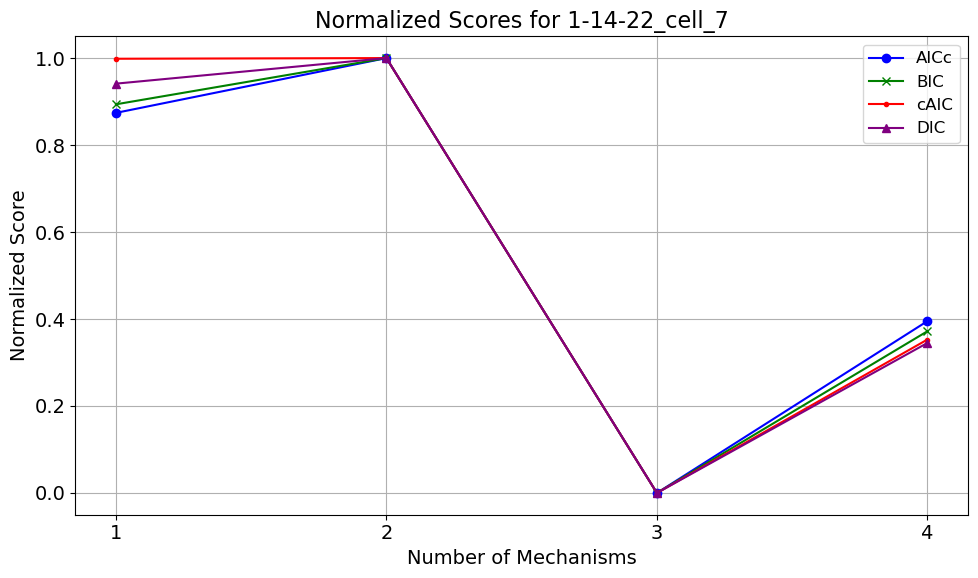

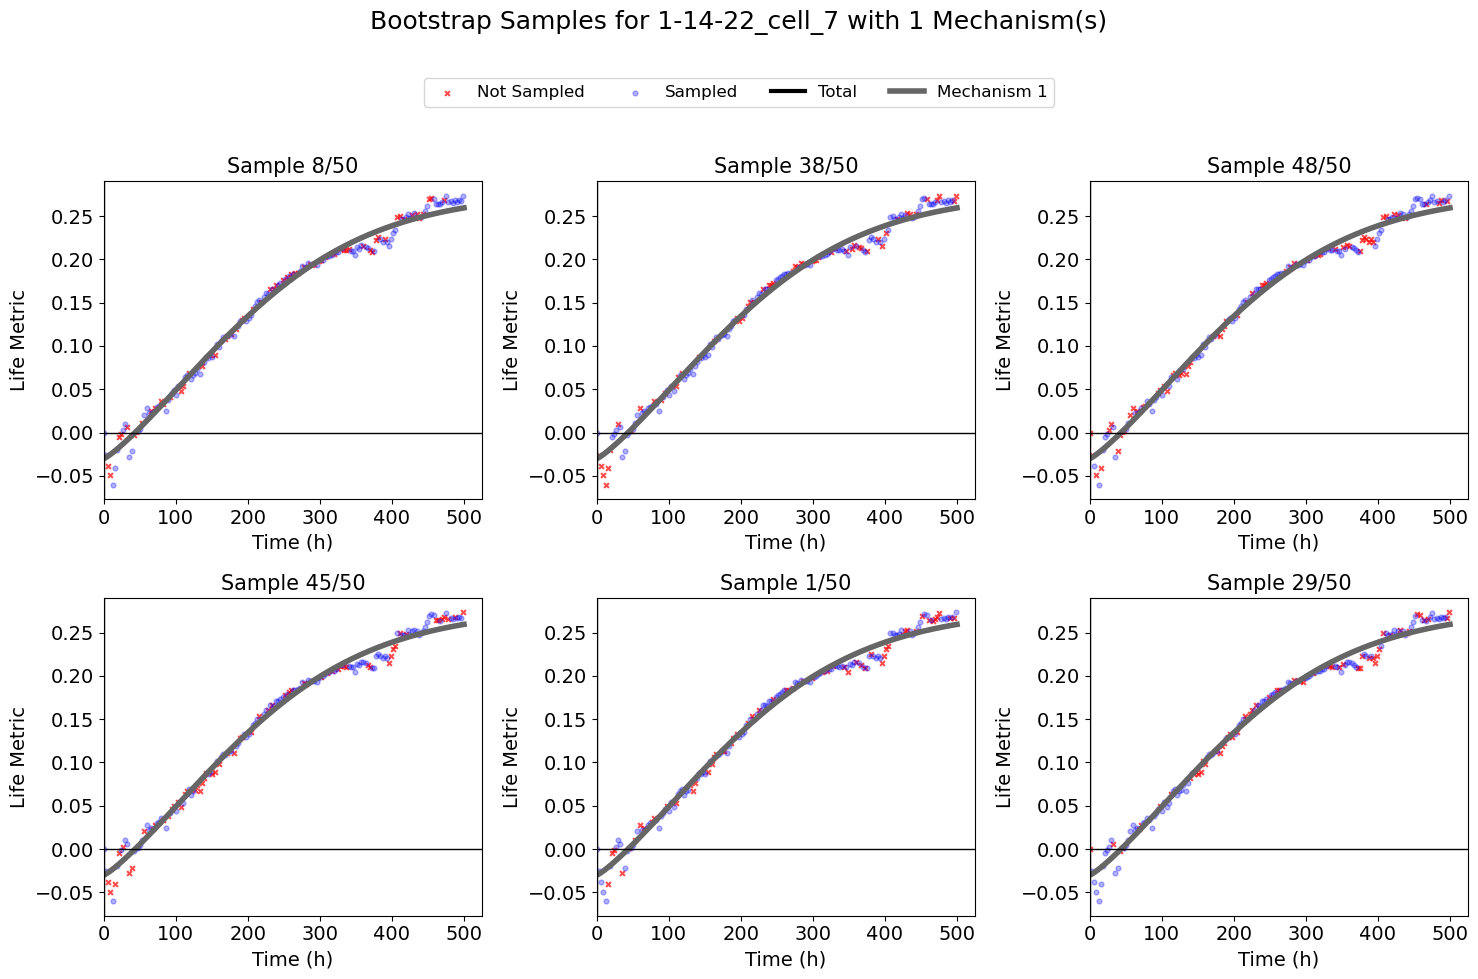

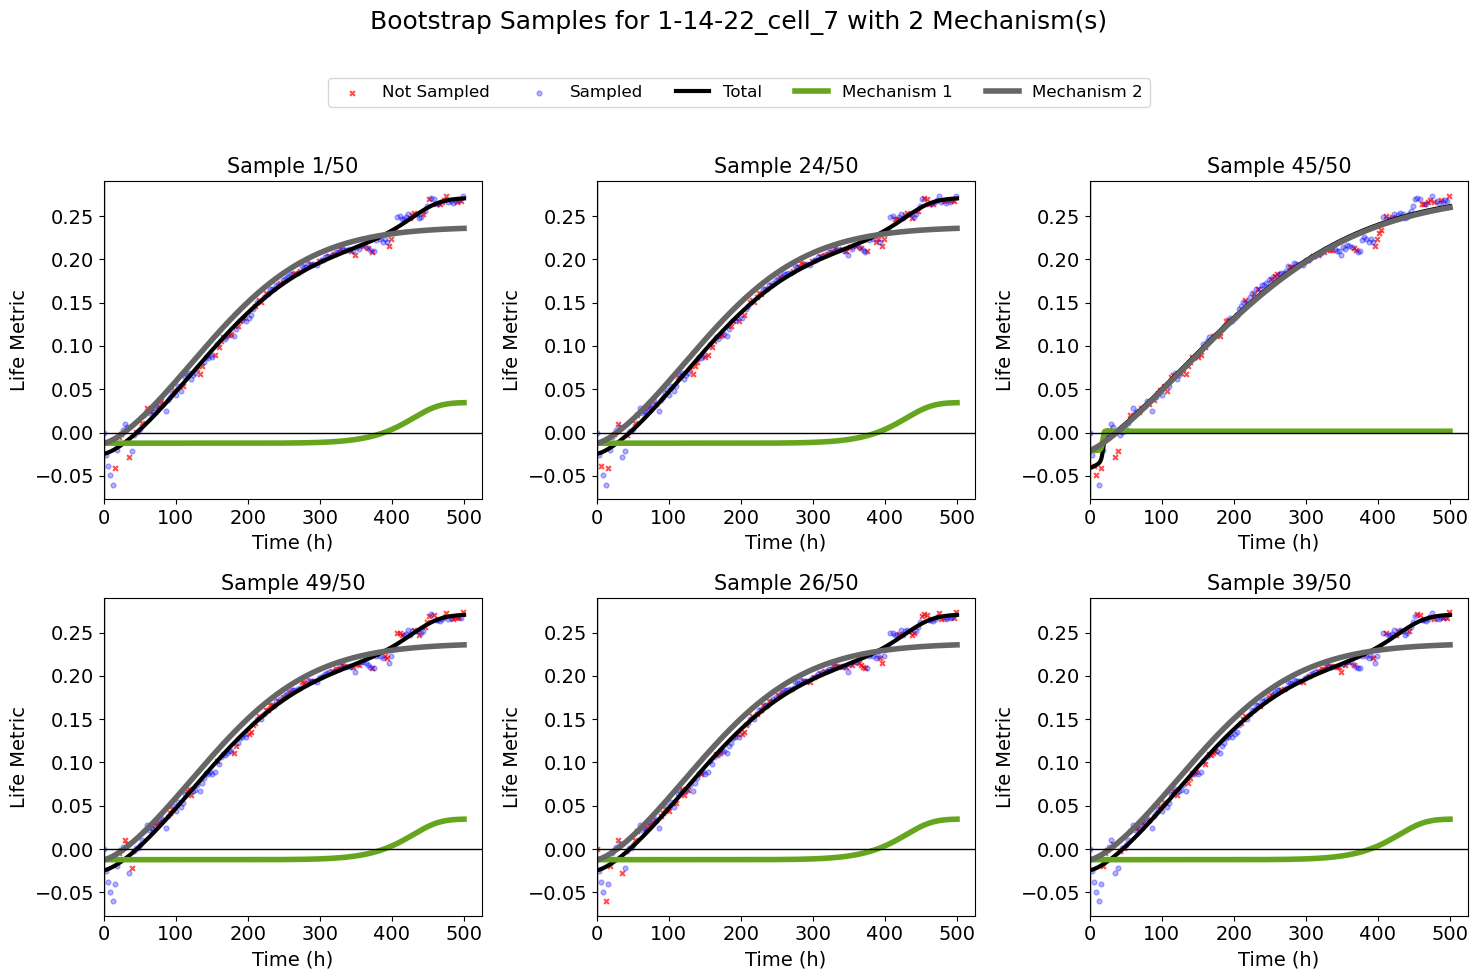

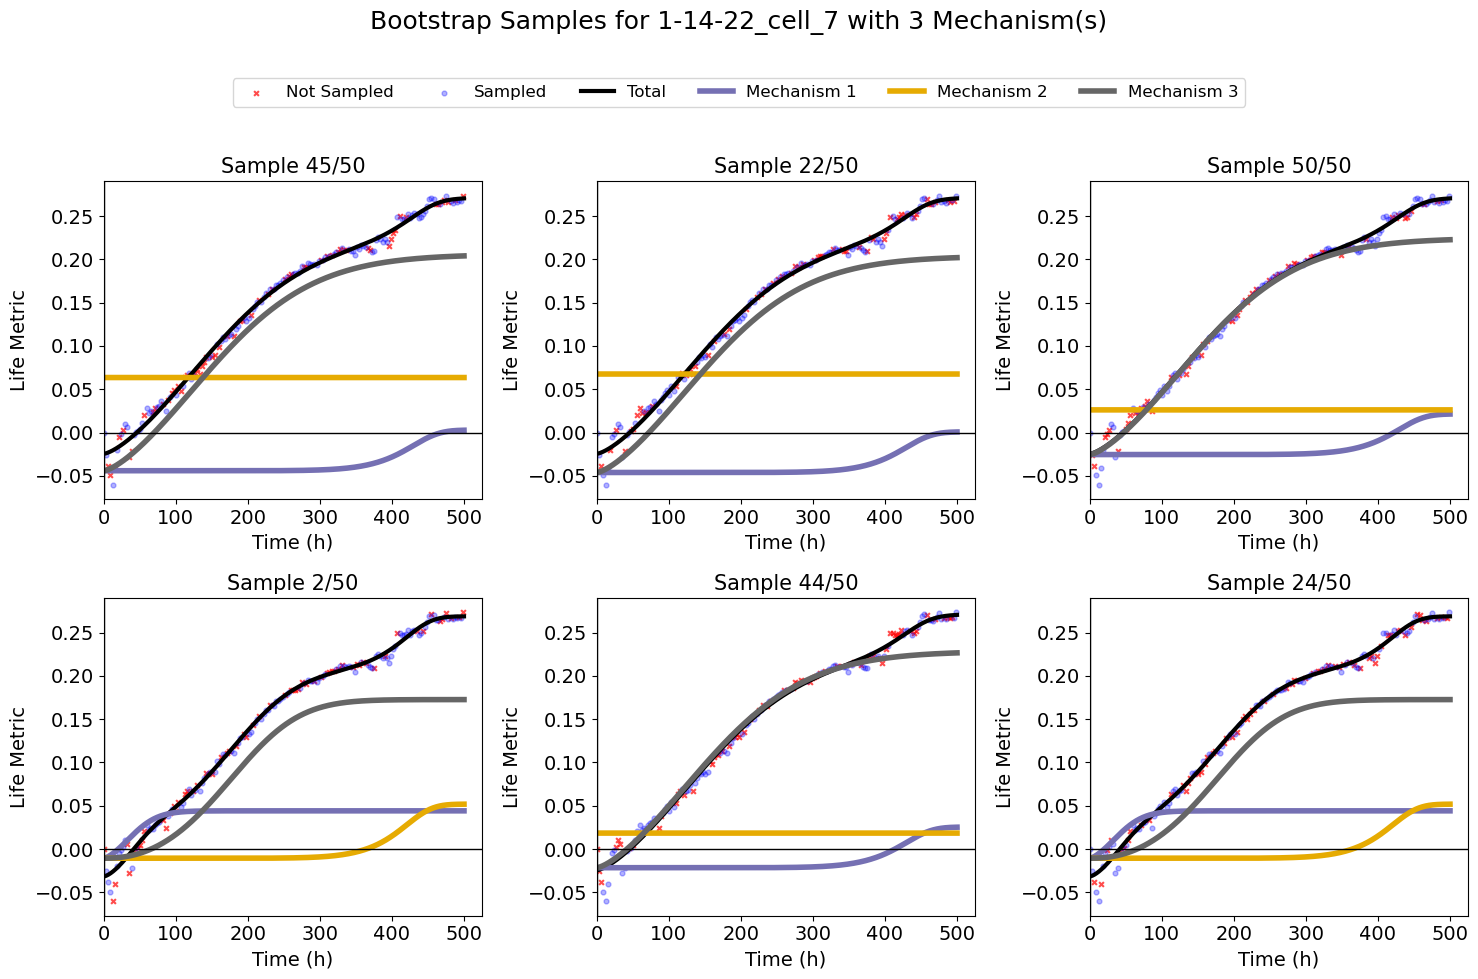

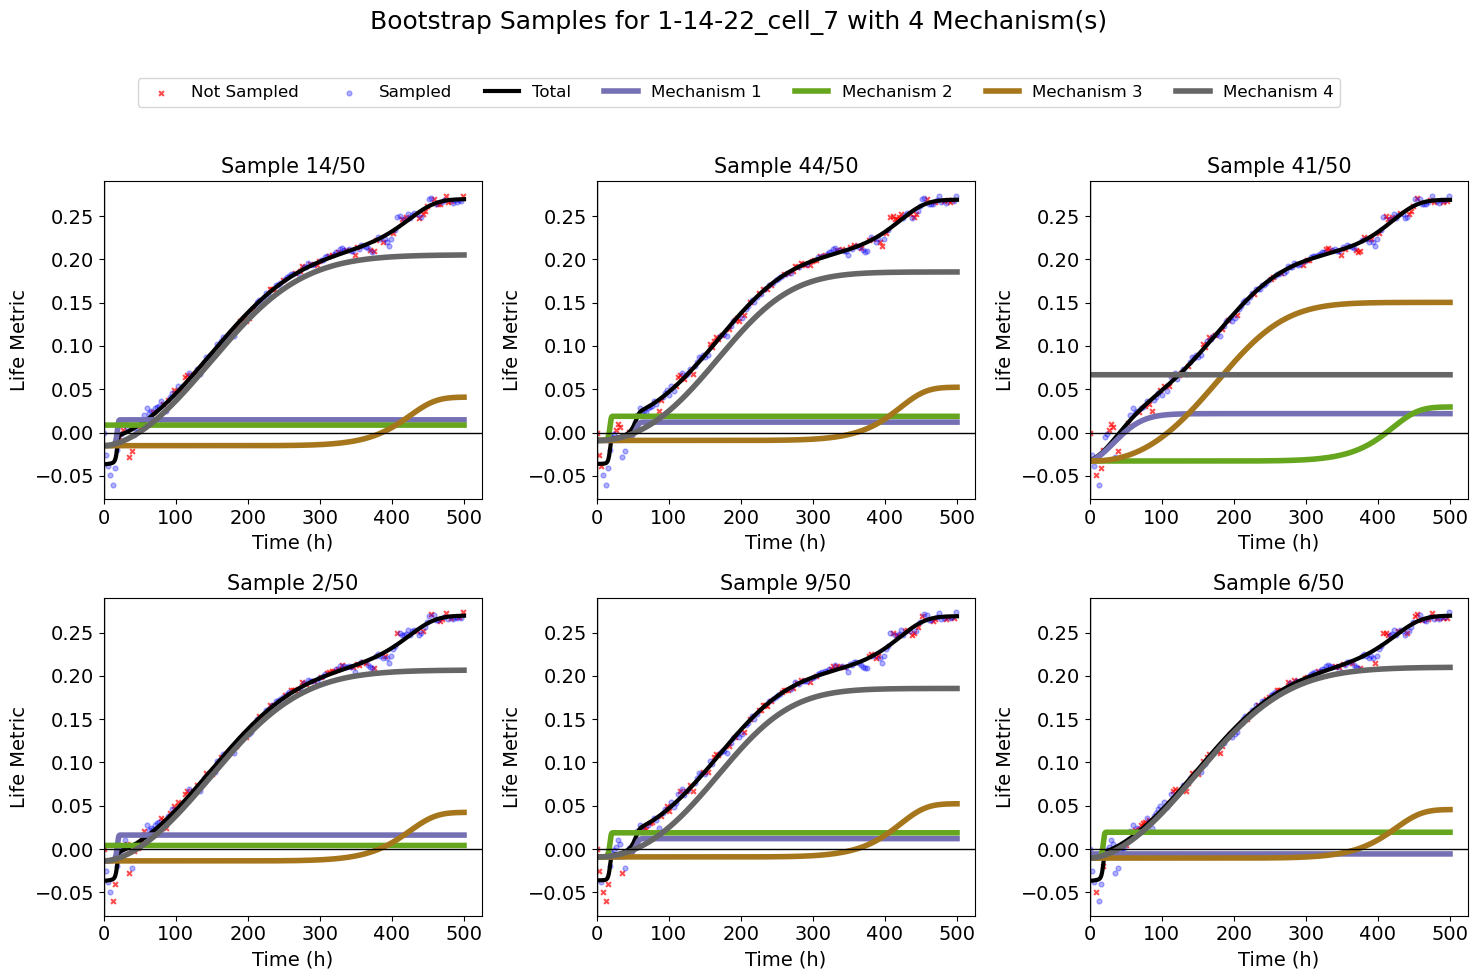

Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0321, 0.0192, 0.6455, 0.3243]
Final (Median) R2: 0.9863
Average R2: 0.9863

AICc: -1584, BIC: -1571, cAIC: -1584, DIC: 39.27
Standard Deviation:5.448e-08
Coefficient of Variation:1.557e-07

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.0138, 0.0465, 3.2512, 0.0847, 0.0111, 0.8822, 0.2355]
Final (Median) R2: 0.9962
Average R2: 0.9962

AICc: -1796, BIC: -1775, cAIC: -1796, DIC: 41.85
Standard Deviation:1.769e-05
Coefficient of Variation:6.956e-06

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.0074, 0.0025, 10.0, 0.012, 0.0476, 2.8445, 0.1111, 0.0103, 1.1693, 0.1964]
Final (Median) R2: 0.9976
Average R2: 0.9975

AICc: -1869, BIC: -1839, cAIC: -1809, DIC: 42.98
Standard Deviation:0.2205
Coefficient of Variation:0.3237

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.005, 0.0025, 10.0, 0.0177, 0.0158, 2.0076, 0.0555, 0.007, 1.8423, 0.1169, 0.0486, 2.6854, 0.1288]
Final (Median) R2: 0.9979
Ave

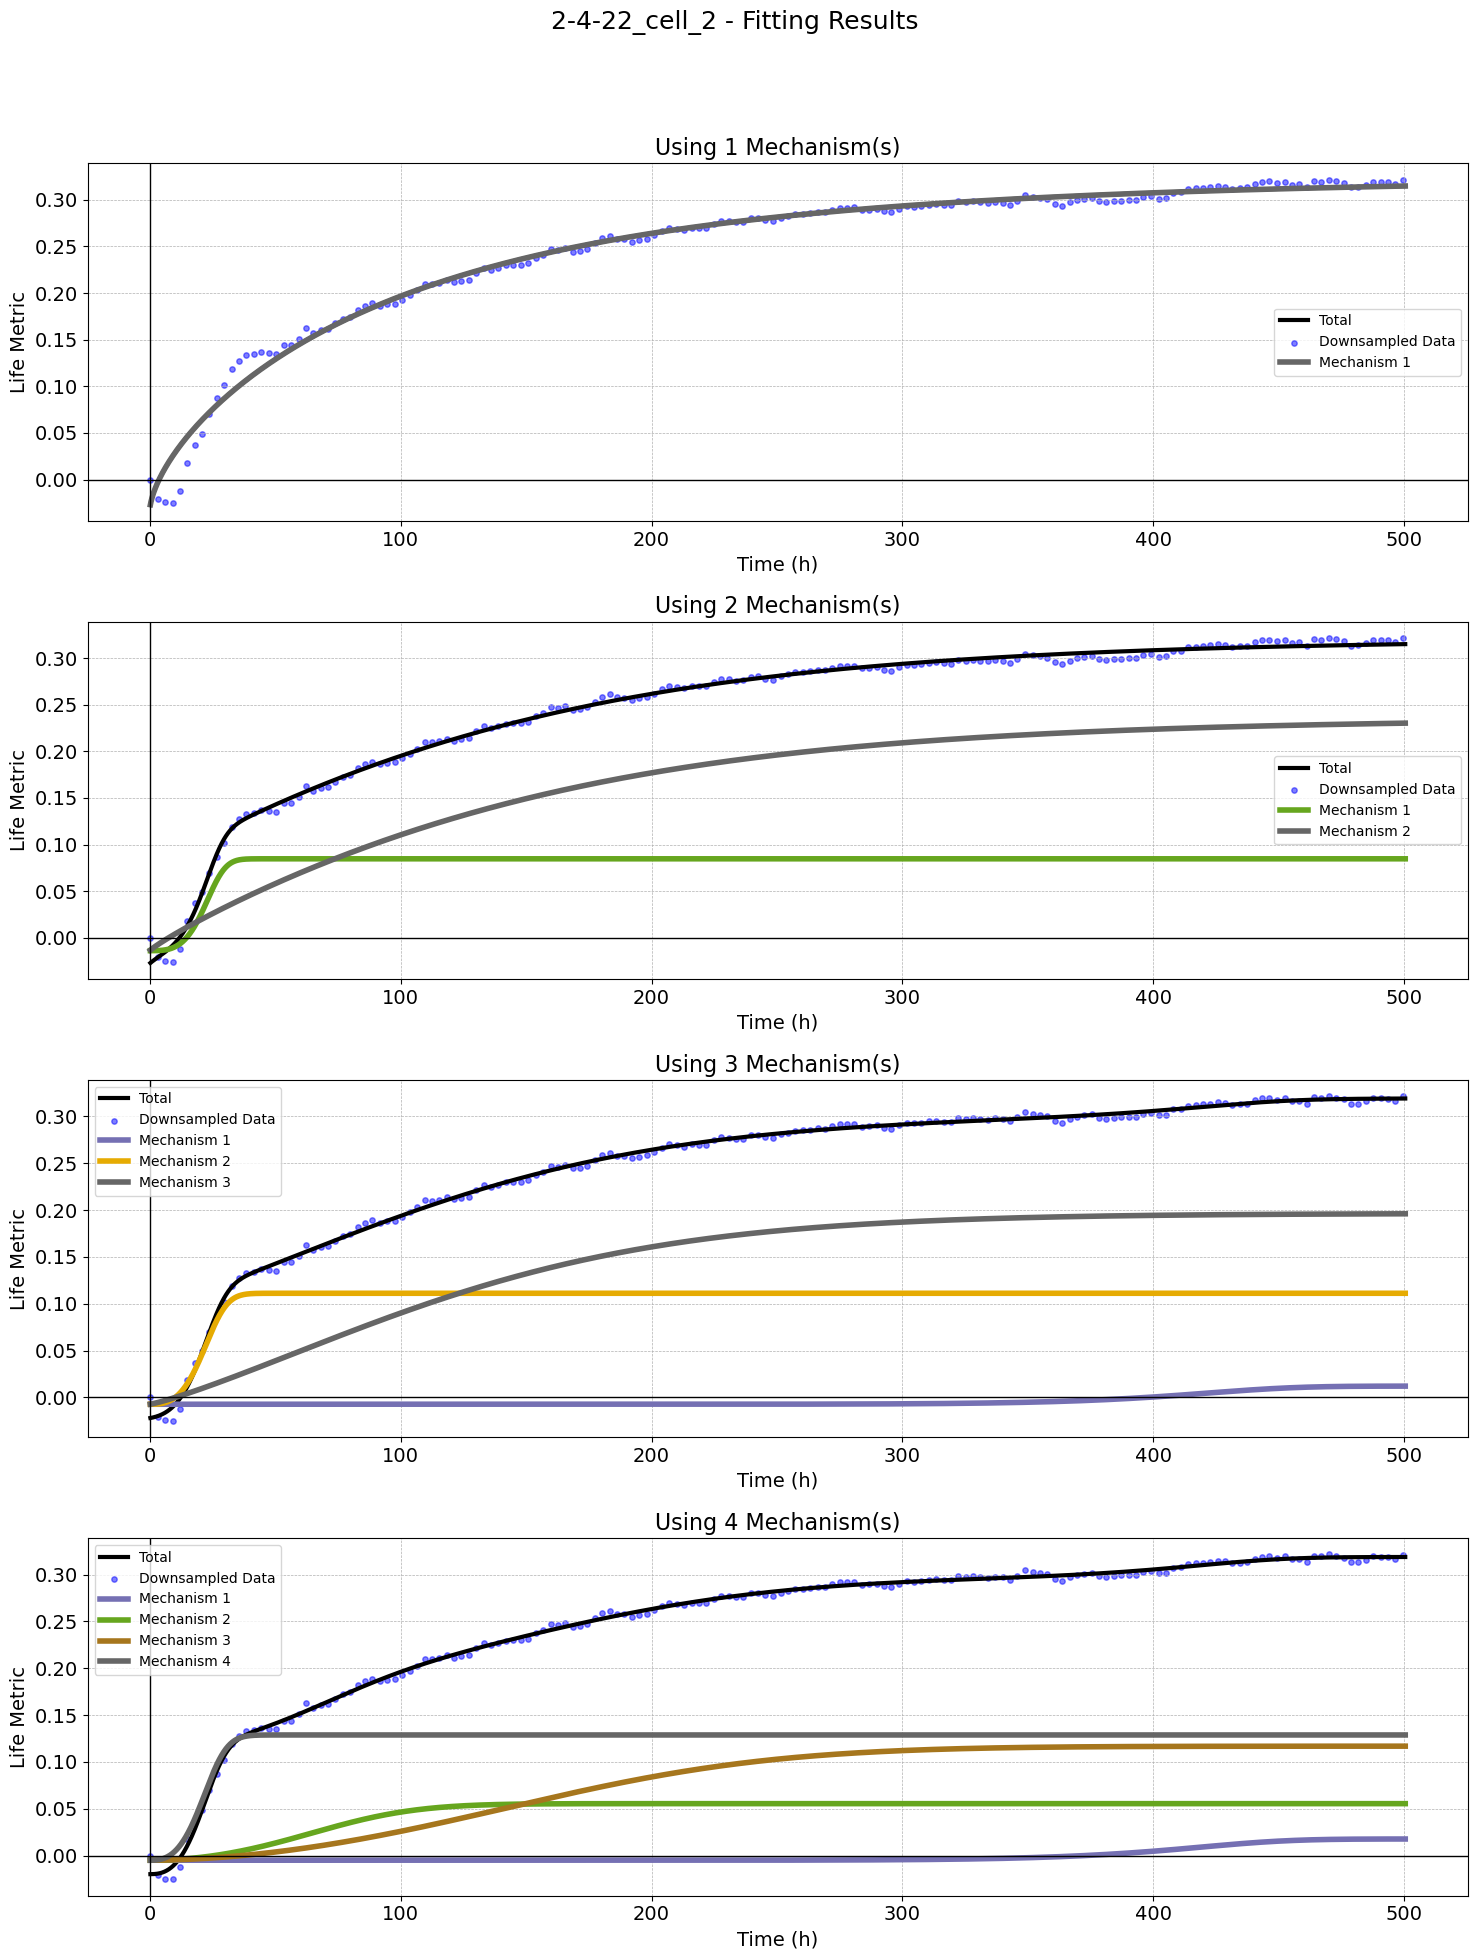

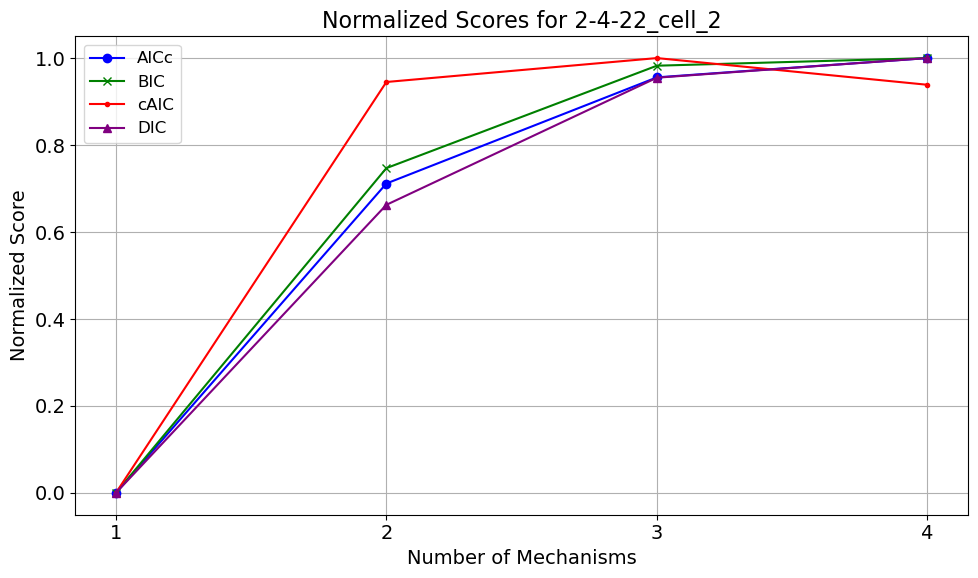

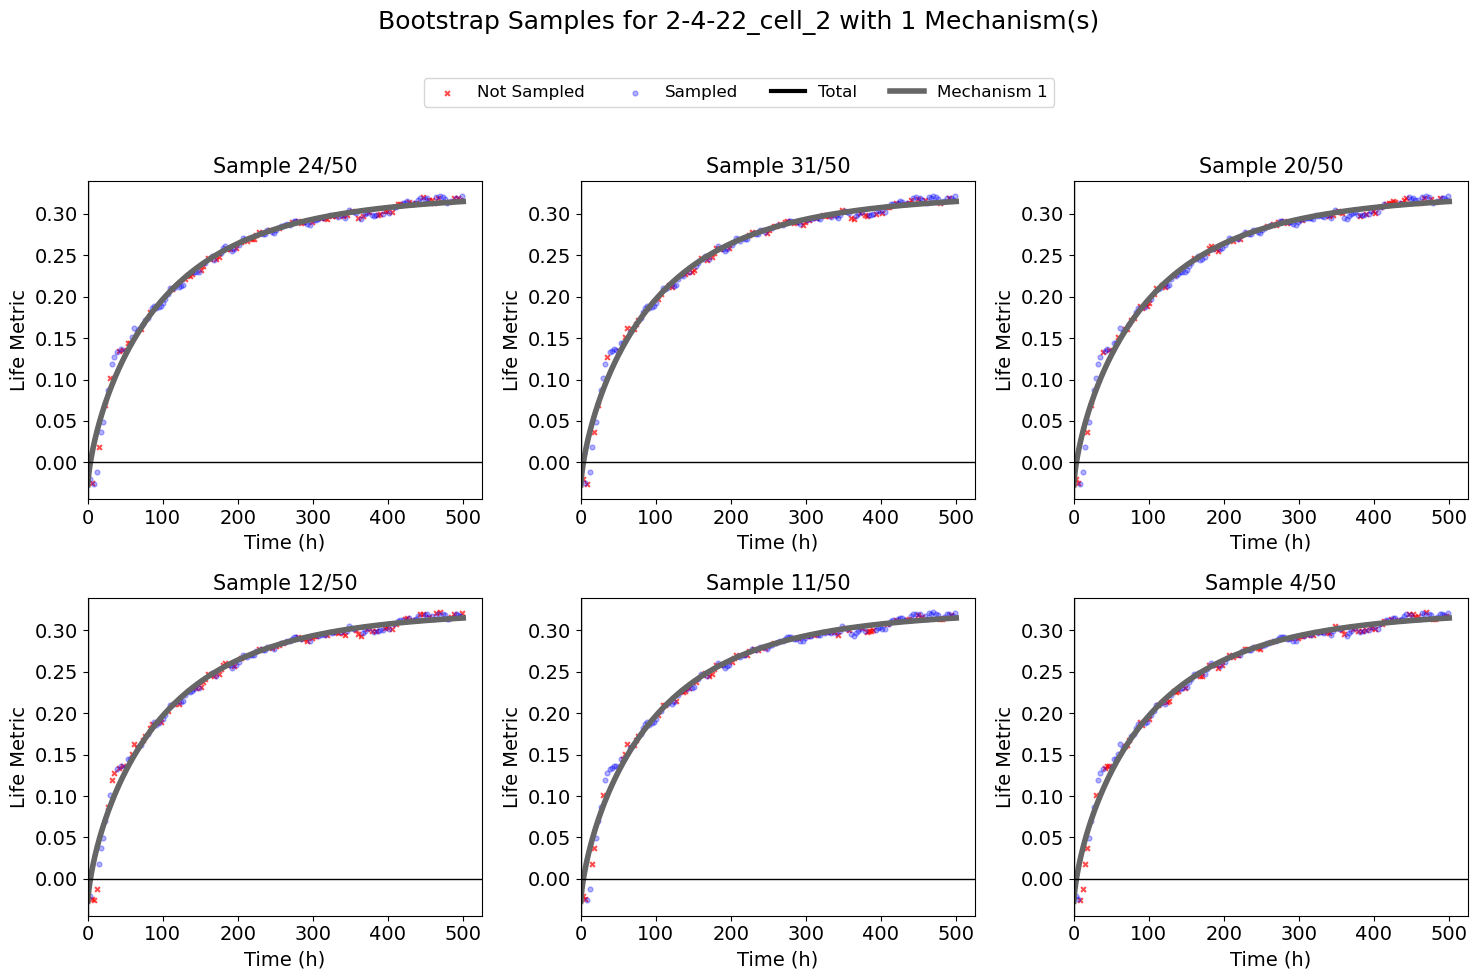

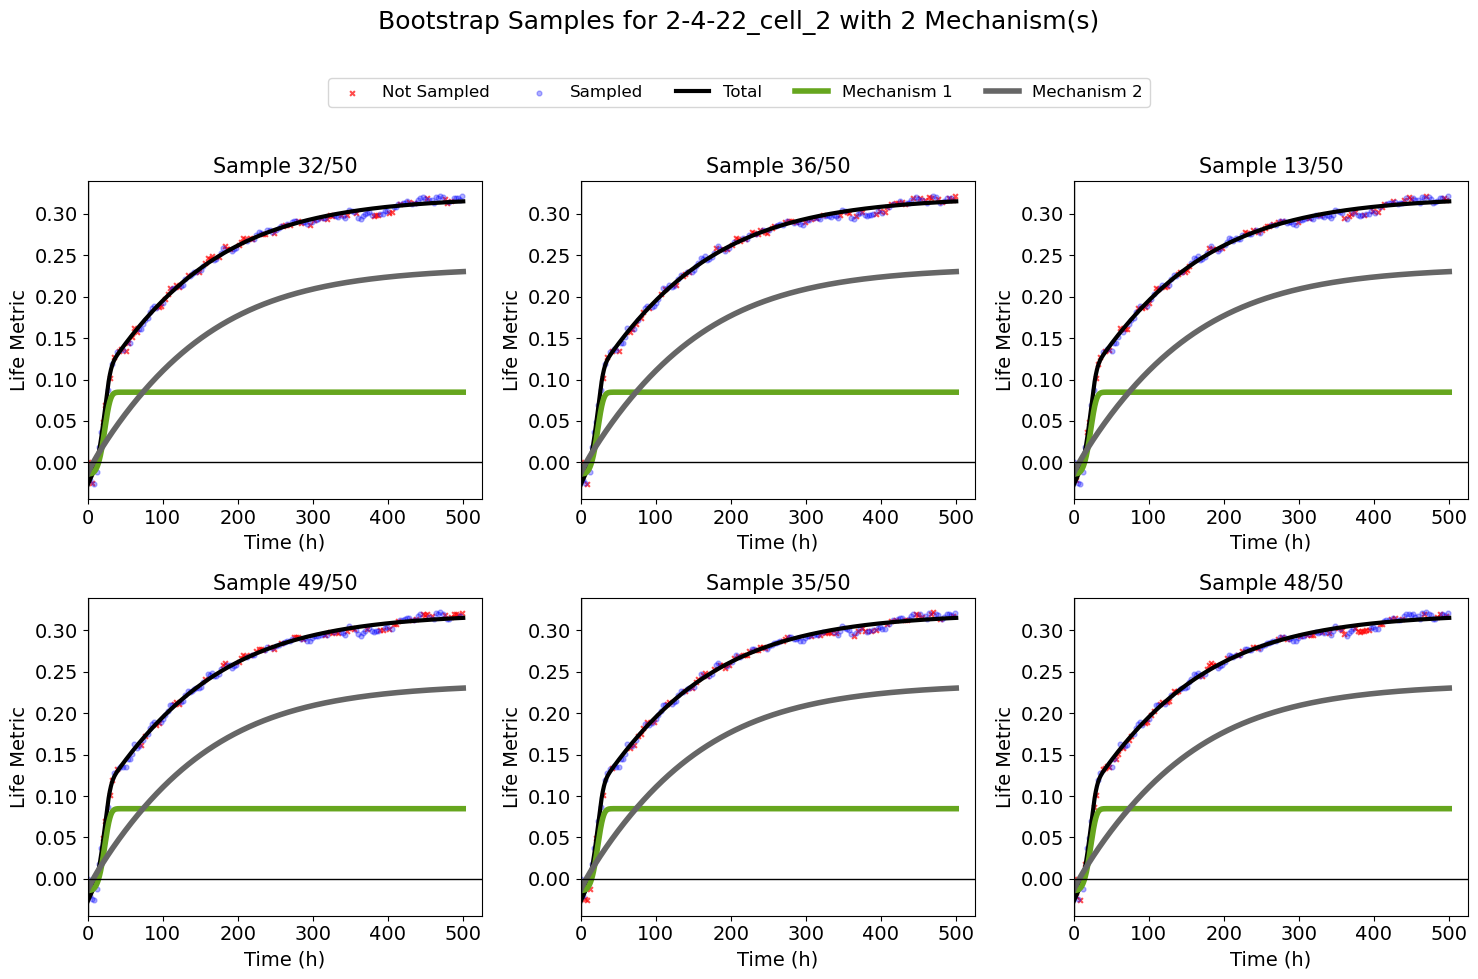

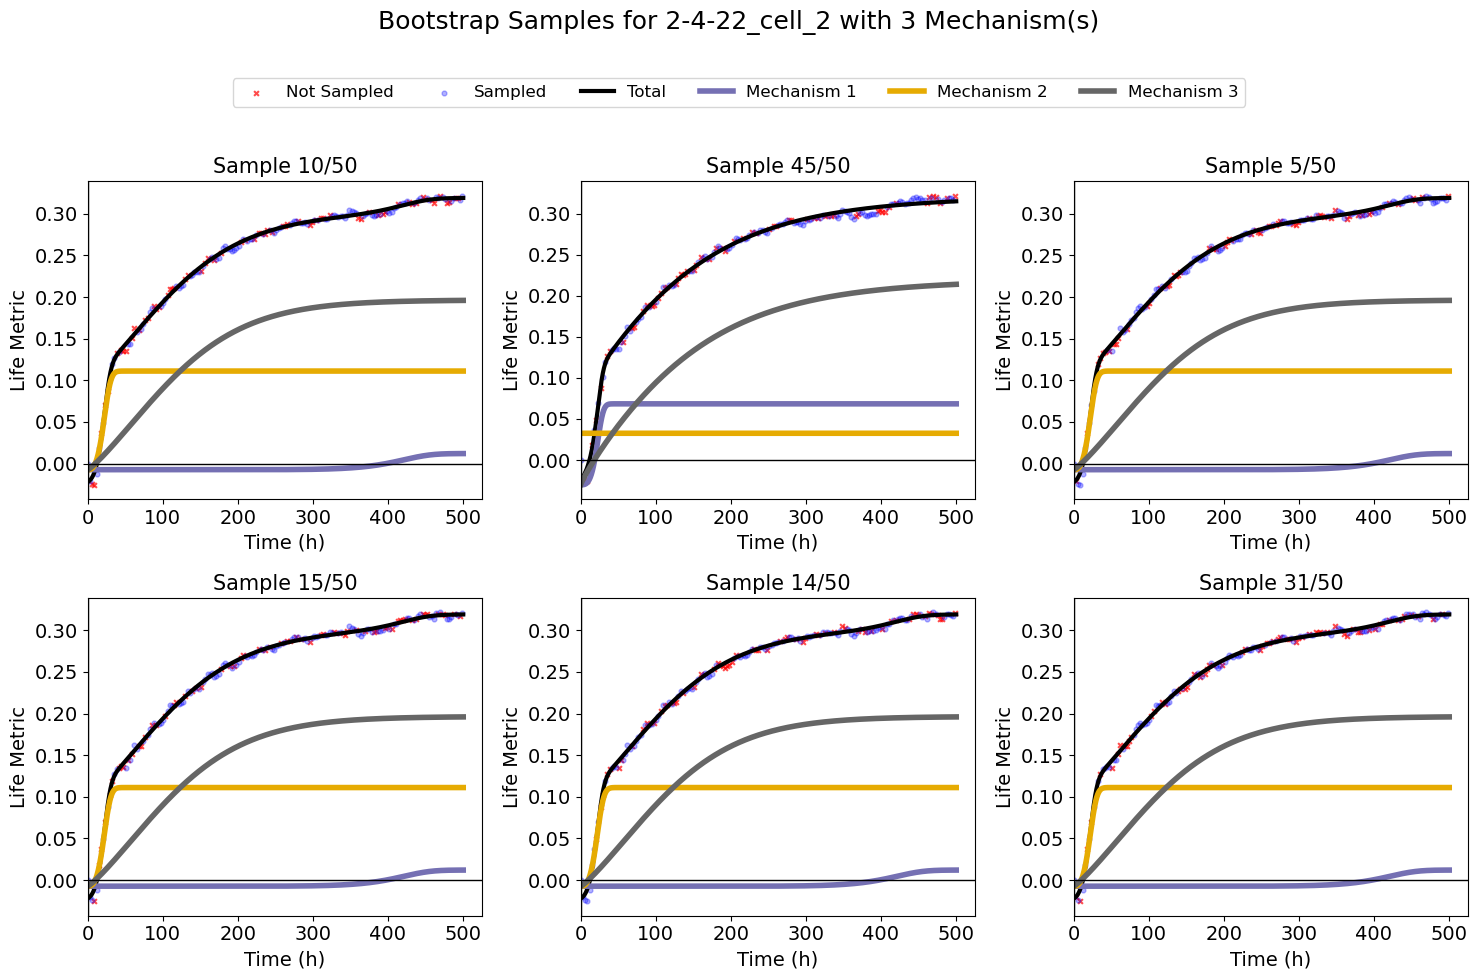

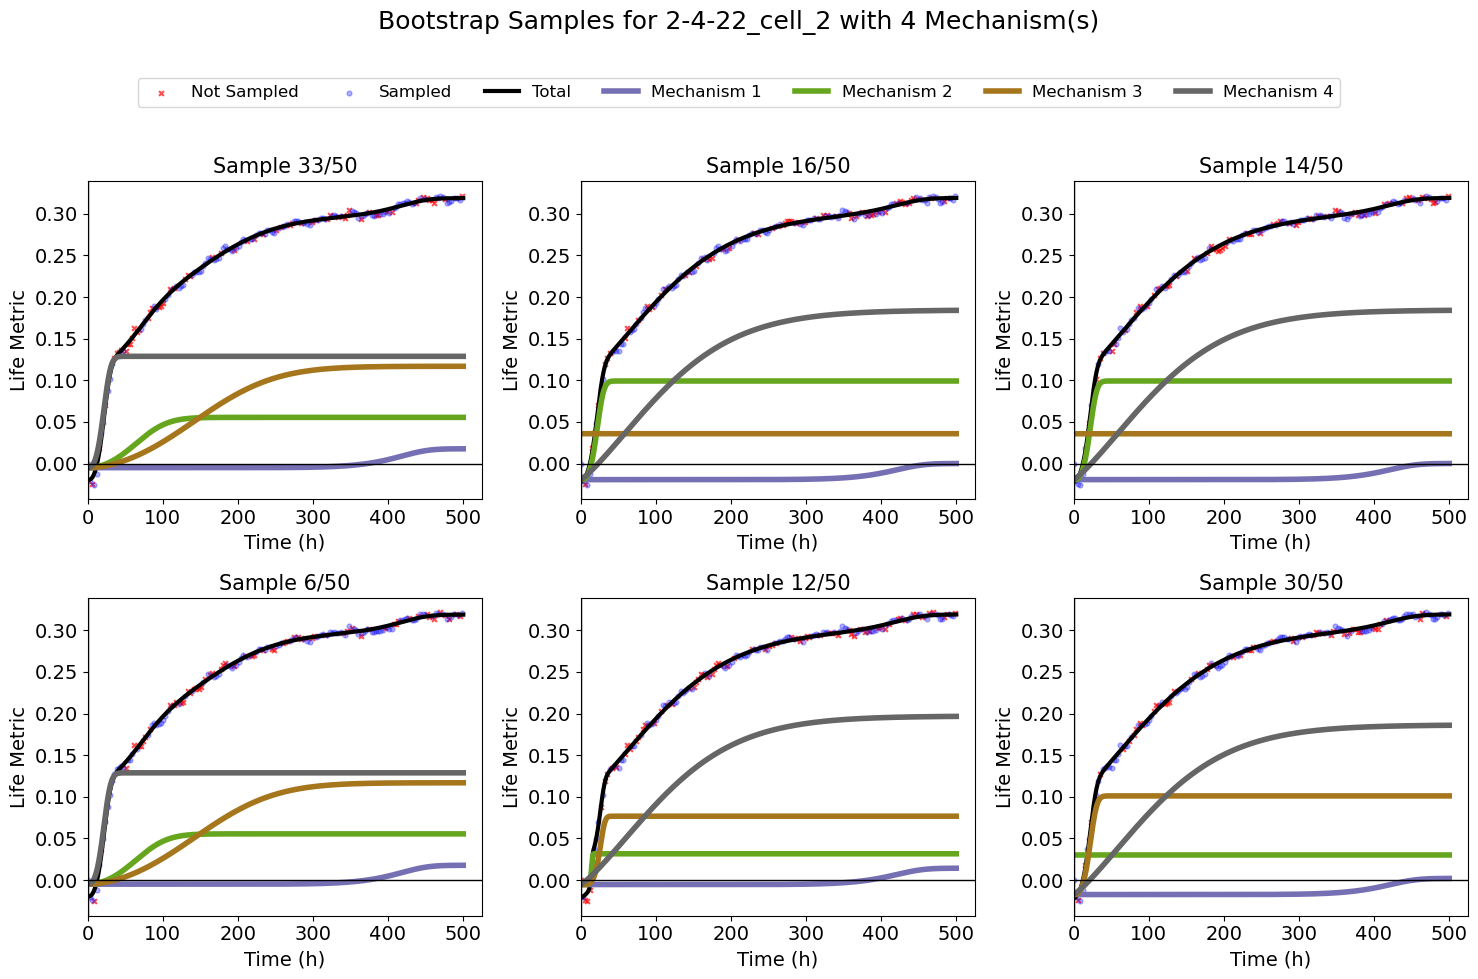

Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0209, 0.0064, 1.25, 0.2938]
Final (Median) R2: 0.9966
Average R2: 0.9966

AICc: -1662, BIC: -1650, cAIC: -1662, DIC: 40.97
Standard Deviation:1.357e-07
Coefficient of Variation:-4.38e-07

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.0142, 0.0269, 1.705, 0.0232, 0.0056, 1.3995, 0.2762]
Final (Median) R2: 0.9983
Average R2: 0.9983

AICc: -1768, BIC: -1747, cAIC: -1768, DIC: 42.36
Standard Deviation:2.099e-05
Coefficient of Variation:2.883e-05

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.0096, 0.0038, 4.0273, 0.0205, 0.0052, 2.3402, 0.0702, 0.0063, 1.3119, 0.2632]
Final (Median) R2: 0.8237
Average R2: 0.9984

AICc: -1012, BIC: -982.2, cAIC: -956.1, DIC: 18.91
Standard Deviation:0.4988
Coefficient of Variation:0.5491

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.0081, 0.011, 9.77, 0.0135, 0.0043, 3.3154, 0.0769, 0.014, 1.7946, 0.0875, 0.0054, 1.3995, 0.1487]
Final (Median) R2: 0.9049
A

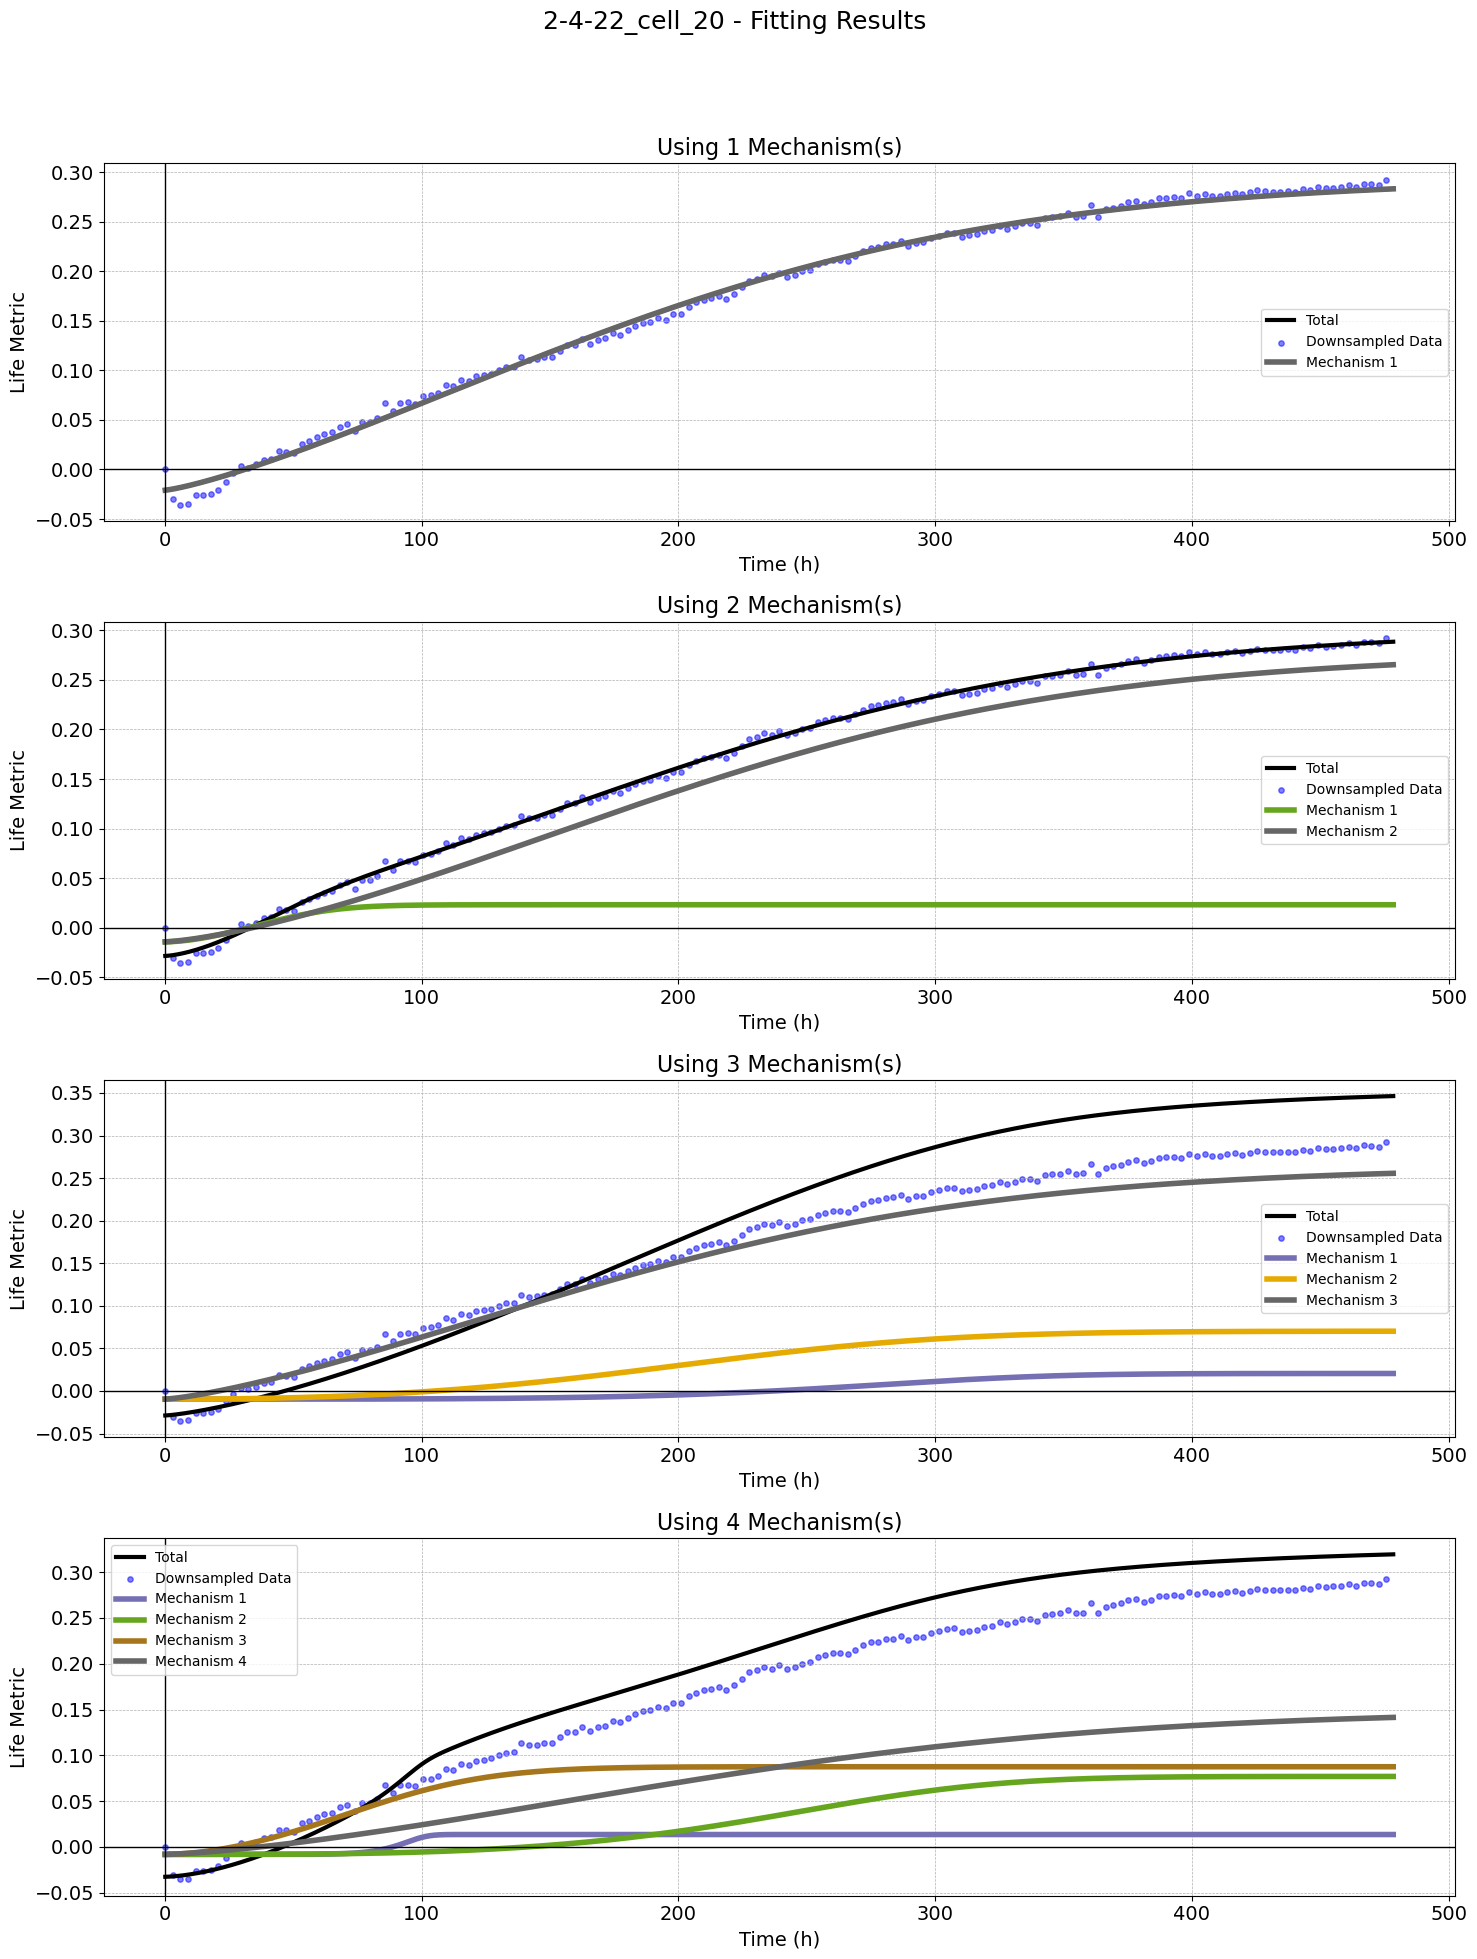

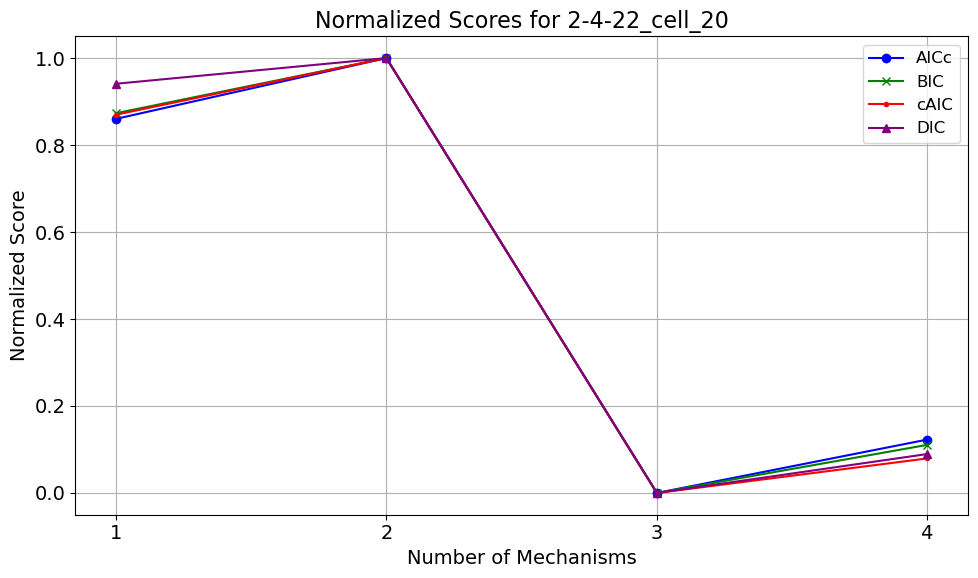

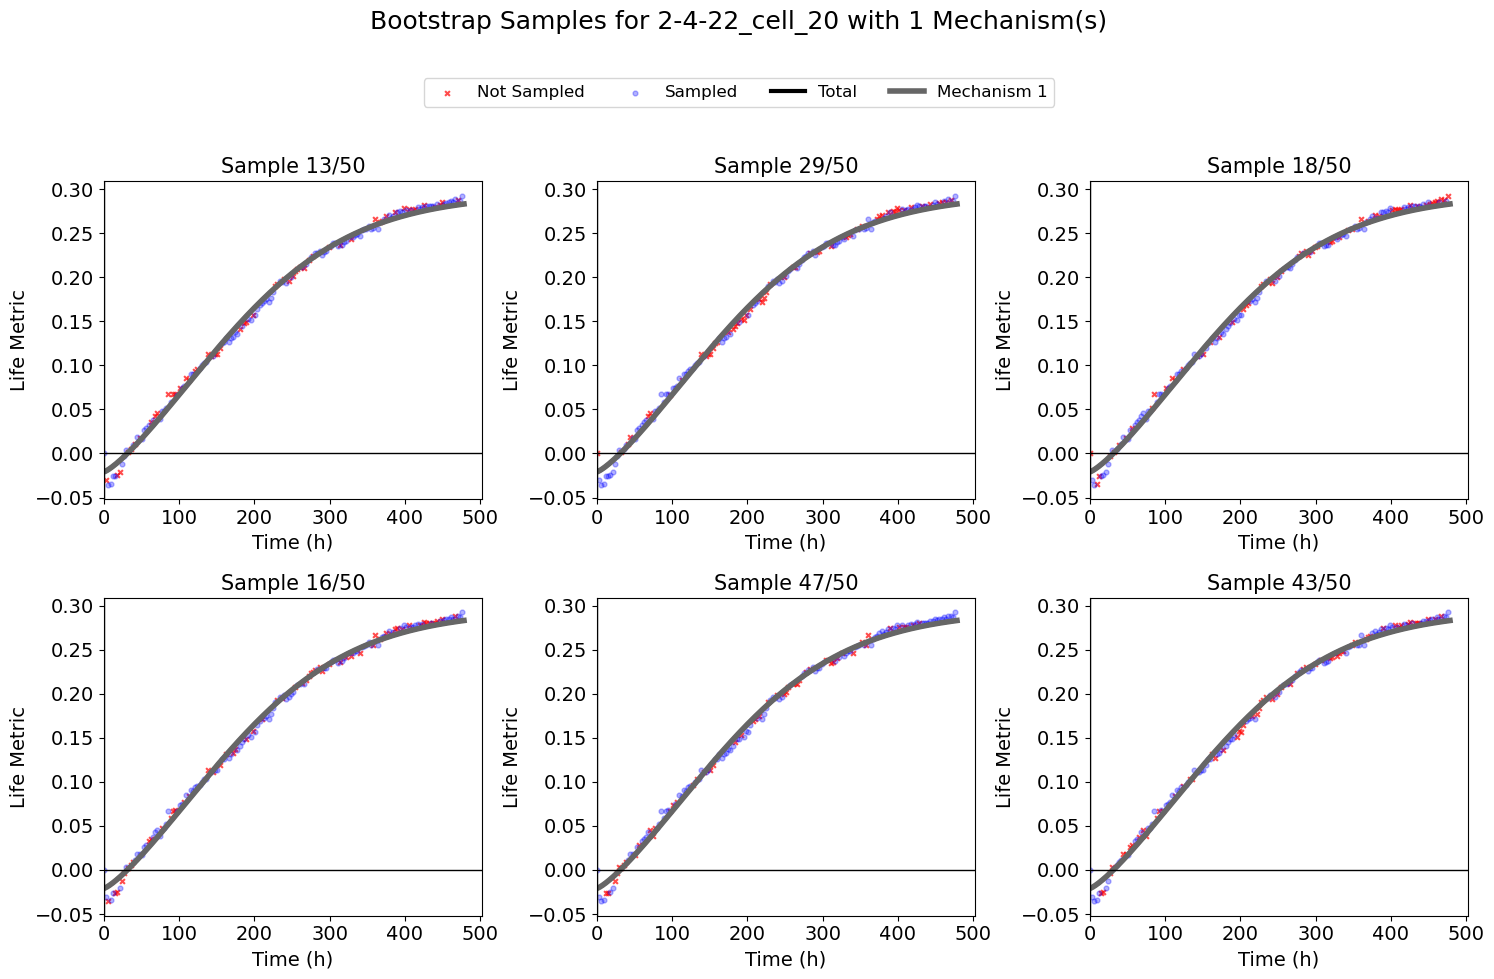

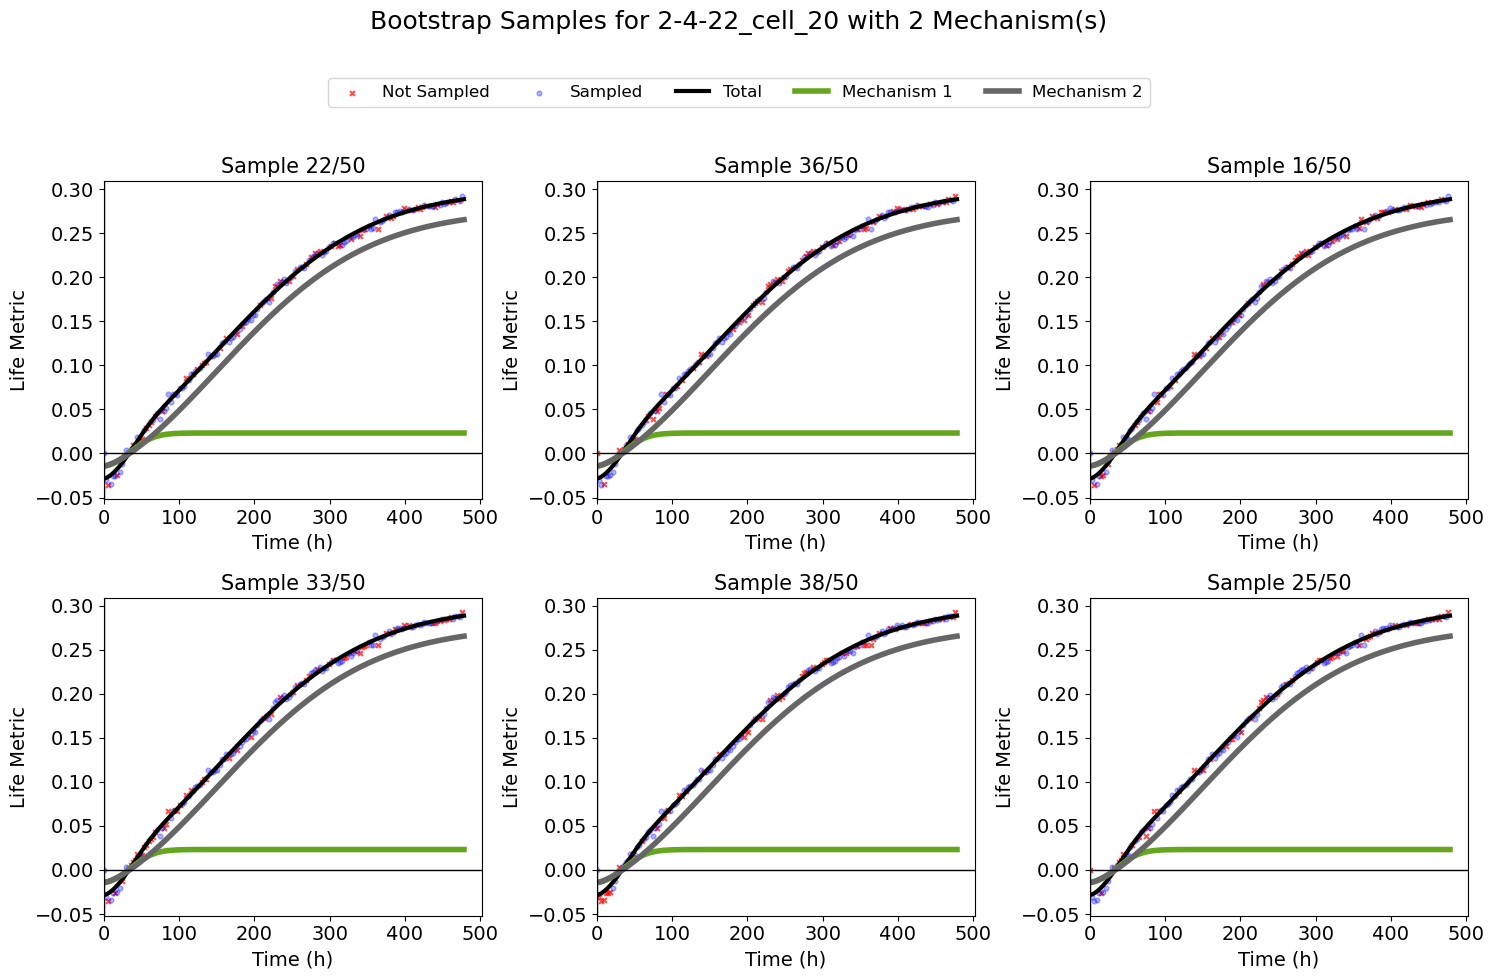

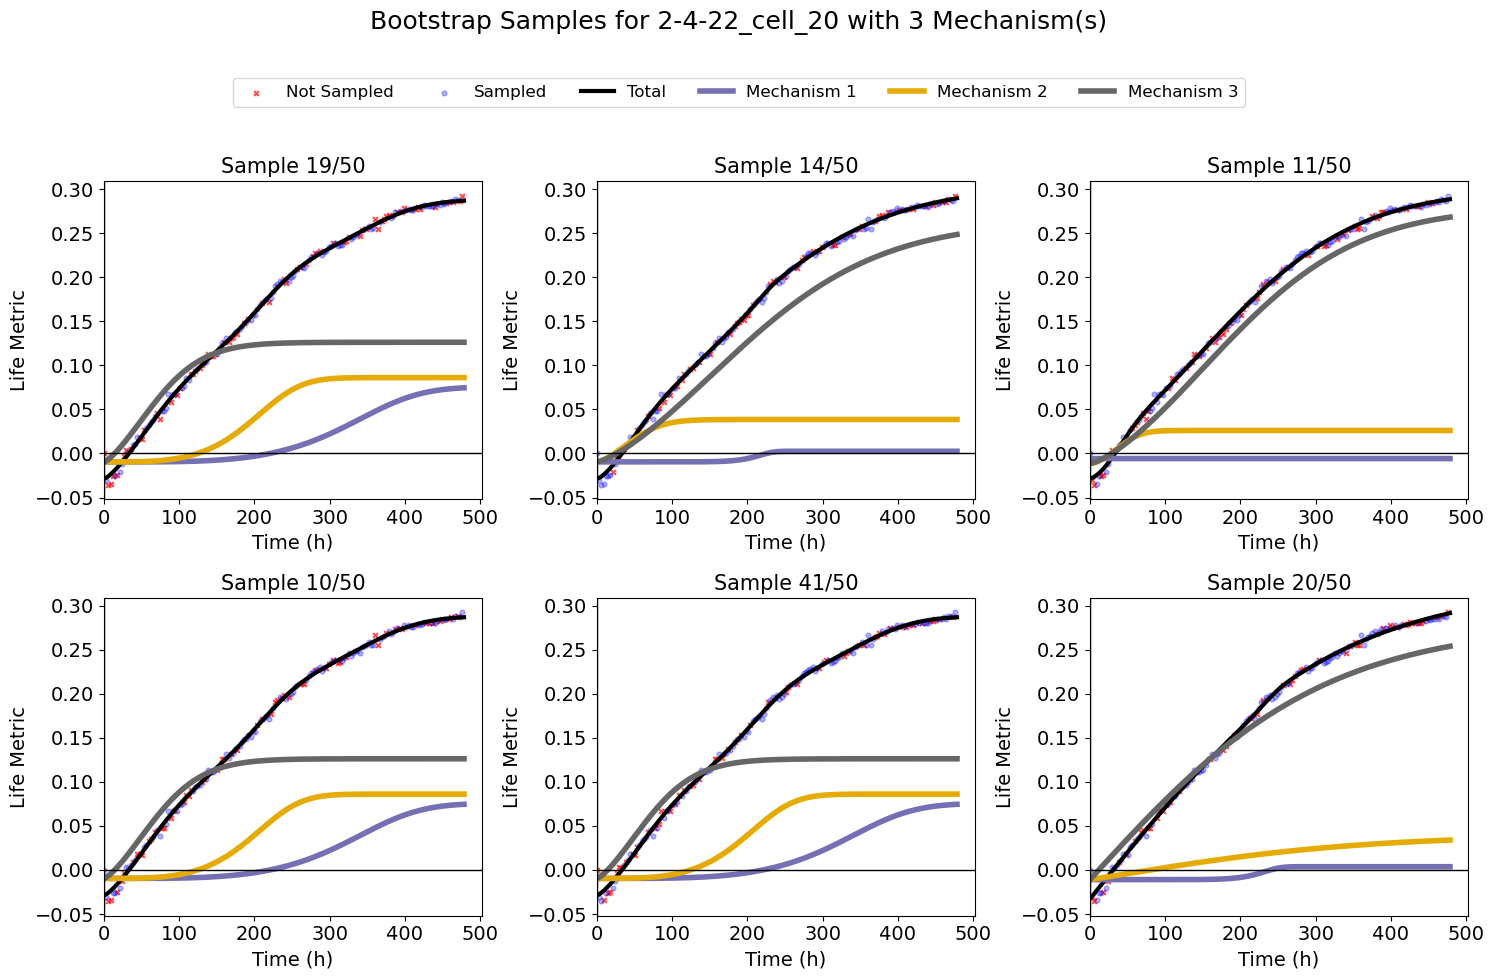

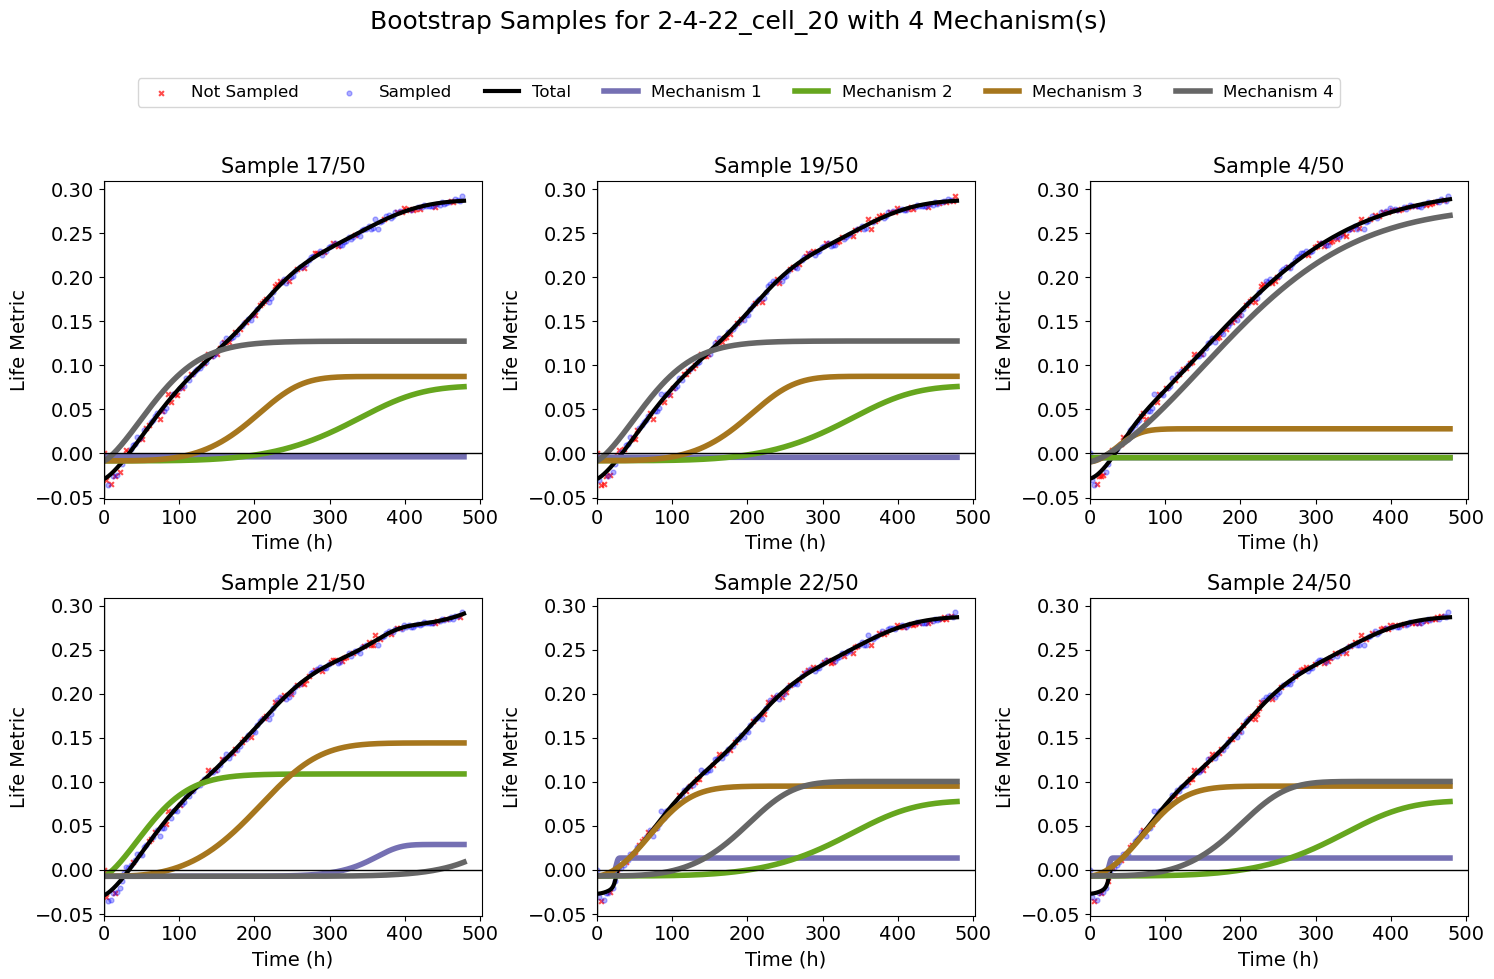

Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0203, 0.0061, 1.2553, 0.3553]
Final (Median) R2: 0.9981
Average R2: 0.9981

AICc: -1702, BIC: -1690, cAIC: -1702, DIC: 41.46
Standard Deviation:2.327e-08
Coefficient of Variation:-1.315e-07

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.0114, 0.0181, 2.2904, 0.0128, 0.0055, 1.2894, 0.3553]
Final (Median) R2: 0.9989
Average R2: 0.9989

AICc: -1792, BIC: -1771, cAIC: -1730, DIC: 42.66
Standard Deviation:0.03038
Coefficient of Variation:0.348

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.0075, 0.0056, 4.3269, 0.0374, 0.0164, 1.6172, 0.081, 0.0042, 1.3107, 0.2566]
Final (Median) R2: 0.9929
Average R2: 0.9990

AICc: -1477, BIC: -1448, cAIC: -1392, DIC: 31.45
Standard Deviation:0.4176
Coefficient of Variation:0.5805

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.0064, 0.0056, 4.3278, 0.0155, 0.0164, 1.6517, 0.0613, 0.006, 1.6172, 0.1045, 0.0042, 1.5773, 0.254]
Final (Median) R2: 0.8920
Aver

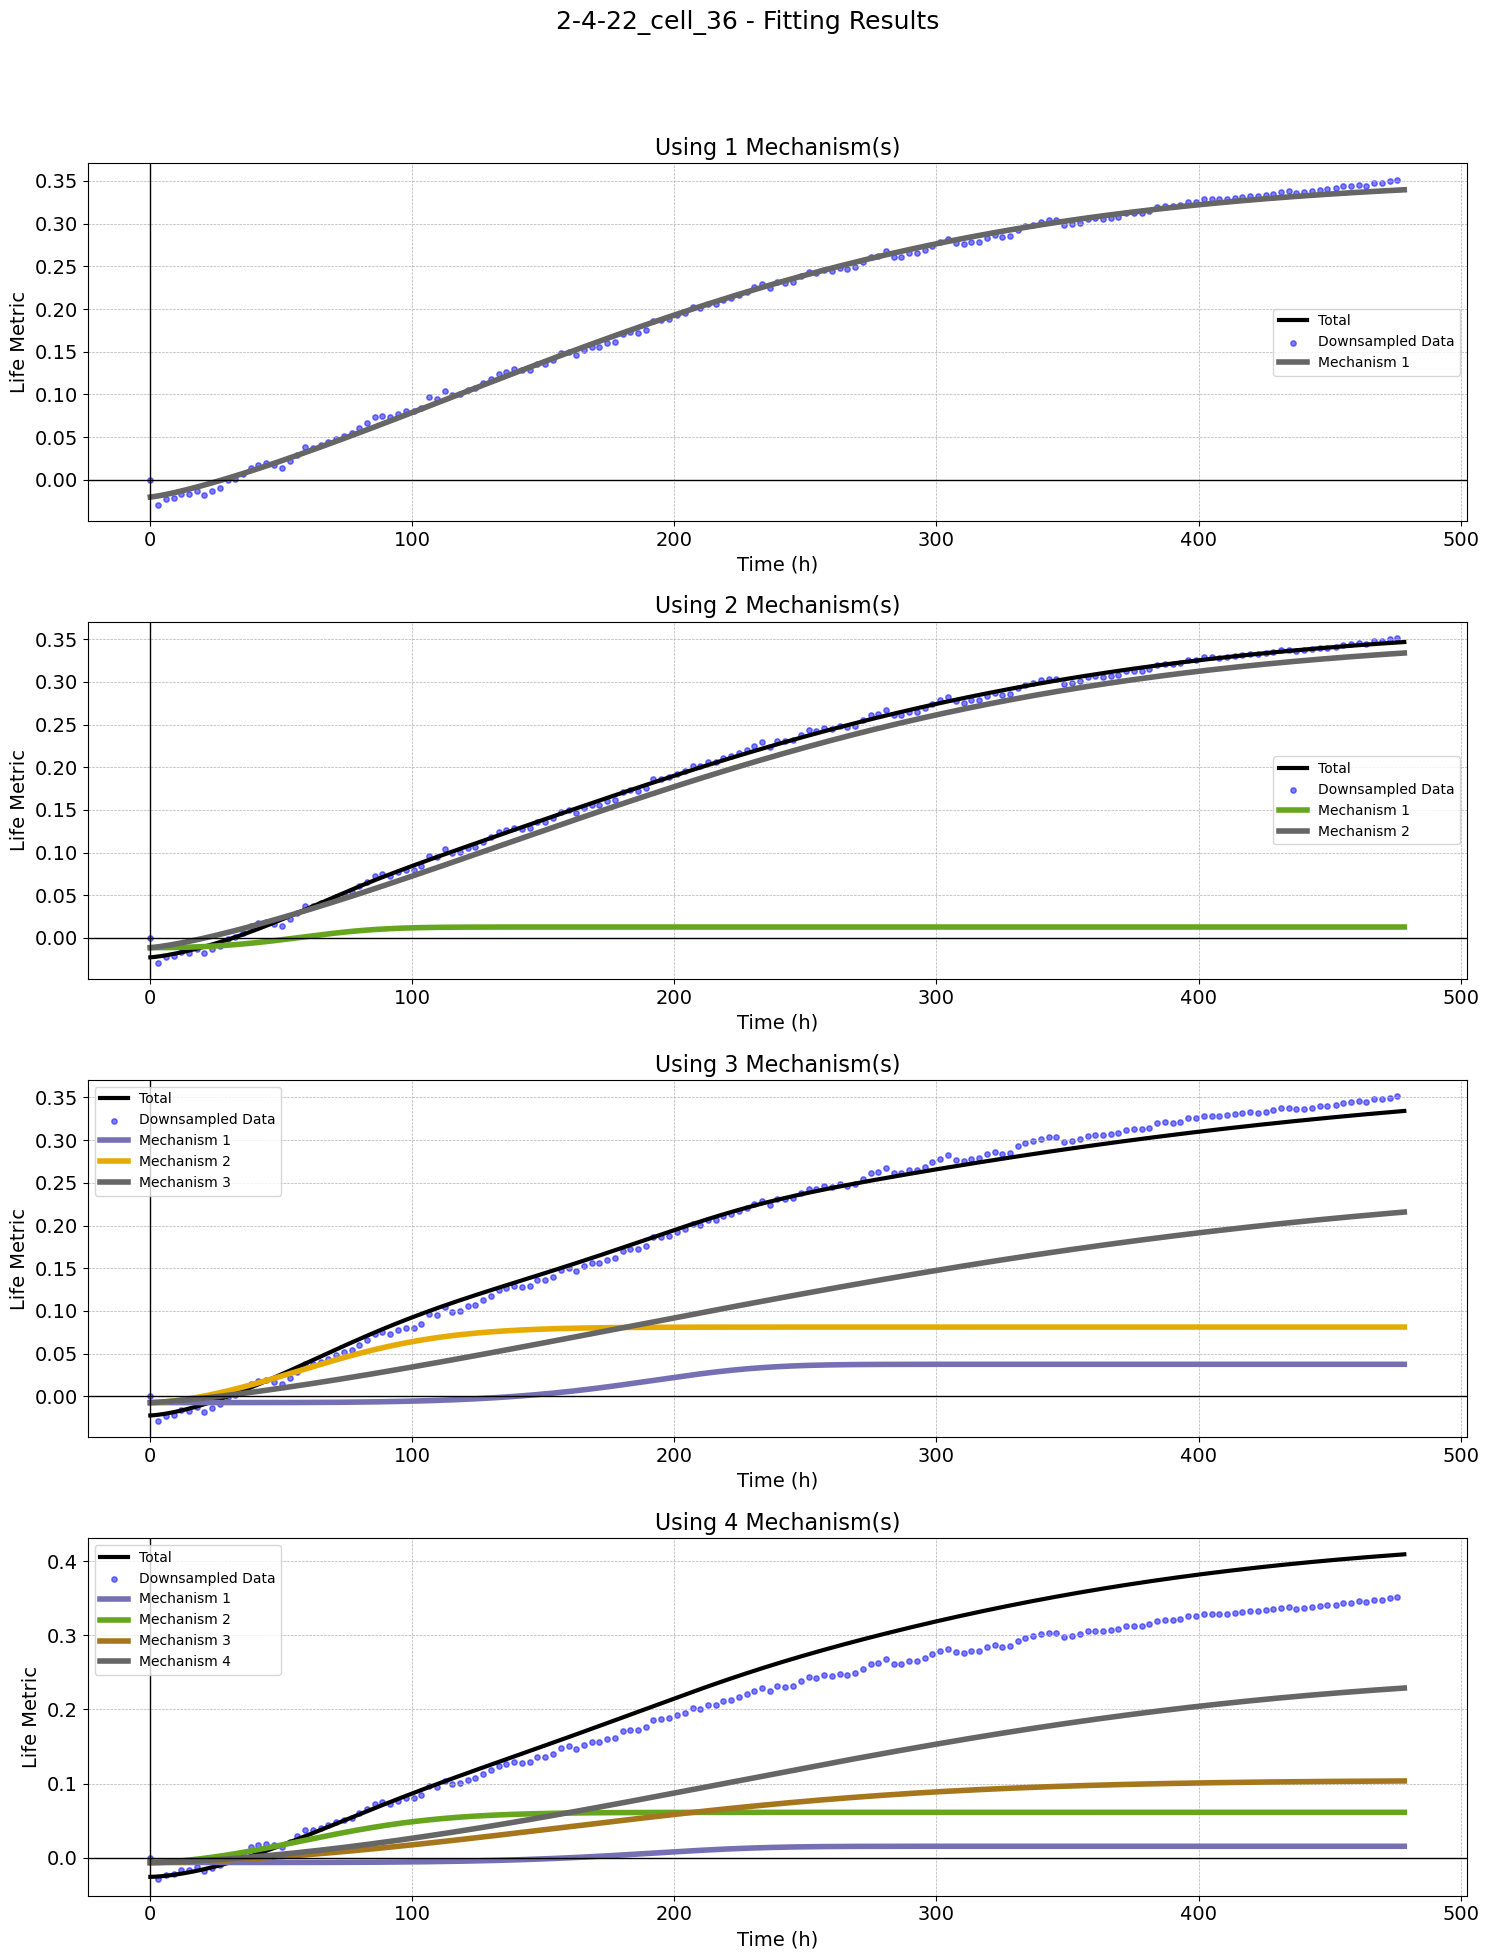

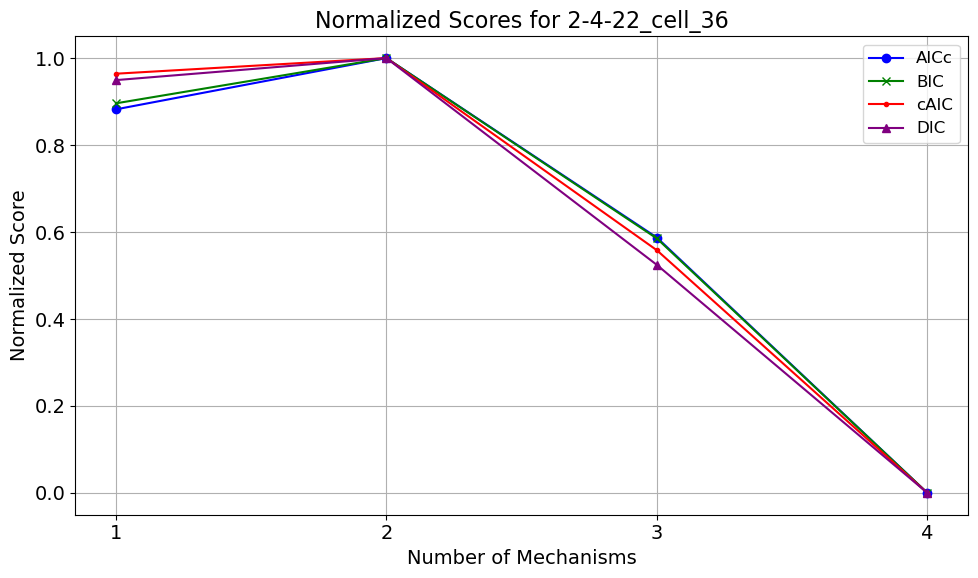

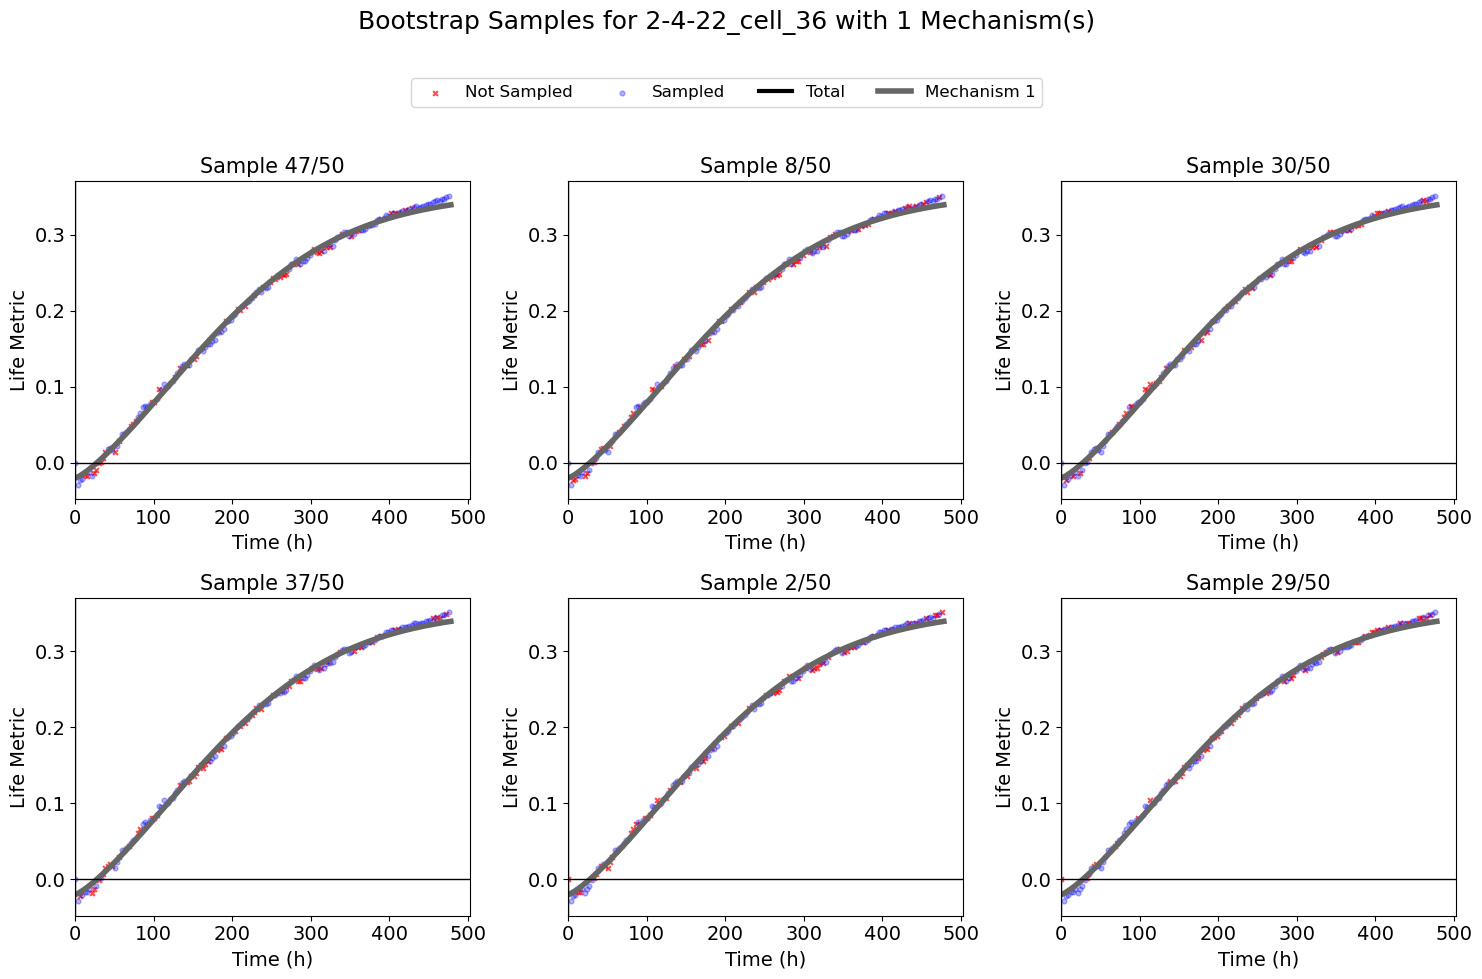

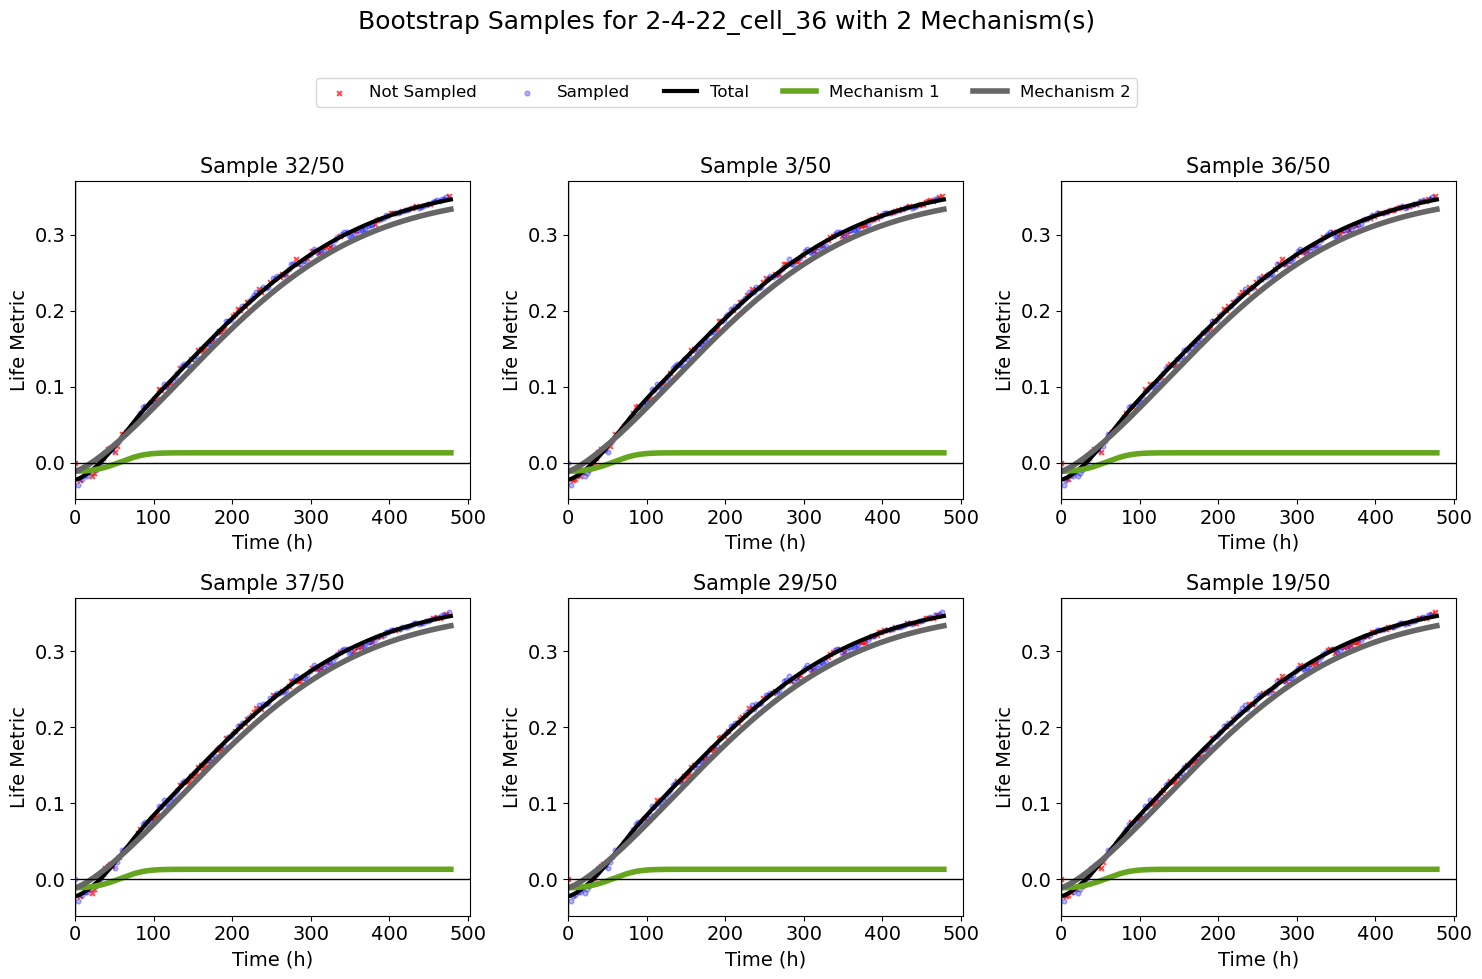

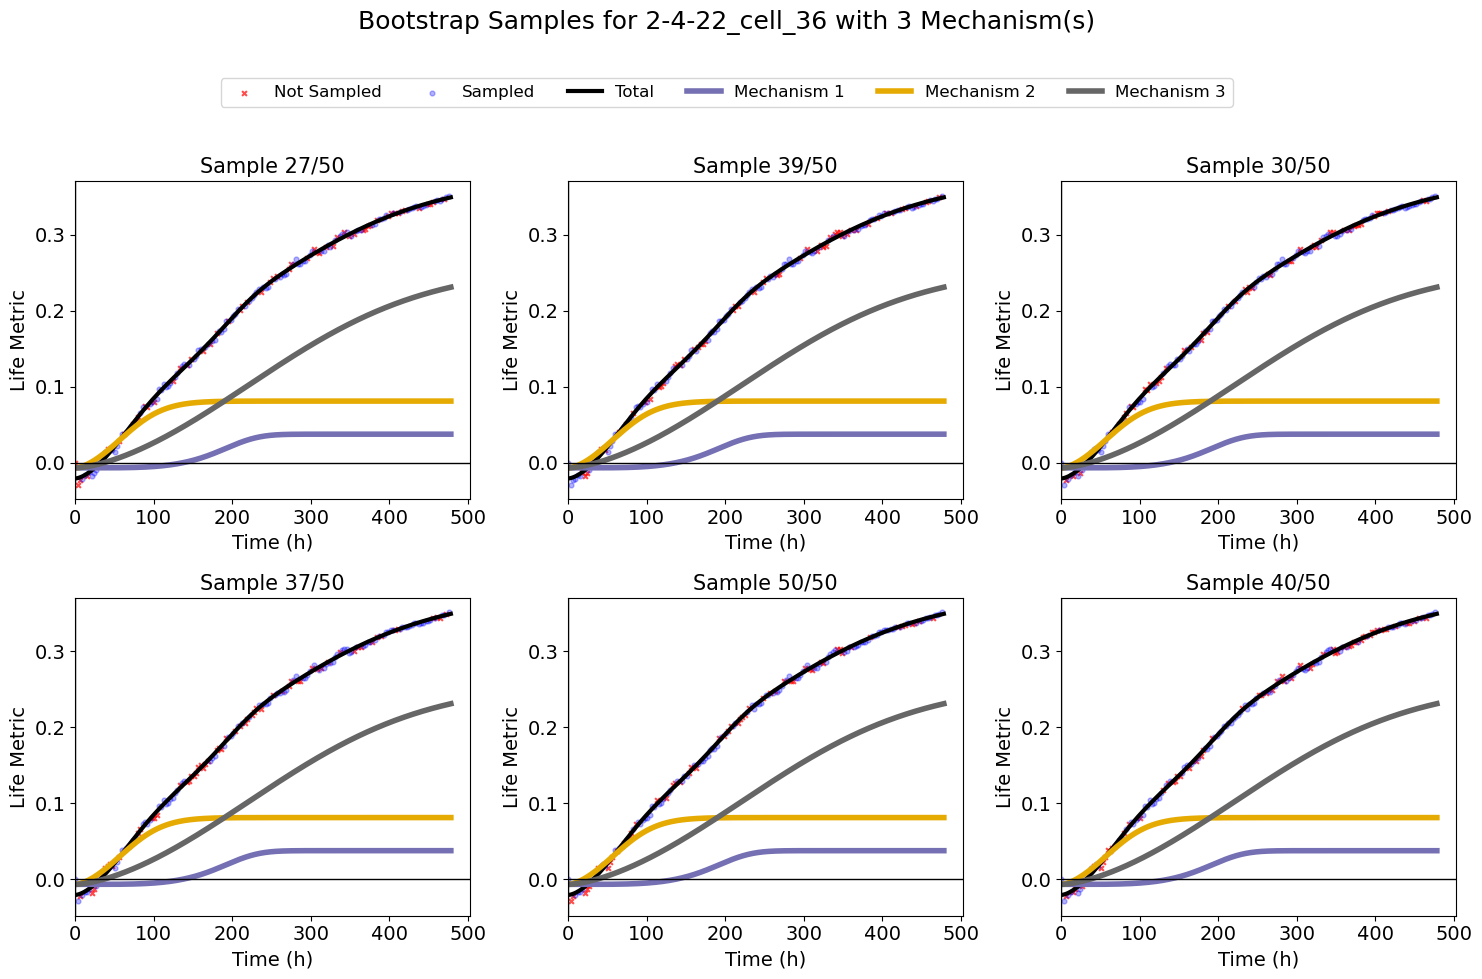

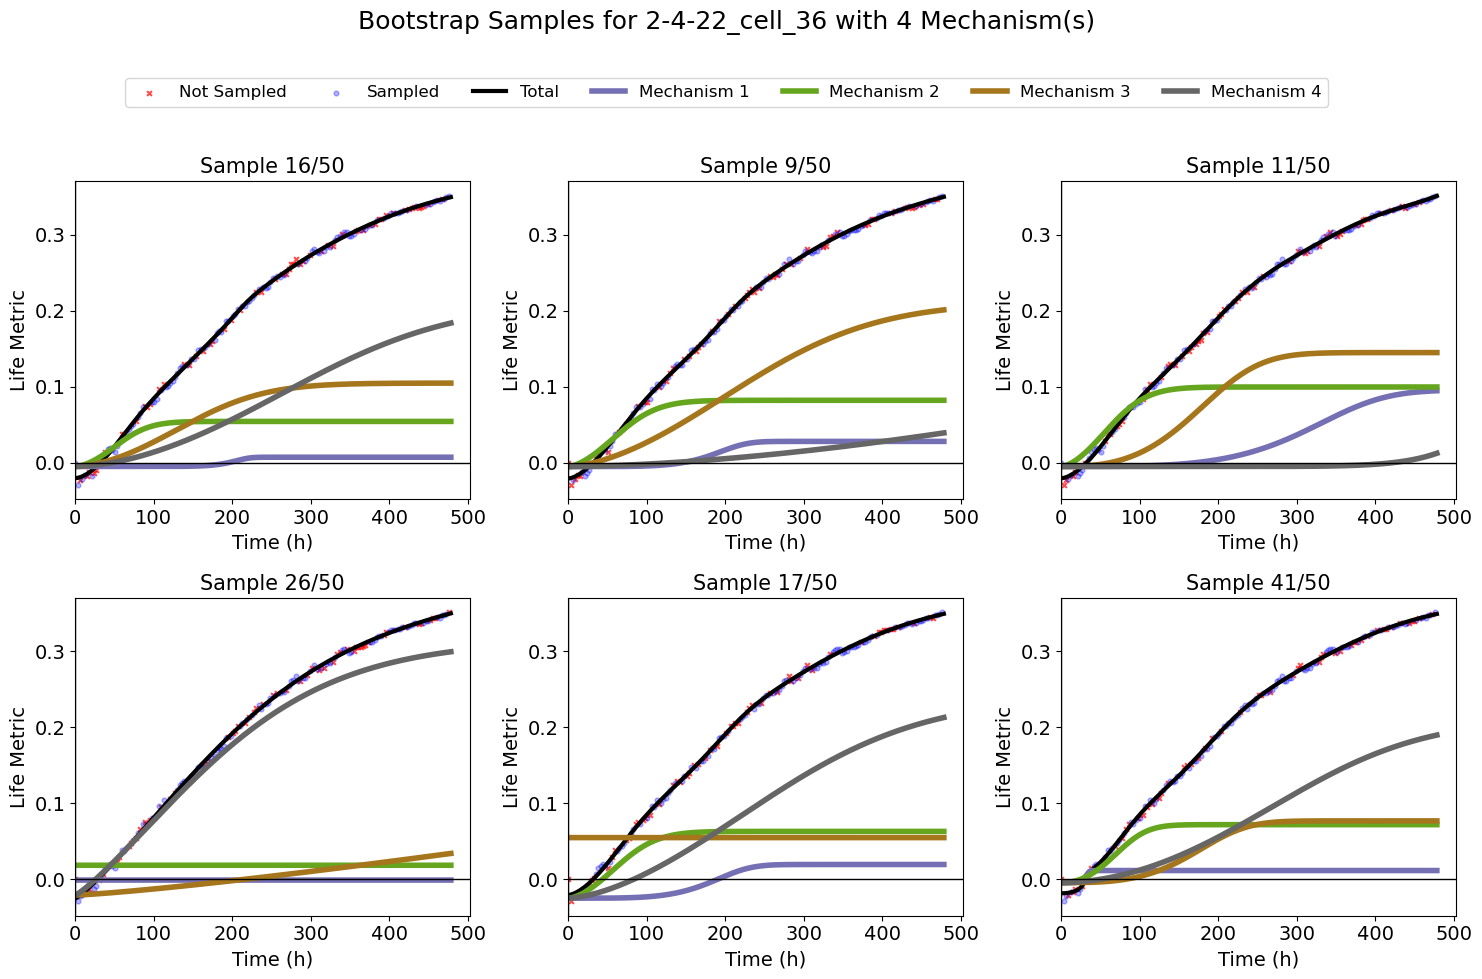

Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0085, 0.0077, 0.9687, 0.5812]
Final (Median) R2: 0.9876
Average R2: 0.9876

AICc: -669.7, BIC: -660.8, cAIC: -669.7, DIC: 34.65
Standard Deviation:8.94e-08
Coefficient of Variation:-1.464e-06

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.008, 0.0112, 0.9502, 0.4415, 0.0038, 10.0, 0.5812]
Final (Median) R2: 0.9941
Average R2: 0.9941

AICc: -721.2, BIC: -706.2, cAIC: -721.2, DIC: 36.13
Standard Deviation:2e-07
Coefficient of Variation:3.335e-07

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.0026, 0.0371, 1.4201, 0.1176, 0.0044, 10.0, 0.2108, 0.0096, 2.1208, 0.2212]
Final (Median) R2: 0.9948
Average R2: 0.9947

AICc: -722.9, BIC: -702.4, cAIC: -704.2, DIC: 36.4
Standard Deviation:0.4628
Coefficient of Variation:0.2581

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.002, 0.0193, 1.4201, 0.0481, 0.0131, 1.6747, 0.1149, 0.0044, 10.0, 0.2123, 0.0096, 2.1208, 0.2386]
Final (Median) R2: 0.8695


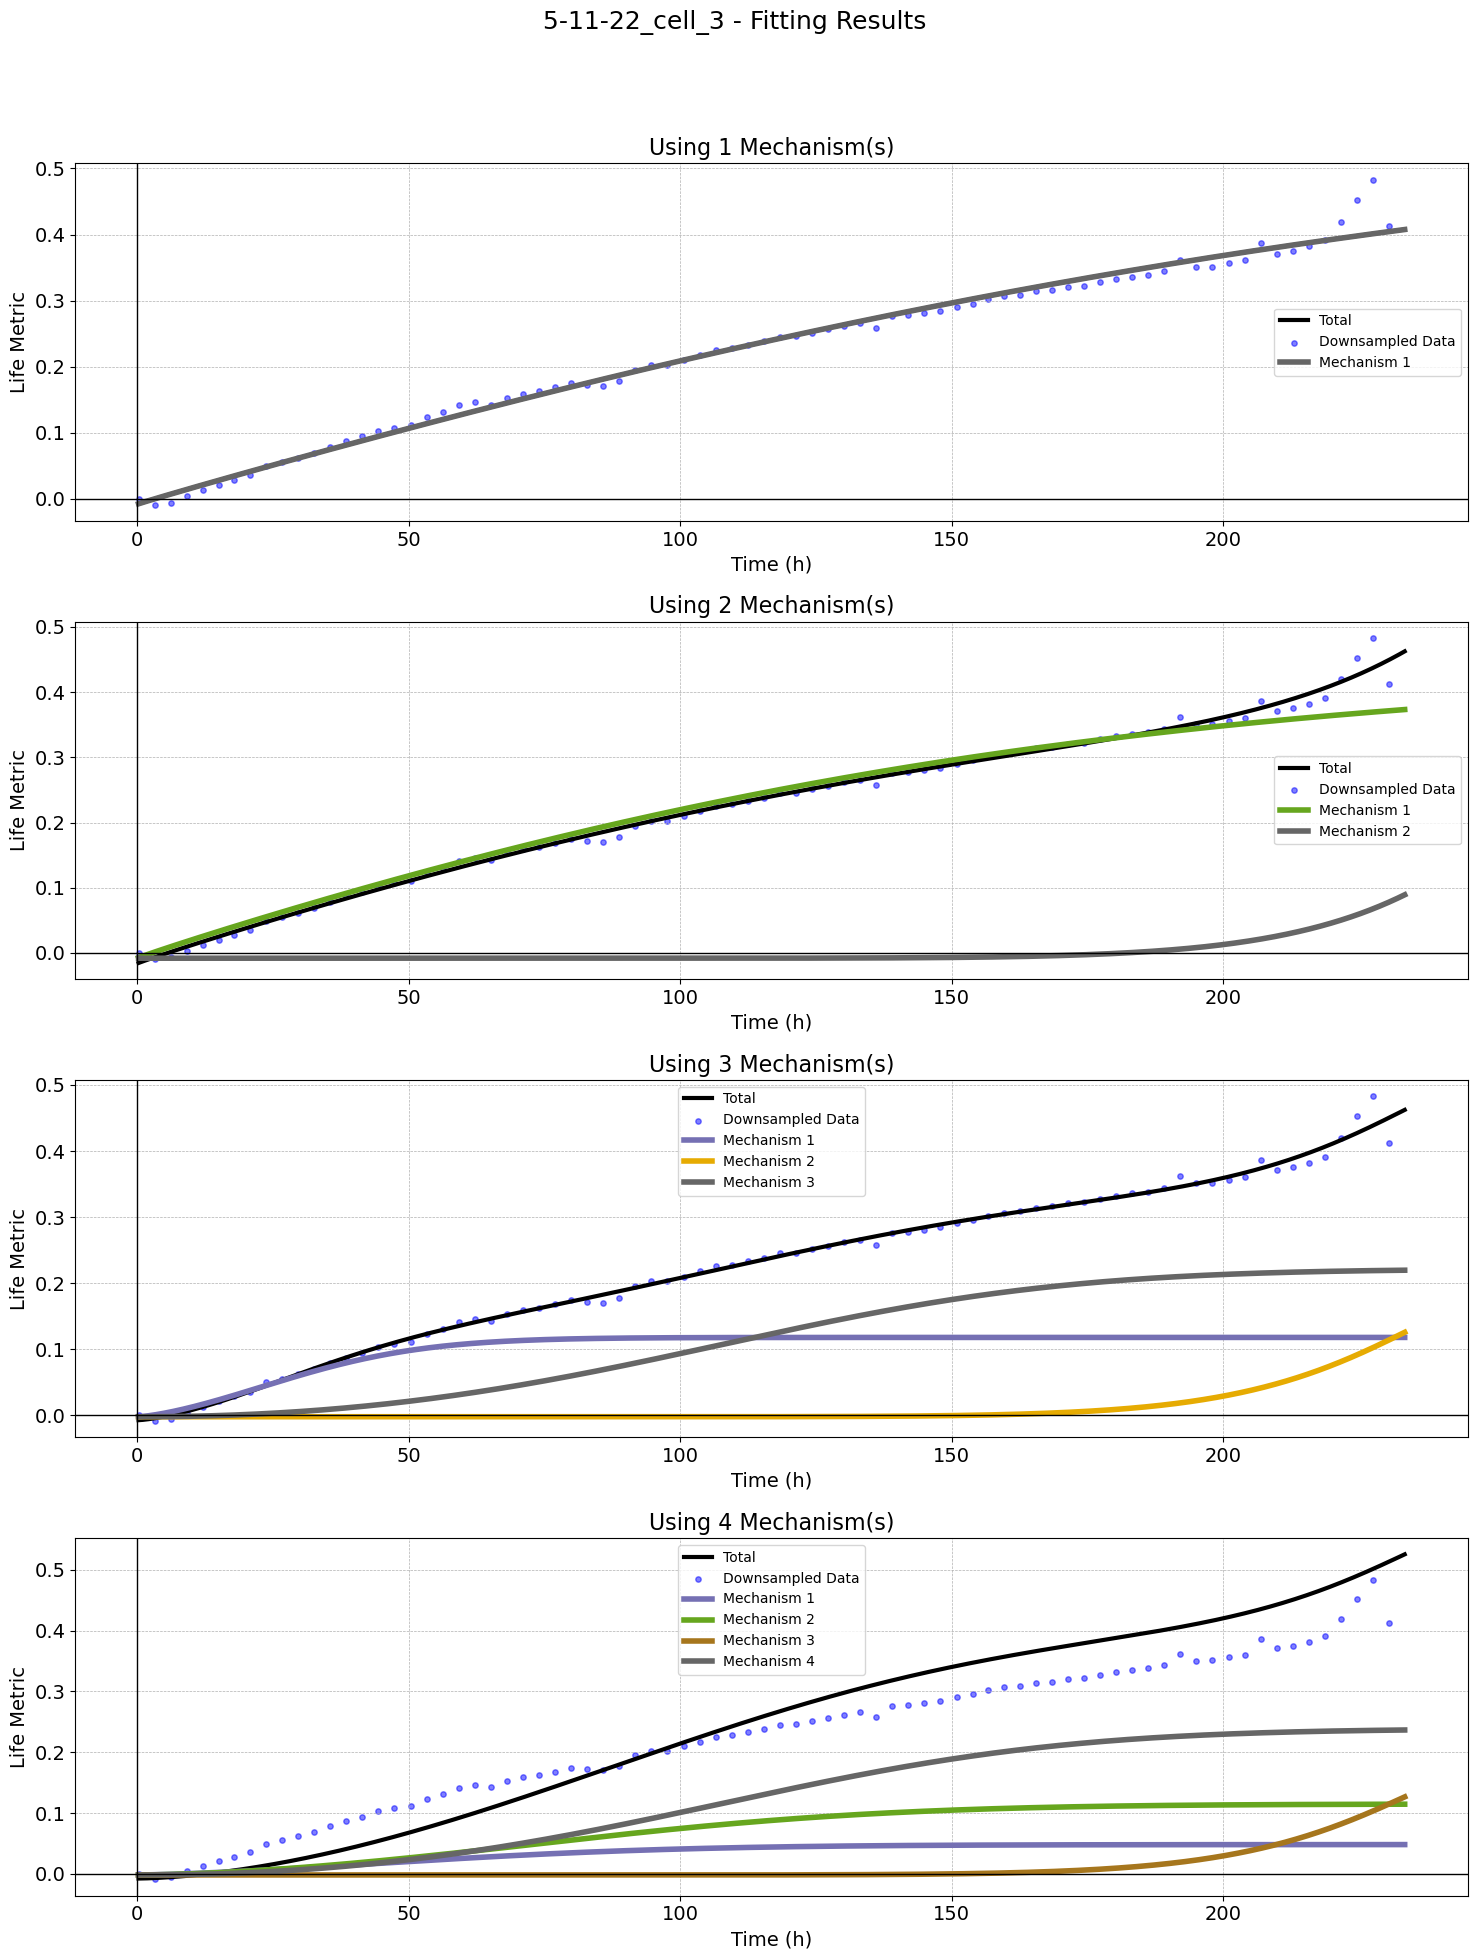

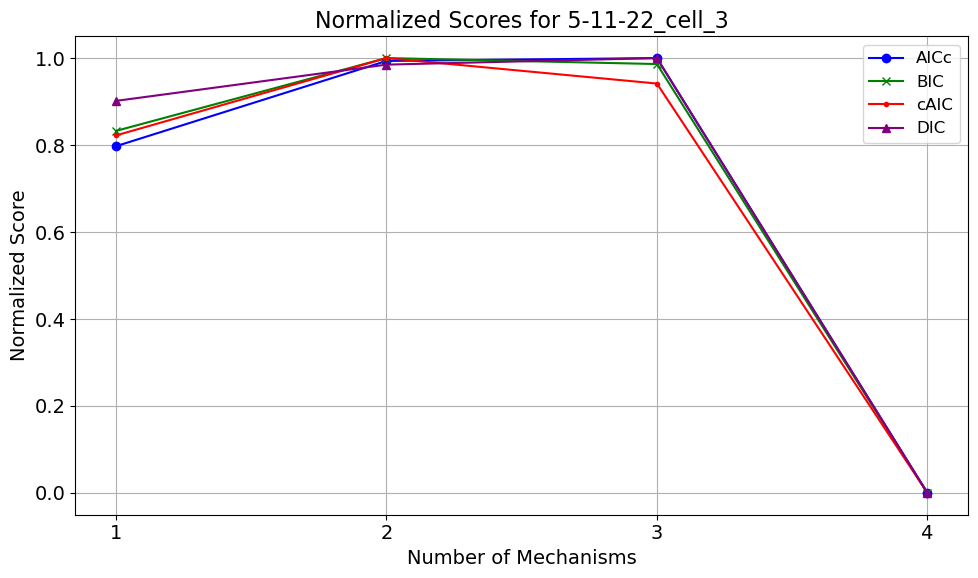

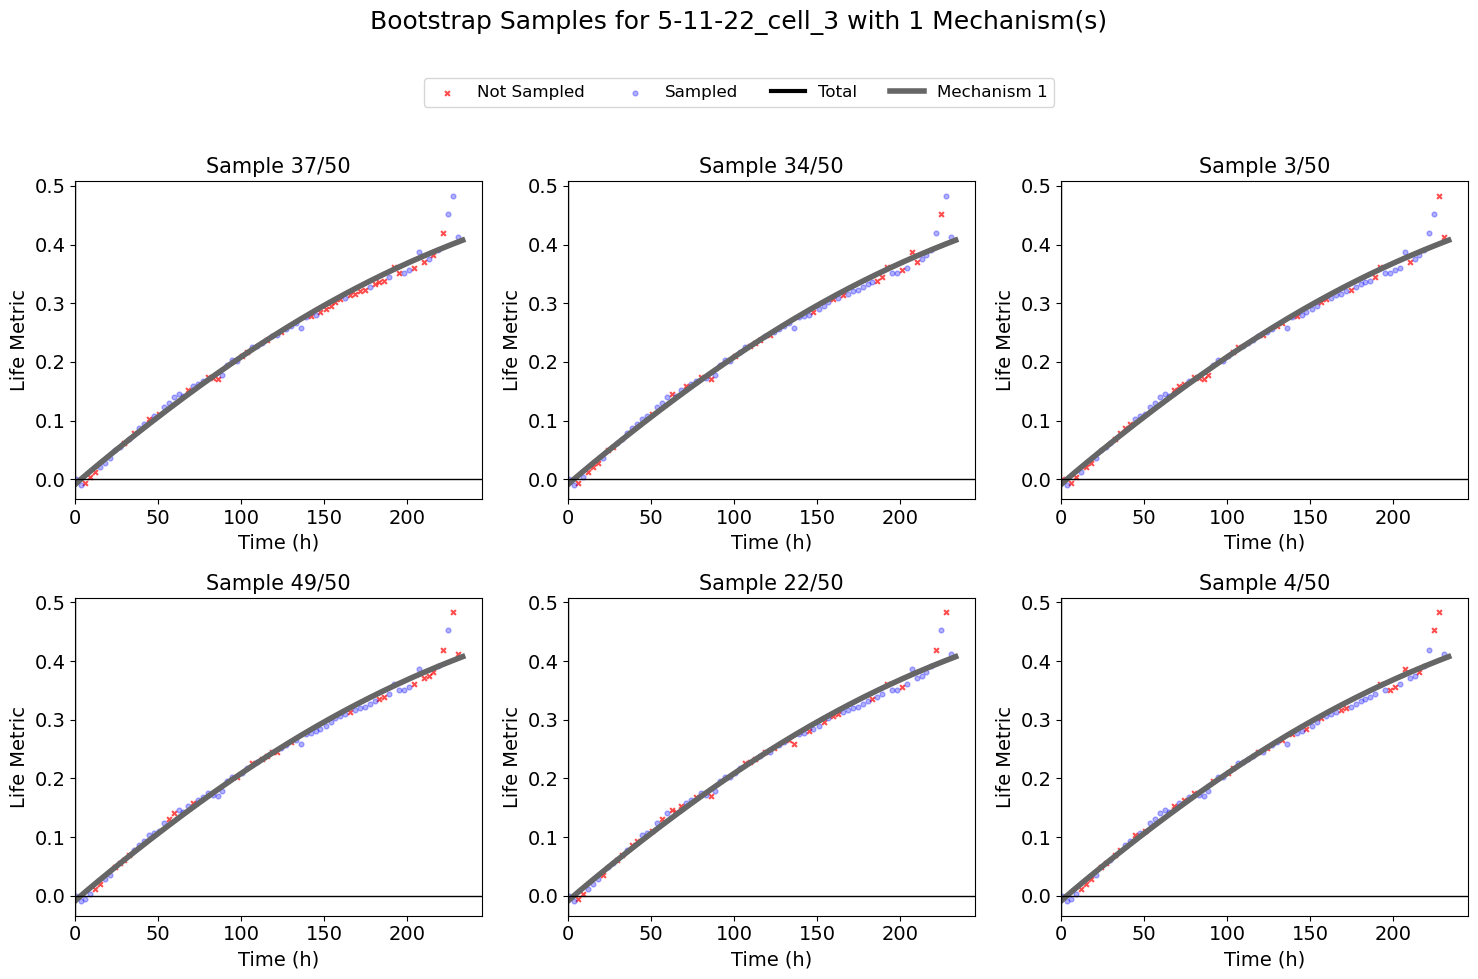

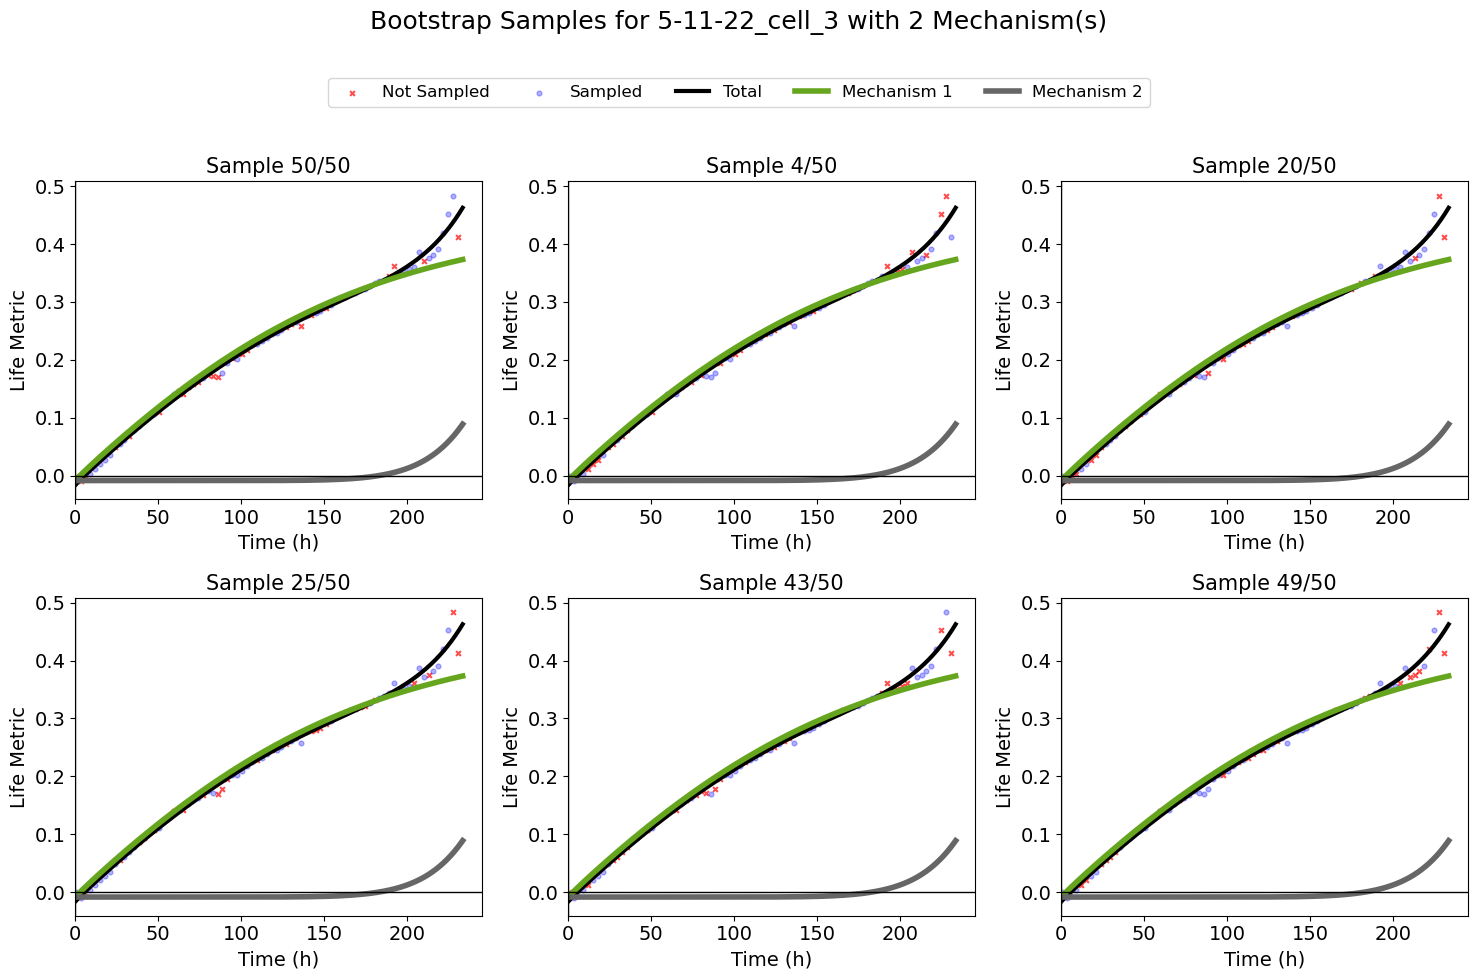

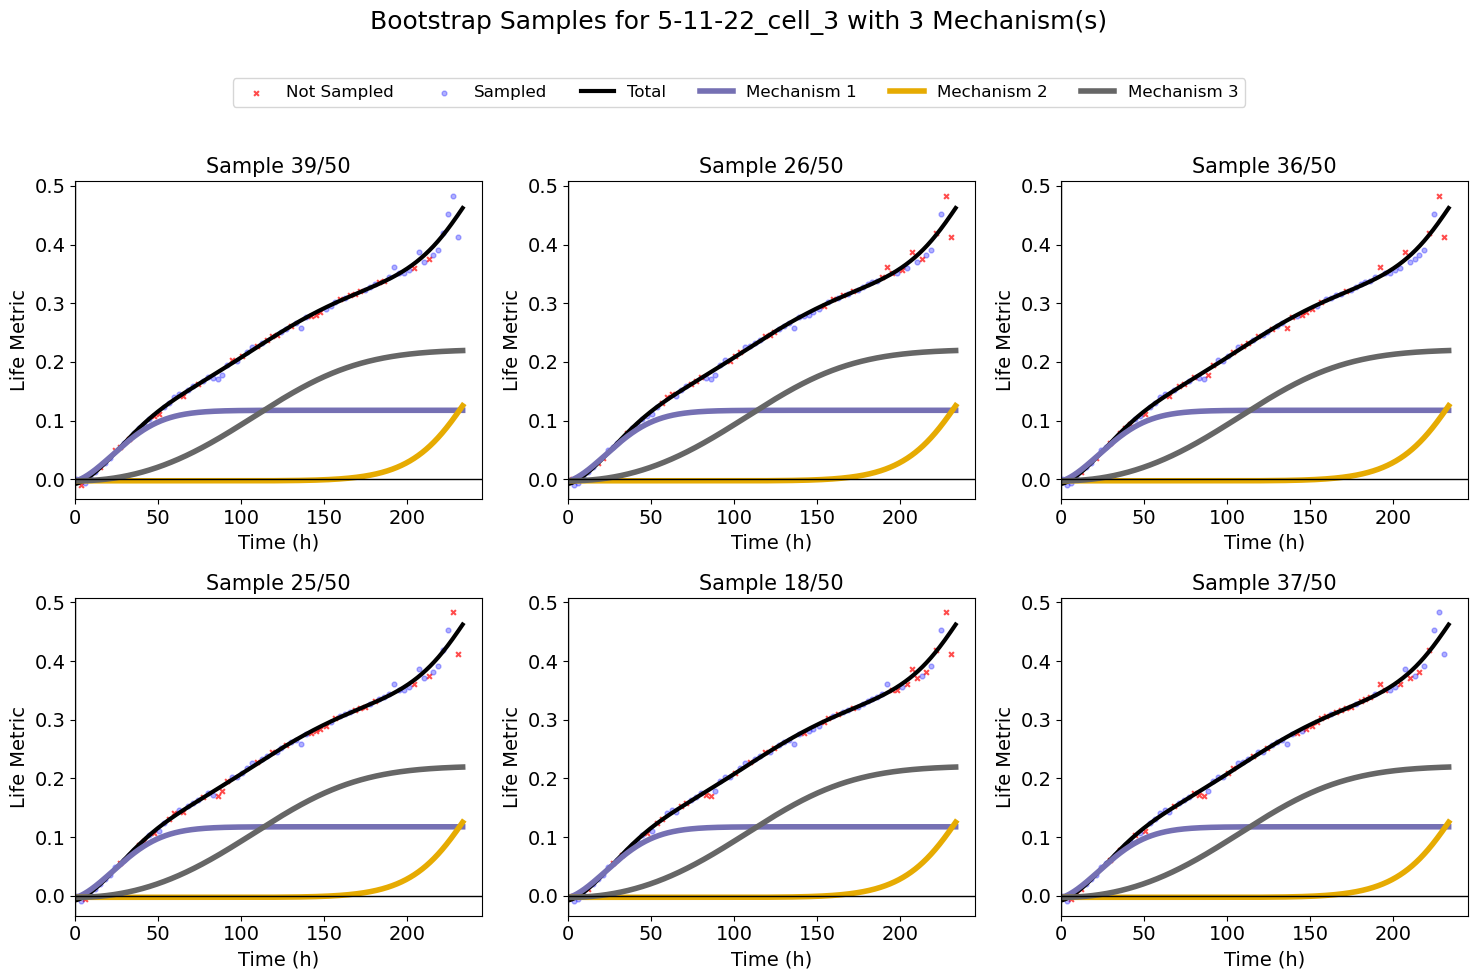

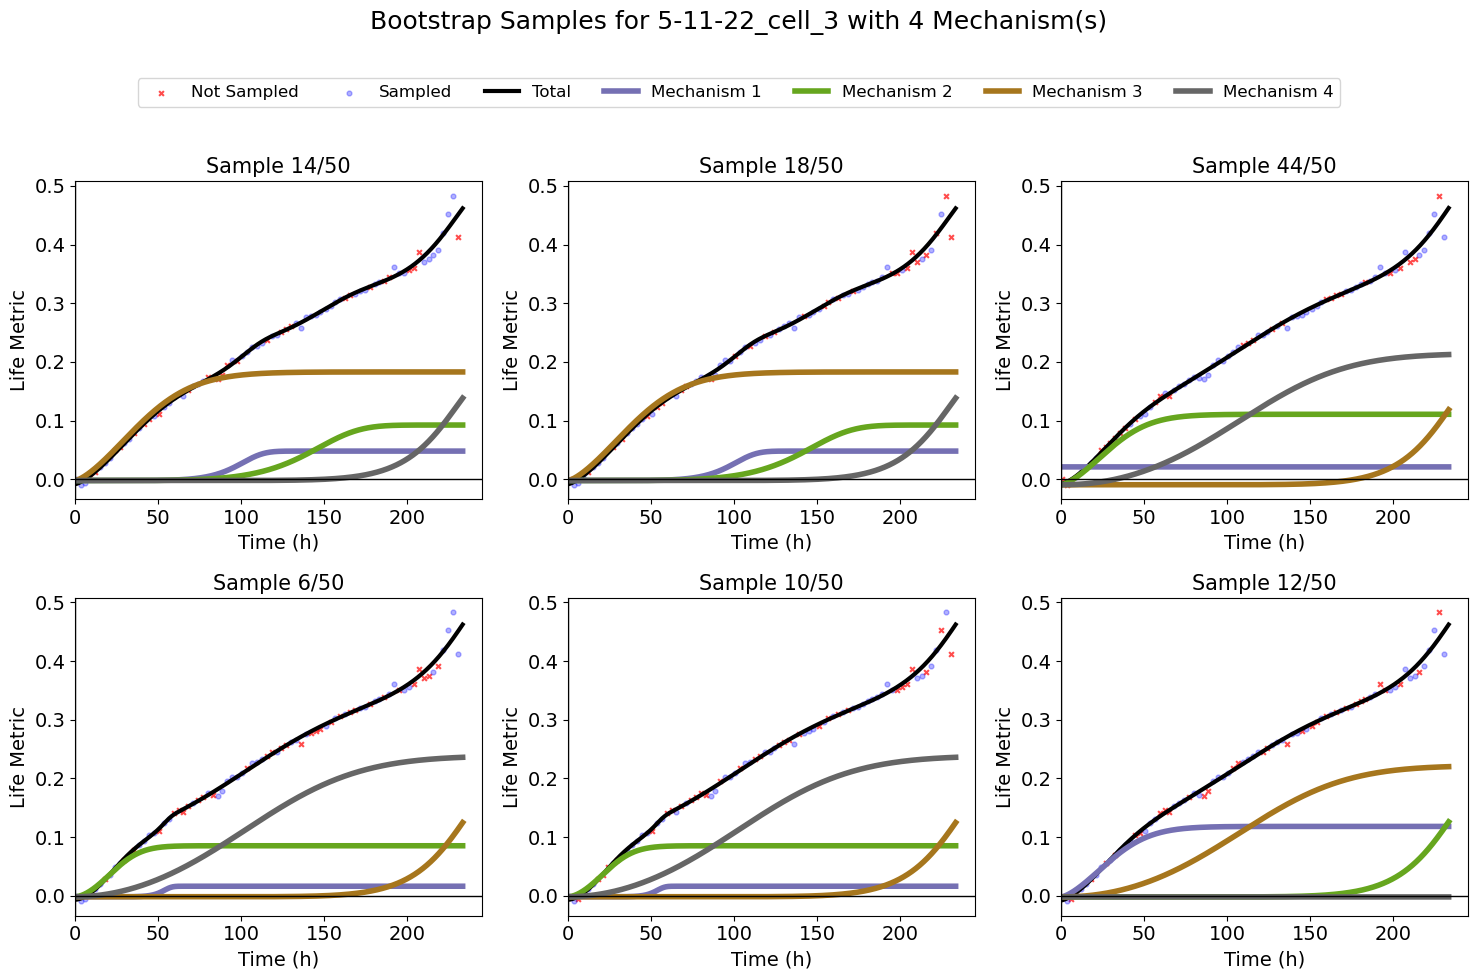

Trying with 1 mechanisms...

Final (Median) Parameters: [-0.0093, 0.0055, 0.9878, 0.5639]
Final (Median) R2: 0.9972
Average R2: 0.9972

AICc: -2421, BIC: -2407, cAIC: -2421, DIC: 41.46
Standard Deviation:1.532e-09
Coefficient of Variation:2.501e-09

Trying with 2 mechanisms...

Final (Median) Parameters: [-0.0047, 0.007, 1.3427, 0.2514, 0.0017, 0.7943, 0.5639]
Final (Median) R2: 0.9988
Average R2: 0.9989

AICc: -2635, BIC: -2611, cAIC: -2539, DIC: 42.95
Standard Deviation:0.5032
Coefficient of Variation:0.3653

Trying with 3 mechanisms...

Final (Median) Parameters: [-0.0009, 0.0193, 1.4377, 0.0719, 0.0017, 9.8859, 0.0724, 0.0053, 1.4405, 0.4131]
Final (Median) R2: 0.9994
Average R2: 0.9994

AICc: -2812, BIC: -2778, cAIC: -2755, DIC: 44.8
Standard Deviation:0.452
Coefficient of Variation:0.2055

Trying with 4 mechanisms...

Final (Median) Parameters: [-0.001, 0.0023, 7.6786, 0.0375, 0.0017, 10.0, 0.0764, 0.0101, 1.2989, 0.1822, 0.005, 1.8886, 0.4049]
Final (Median) R2: 0.4949
Average R

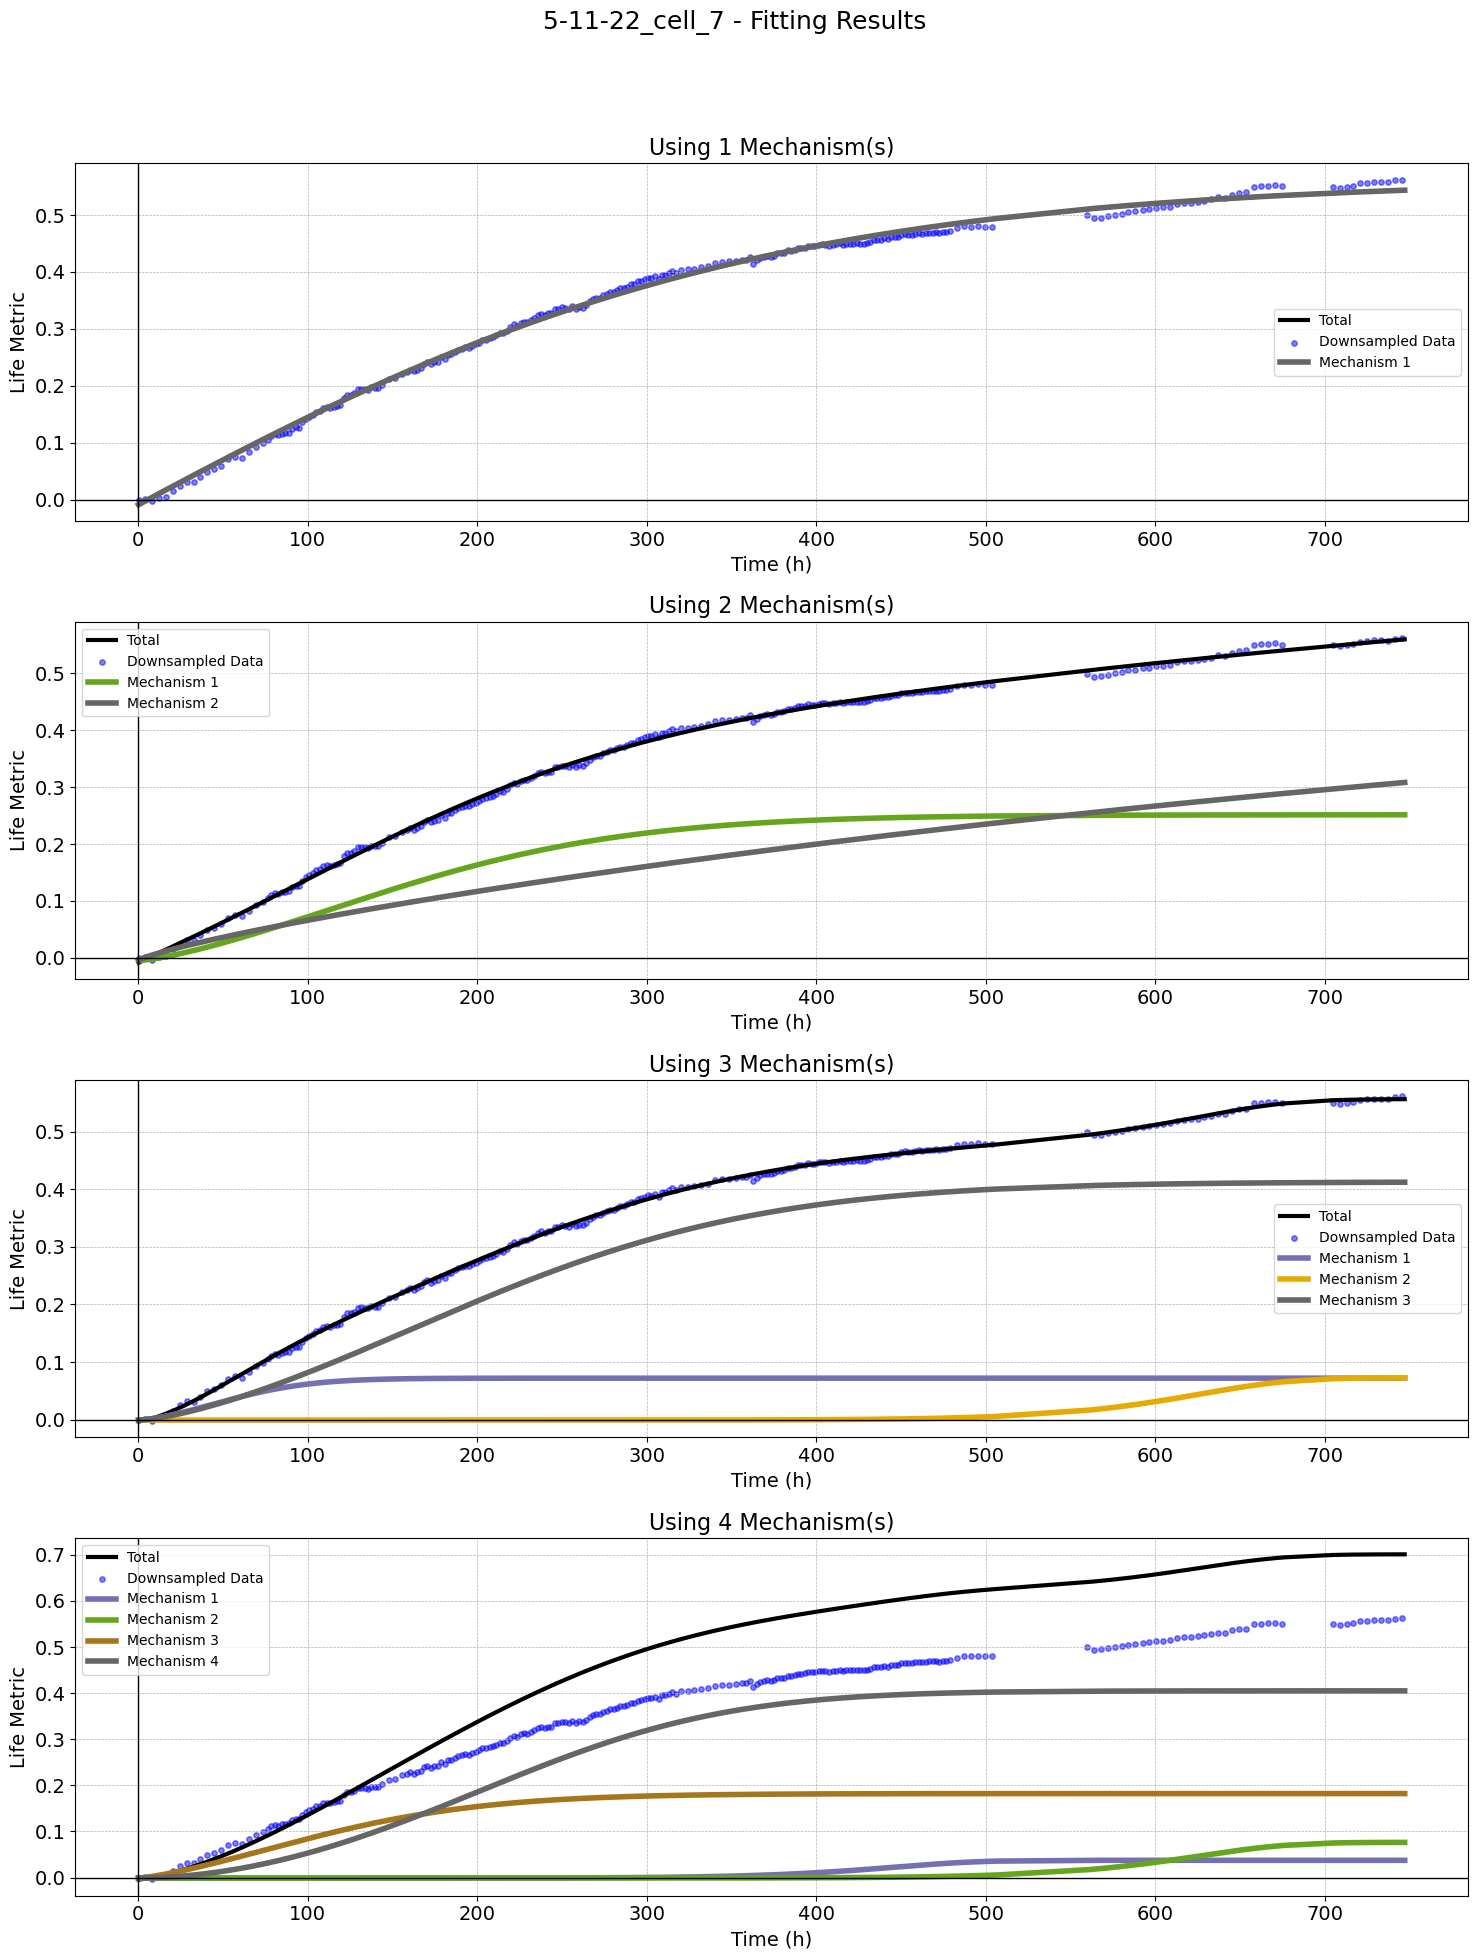

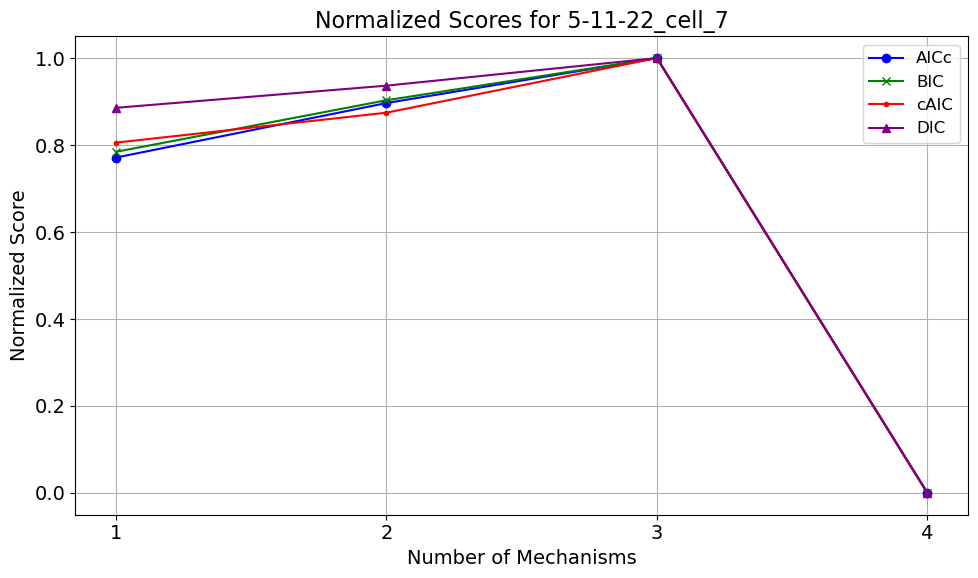

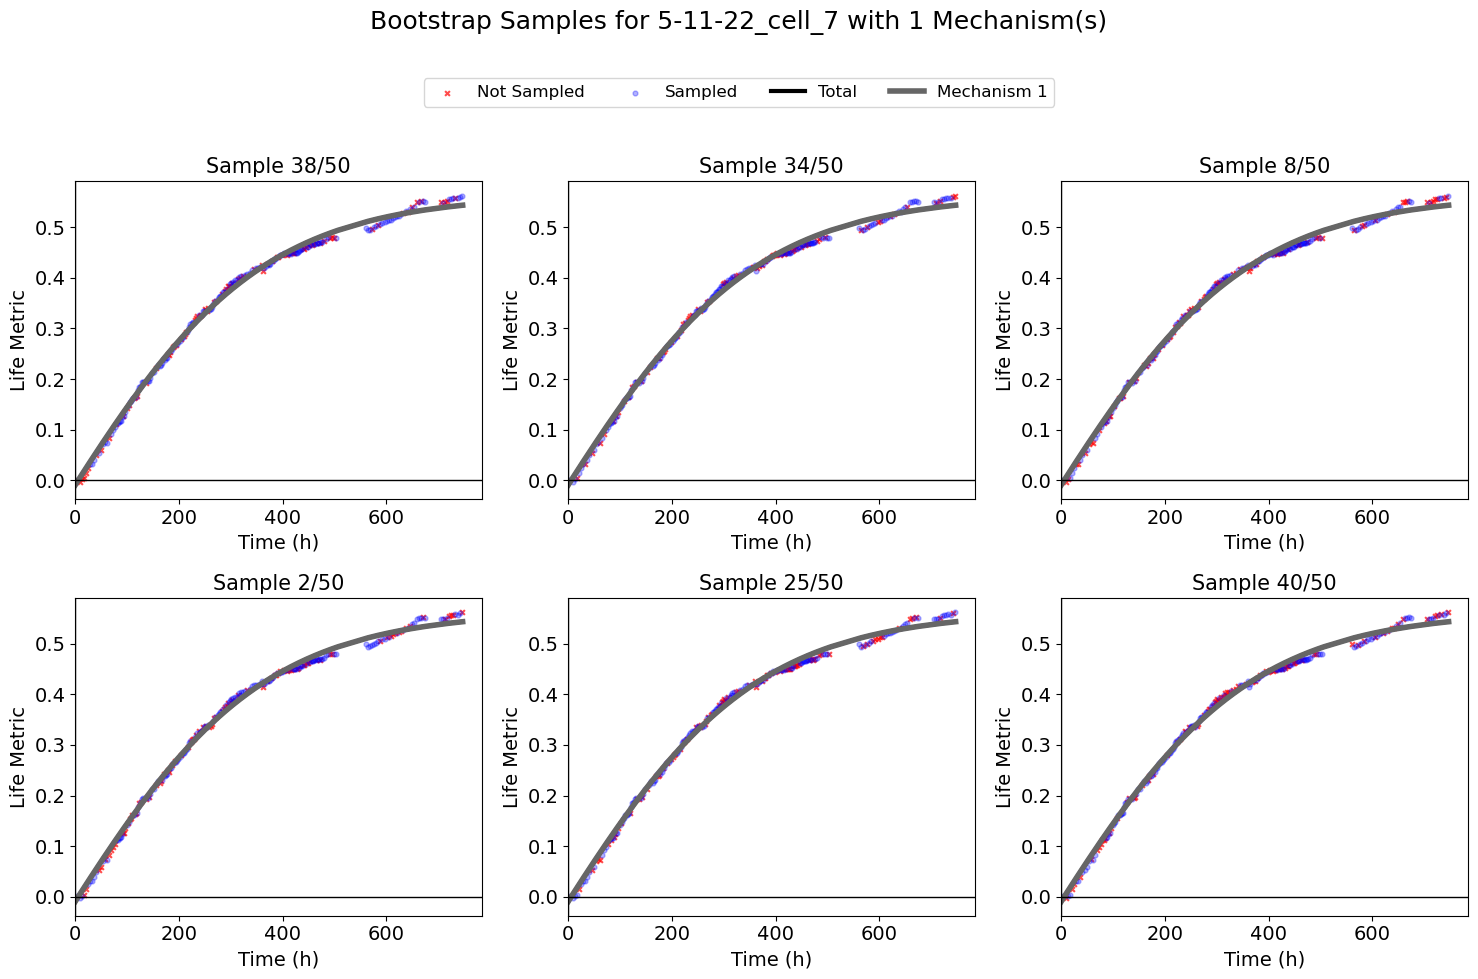

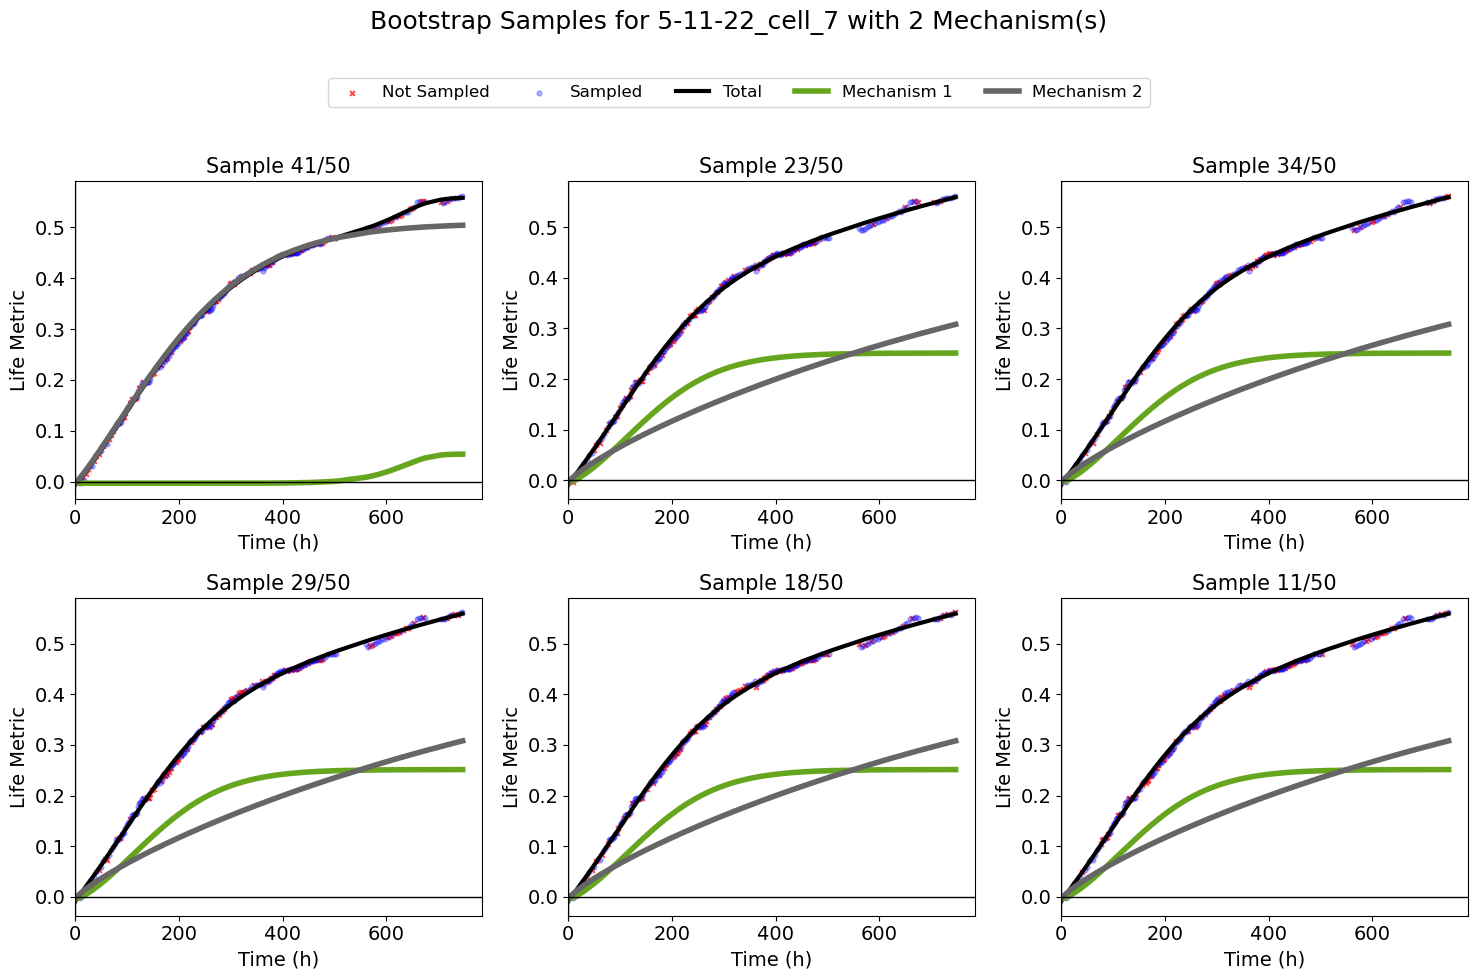

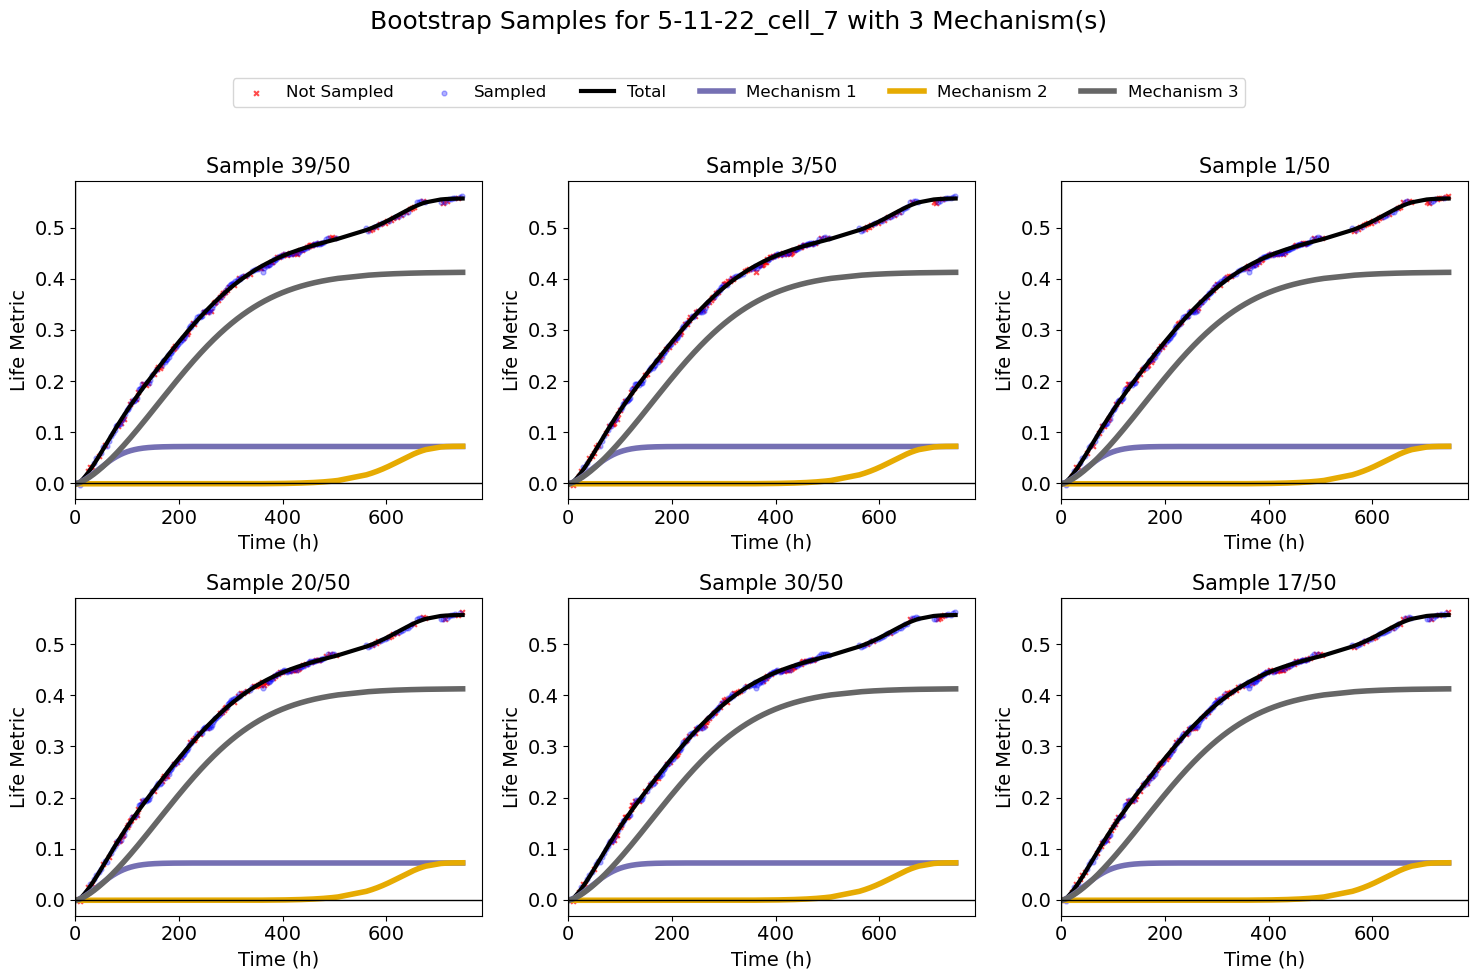

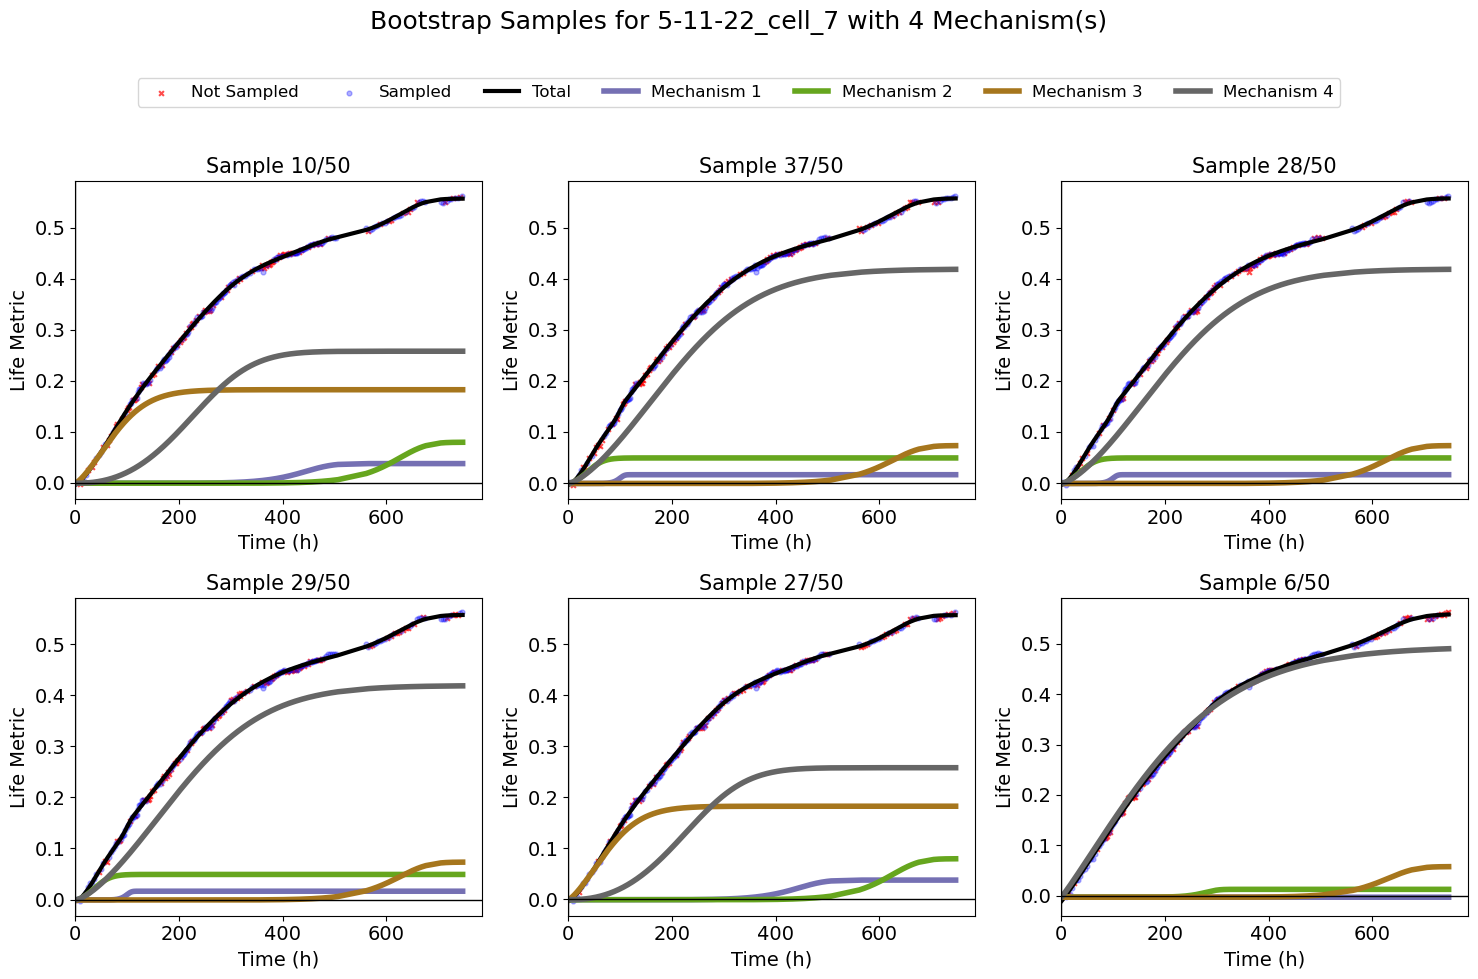

All cells complete...Results saved in 'results/fitSRE_20241209_173449'


In [25]:
#%% Loop through all cells

# Initialize list for storing results
all_results = []

for date_key in data_dict:
    for cell_number in data_dict[date_key]:
        
        t_data, life_metric_data = data_dict[date_key][cell_number]
        # life_metric_fit = life_metric_data[life_metric_data>=0]
        # t_data_fit = t_data[life_metric_data>=0]
        
        cell_name = f"{date_key}_cell_{cell_number}"

        process_cell(cell_name, t_data, life_metric_data)
        
print(f"All cells complete...Results saved in '{top_level_folder}'")